# CLO-SKET radial–angular representation — audited clean rewrite

This notebook rebuilds the radial–angular analysis from the original TIFF files and keeps one traceable computational lineage.

## What this rewrite changes

- Removes recovery, backup, result-lock, manuscript-claim, and duplicate-classifier cells.
- Treats **72 angular bins and 72 initial radial bins as analyst-chosen numerical discretizations**, not learned facts.
- Makes the retained 25-shell domain explicit: it is induced by the fixed physical interval `3.5 ≤ r ≤ 27.5` on the 72-bin grid.
- Removes the invalid Cell 22A BIC comparison. A probability vector over angular bins is not an independent sample of 72 observations, so the previous BIC penalty was not valid.
- Computes observed axial moments directly from the frozen conditional angular distributions.
- Describes the learned field accurately as **population-trained out-of-fold regression of the first axial moment**—not a von Mises fit and not a generated sketch.
- Rebuilds and verifies the exact canonical 28-D vector.
- Recomputes all reported results; no numerical result is hard-coded.

## Interpretation boundary

The category labels are excluded from feature construction. If category discrimination is run below, the frozen OOF learned coordinates were trained without labels but across the full sketch population. This is a **transductive representation evaluation**, not a strict inductive outer-fold evaluation. Use the optional nested evaluation section before making a strict out-of-sample category claim.


## 1. Runtime configuration

Set `DATA_ROOT` to the directory whose immediate subdirectories contain the source TIFF sketches. The default matches the original Colab layout. The output directory is local and may be changed safely.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path(os.environ.get(
    "CLO_SKET_DATA_ROOT",
    "/content/drive/MyDrive/FashionAI/datasets/Clo-Sket/Clo-Sket",
))
OUTPUT_ROOT = Path(os.environ.get(
    "CLO_SKET_OUTPUT_ROOT",
    "/content/CLO_SKET_Radial_Angular_Audited_Results",
))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root does not exist: {DATA_ROOT}\n"
        "Set the CLO_SKET_DATA_ROOT environment variable or edit DATA_ROOT."
    )

print("DATA_ROOT  :", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


DATA_ROOT  : /content/drive/MyDrive/FashionAI/datasets/Clo-Sket/Clo-Sket
OUTPUT_ROOT: /content/CLO_SKET_Radial_Angular_Audited_Results


## 2. Frozen radial × angular extraction

The code below is the verified source-TIFF extraction lineage. `N_ANGULAR=72` and `N_RADIAL=72` are declared design choices. They give 5° angular cells and the initial radial grid; they were not selected by PCA or category labels.



🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
CELL 11R — CONDITIONAL RADIAL × ANGULAR FOURIER

SOURCE
------------------------------------------------------------------------
Root: /content/drive/MyDrive/FashionAI/datasets/Clo-Sket/Clo-Sket
Images: 2300
Angular bins: 72
Radial bins: 72
🟢 2300 source sketches verified

RECOVERING RADIAL × ANGULAR MASS
------------------------------------------------------------------------
processed 250/2300
processed 500/2300
processed 750/2300
processed 1000/2300
processed 1250/2300
processed 1500/2300
processed 1750/2300
processed 2000/2300
processed 2250/2300
processed 2300/2300
🟢 Radial × angular mass recovered

MASS CONSERVATION
------------------------------------------------------------------------
Maximum absolute mass error: 0.0
Mean absolute mass error: 0.0
Maximum relative mass error: 0.0
🟢 RADIAL × ANGULAR MASS EXACTLY CONSERVED

RADIAL MASS PROFILE
------------------------------------------------------------------------
Maximum radial 

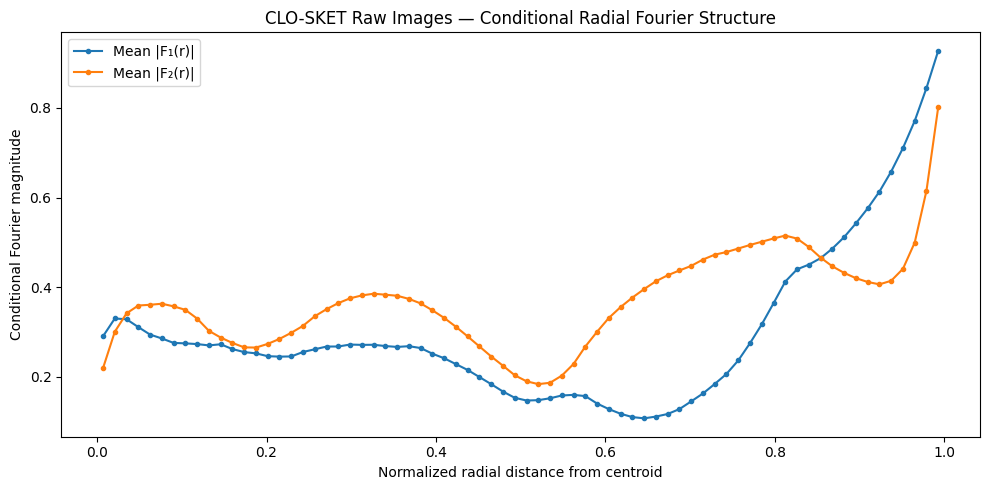

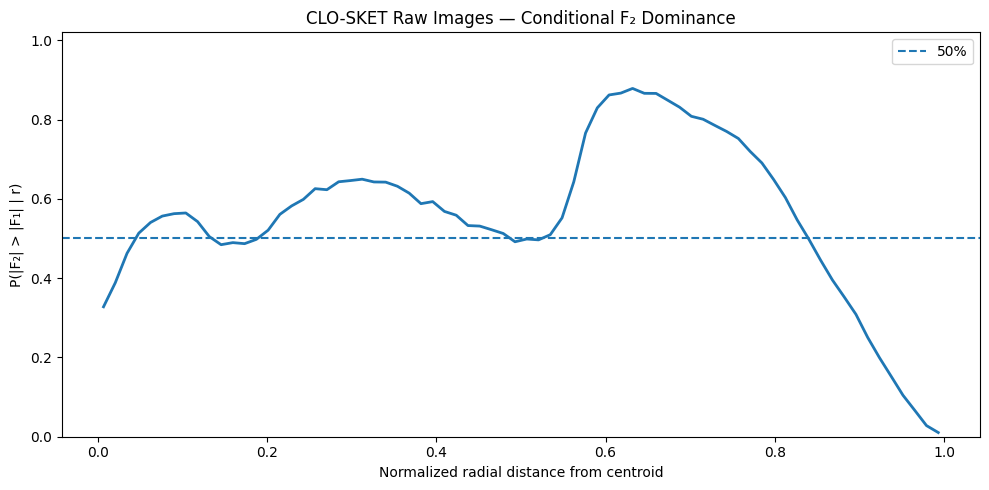

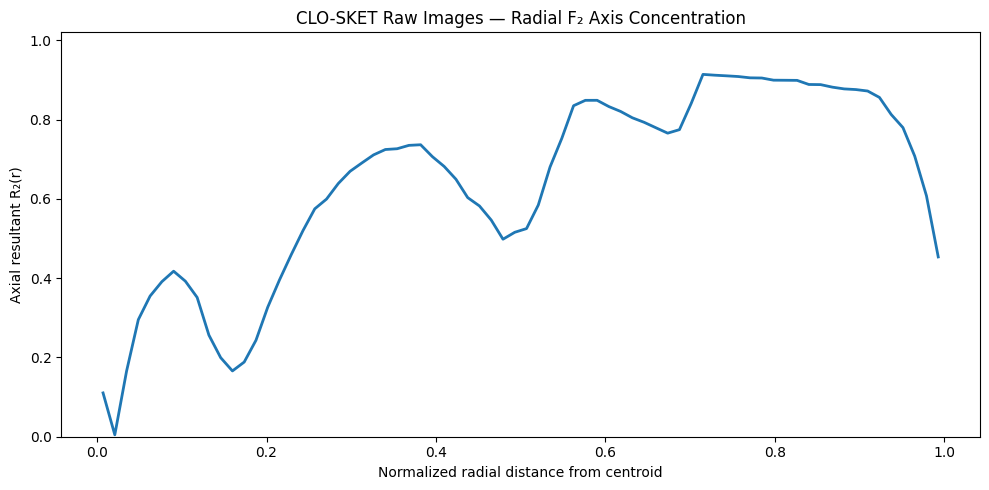

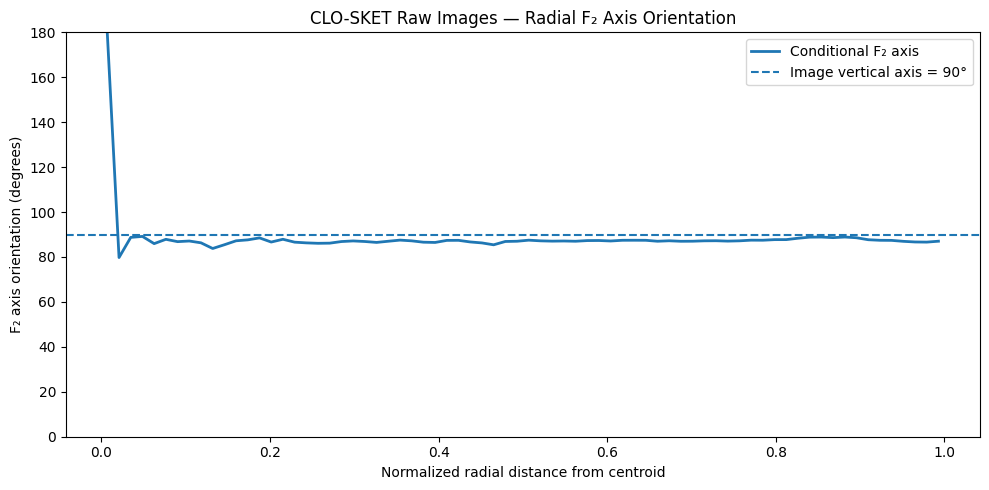


🟢 CELL 11R — CONDITIONAL RADIAL × ANGULAR FOURIER COMPLETE

REPRESENTATION

    Original grayscale TIFF
            ↓
    continuous darkness / ink weight
            ↓
    intensity-weighted centroid
            ↓
    isotropic coordinates
            ↓
    radial × angular mass W(r, θ)
            ↓
    conditional angular distribution P(θ | r)
            ↓
    circular Fourier transform
            ↓
    F₁(r), F₂(r), higher harmonics

PRIMARY QUESTION

    At what radial distances does the
    two-fold angular organization emerge?

MEASURED

    radial shell mass
    radial F₁ magnitude
    radial F₂ magnitude
    radial F₂ dominance
    radial F₂ axial concentration
    radial F₂ axis orientation

NUMERICAL VALIDATION

    radial × angular mass conservation
    radial mass normalization
    conditional angular normalization
    Fourier Parseval conservation

BOUNDARY CONDITION

    Rnorm = 1 is explicitly assigned to
    the final radial shell.

IMPORTANT

    No mean(F₂/F₁) is 

In [ ]:
# ============================================================================
# 🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# CELL 11R — CONDITIONAL RADIAL × ANGULAR FOURIER
# ============================================================================
#
# QUESTION
# --------
# Does the two-fold angular organization observed globally
# remain stable as a function of radial distance from the
# intensity-weighted centroid?
#
# PIPELINE
# --------
#
# Original grayscale TIFF
#        ↓
# continuous darkness / ink weight
#        ↓
# intensity-weighted centroid
#        ↓
# isotropic physical coordinates
#        ↓
# centroid-relative (r, θ)
#        ↓
# radial × angular mass W(r, θ)
#        ↓
# conditional angular distribution P(θ | r)
#        ↓
# circular Fourier transform
#        ↓
# F₁(r), F₂(r), F₃(r), ...
#
# IMPORTANT
# ---------
# Pillow is used for TIFF decoding.
#
# No image resizing, rotation, thresholding, binarization,
# PCA orientation, or semantic information is introduced.
#
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


print("\n" + "=" * 72)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("CELL 11R — CONDITIONAL RADIAL × ANGULAR FOURIER")
print("=" * 72)


# ============================================================================
# 1. SETTINGS
# ============================================================================

ROOT = str(DATA_ROOT)

N_ANGULAR = 72
N_RADIAL = 72

MASS_EPS = 1e-14

# Strict numerical tolerance.
# The binning itself should conserve mass to floating-point precision.
MASS_TOL = 1e-10


# ============================================================================
# 2. SOURCE INVENTORY
# ============================================================================

image_paths = []
image_categories = []

for category in sorted(os.listdir(ROOT)):

    category_path = os.path.join(
        ROOT,
        category
    )

    if not os.path.isdir(category_path):
        continue

    for filename in sorted(
        os.listdir(category_path)
    ):

        if filename.lower().endswith(
            (".tif", ".tiff")
        ):

            image_paths.append(
                os.path.join(
                    category_path,
                    filename
                )
            )

            image_categories.append(
                category
            )


image_paths = np.asarray(
    image_paths
)

image_categories = np.asarray(
    image_categories
)

N = len(image_paths)


print("\nSOURCE")
print("-" * 72)

print(f"Root: {ROOT}")
print(f"Images: {N}")
print(f"Angular bins: {N_ANGULAR}")
print(f"Radial bins: {N_RADIAL}")

if N != 2300:

    raise RuntimeError(
        f"Expected exactly 2300 sketches, "
        f"found {N}."
    )

print("🟢 2300 source sketches verified")


# ============================================================================
# 3. POLAR BIN GEOMETRY
# ============================================================================

theta_edges = np.linspace(
    -np.pi,
    np.pi,
    N_ANGULAR + 1
)

theta_centers = (
    theta_edges[:-1]
    +
    theta_edges[1:]
) / 2.0

theta_centers_deg = np.degrees(
    theta_centers
)


r_edges = np.linspace(
    0.0,
    1.0,
    N_RADIAL + 1
)

r_centers = (
    r_edges[:-1]
    +
    r_edges[1:]
) / 2.0


# ============================================================================
# 4. STORAGE
# ============================================================================

# Raw radial × angular ink mass:
#
#     W_i(r, θ)
#
# for sketch i.

joint_mass = np.zeros(
    (
        N,
        N_RADIAL,
        N_ANGULAR
    ),
    dtype=np.float64
)


# Intensity-weighted centroid.

centroids = np.zeros(
    (N, 2),
    dtype=np.float64
)


# Original total darkness / ink mass.

total_mass = np.zeros(
    N,
    dtype=np.float64
)


# ============================================================================
# 5. RECOVER RAW RADIAL × ANGULAR MASS
# ============================================================================

print("\nRECOVERING RADIAL × ANGULAR MASS")
print("-" * 72)


for i, path in enumerate(
    image_paths
):

    # ------------------------------------------------------------------------
    # TIFF DECODING
    # ------------------------------------------------------------------------

    with Image.open(path) as im:

        im.load()

        img = np.asarray(
            im.convert("L"),
            dtype=np.float64
        )


    # ------------------------------------------------------------------------
    # IMAGE VALIDATION
    # ------------------------------------------------------------------------

    if img.ndim != 2:

        raise RuntimeError(
            f"Expected 2-D grayscale image.\n"
            f"Path: {path}\n"
            f"Shape: {img.shape}"
        )


    if not np.all(
        np.isfinite(img)
    ):

        raise RuntimeError(
            f"Non-finite pixel values found:\n"
            f"{path}"
        )


    # ------------------------------------------------------------------------
    # CONTINUOUS DARKNESS / INK WEIGHT
    #
    # White = 255
    # Black = 0
    #
    # Therefore:
    #
    #     w = 255 - intensity
    #
    # No thresholding.
    # No binarization.
    # ------------------------------------------------------------------------

    w = (
        255.0
        -
        img
    )

    w = np.maximum(
        w,
        0.0
    )


    # ------------------------------------------------------------------------
    # TOTAL RAW INK MASS
    # ------------------------------------------------------------------------

    mass = np.sum(w)

    if (
        not np.isfinite(mass)
        or
        mass <= 0
    ):

        raise RuntimeError(
            f"Invalid total ink mass:\n"
            f"{path}"
        )

    total_mass[i] = mass


    # ------------------------------------------------------------------------
    # ISOTROPIC IMAGE COORDINATES
    #
    # S = max(width, height)
    #
    # x' = (x - cx_image) / S
    # y' = (y - cy_image) / S
    #
    # Thus x and y retain the same physical scale.
    # ------------------------------------------------------------------------

    height, width = w.shape

    S = float(
        max(
            width,
            height
        )
    )


    x = (
        np.arange(
            width,
            dtype=np.float64
        )
        -
        (width - 1) / 2.0
    ) / S


    y = (
        np.arange(
            height,
            dtype=np.float64
        )
        -
        (height - 1) / 2.0
    ) / S


    X, Y = np.meshgrid(
        x,
        y
    )


    # ------------------------------------------------------------------------
    # INTENSITY-WEIGHTED CENTROID
    #
    # Cx = Σ(wx) / Σw
    # Cy = Σ(wy) / Σw
    # ------------------------------------------------------------------------

    cx = (
        np.sum(
            w * X
        )
        /
        mass
    )

    cy = (
        np.sum(
            w * Y
        )
        /
        mass
    )


    centroids[i, 0] = cx
    centroids[i, 1] = cy


    # ------------------------------------------------------------------------
    # CENTROID-REFERENCED COORDINATES
    # ------------------------------------------------------------------------

    Xc = X - cx
    Yc = Y - cy


    # ------------------------------------------------------------------------
    # POLAR COORDINATES
    # ------------------------------------------------------------------------

    R = np.sqrt(
        Xc**2 +
        Yc**2
    )

    Theta = np.arctan2(
        Yc,
        Xc
    )


    # ------------------------------------------------------------------------
    # NORMALIZED RADIAL COORDINATE
    #
    # Each sketch gets:
    #
    #     Rnorm ∈ [0, 1]
    #
    # where 1 corresponds to the farthest image pixel
    # from that sketch's centroid.
    # ------------------------------------------------------------------------

    Rmax = np.max(R)

    if Rmax <= 0:

        raise RuntimeError(
            f"Invalid radial extent:\n"
            f"{path}"
        )


    Rnorm = (
        R / Rmax
    )


    # Numerical protection.

    Rnorm = np.clip(
        Rnorm,
        0.0,
        1.0
    )


    # ------------------------------------------------------------------------
    # RADIAL BIN
    #
    # CRITICAL BOUNDARY FIX:
    #
    # Rnorm == 1.0 must belong to the final shell,
    # not be discarded as bin index N_RADIAL.
    # ------------------------------------------------------------------------

    r_idx = (
        np.searchsorted(
            r_edges,
            Rnorm,
            side="right"
        )
        -
        1
    )


    r_idx = np.clip(
        r_idx,
        0,
        N_RADIAL - 1
    )


    # ------------------------------------------------------------------------
    # ANGULAR BIN
    # ------------------------------------------------------------------------

    theta_idx = (
        np.searchsorted(
            theta_edges,
            Theta,
            side="right"
        )
        -
        1
    )


    theta_idx = np.clip(
        theta_idx,
        0,
        N_ANGULAR - 1
    )


    # ------------------------------------------------------------------------
    # VALID PIXELS
    # ------------------------------------------------------------------------

    valid = (
        np.isfinite(w)
        &
        np.isfinite(Rnorm)
        &
        np.isfinite(Theta)
    )


    # ------------------------------------------------------------------------
    # ACCUMULATE RAW MASS
    # ------------------------------------------------------------------------

    np.add.at(
        joint_mass[i],
        (
            r_idx[valid],
            theta_idx[valid]
        ),
        w[valid]
    )


    if (
        (i + 1) % 250 == 0
        or
        i == N - 1
    ):

        print(
            f"processed {i + 1}/{N}"
        )


print(
    "🟢 Radial × angular mass recovered"
)


# ============================================================================
# 6. MASS CONSERVATION
# ============================================================================

print("\nMASS CONSERVATION")
print("-" * 72)


recovered_mass = (
    joint_mass.sum(
        axis=(1, 2)
    )
)


mass_error = (
    recovered_mass
    -
    total_mass
)


absolute_mass_error = np.abs(
    mass_error
)


relative_mass_error = (
    absolute_mass_error
    /
    total_mass
)


print(
    "Maximum absolute mass error:",
    np.max(
        absolute_mass_error
    )
)

print(
    "Mean absolute mass error:",
    np.mean(
        absolute_mass_error
    )
)

print(
    "Maximum relative mass error:",
    np.max(
        relative_mass_error
    )
)


if np.max(
    relative_mass_error
) > MASS_TOL:

    raise RuntimeError(
        "Radial-angular mass conservation failed."
    )


print(
    "🟢 RADIAL × ANGULAR MASS EXACTLY CONSERVED"
)


# ============================================================================
# 7. RADIAL MASS PROFILE
#
#     M(r) = fraction of total ink in radial shell r
# ============================================================================

radial_mass = (
    joint_mass.sum(
        axis=2
    )
    /
    total_mass[:, None]
)


radial_normalization_error = np.abs(
    radial_mass.sum(
        axis=1
    )
    -
    1.0
)


print("\nRADIAL MASS PROFILE")
print("-" * 72)

print(
    "Maximum radial normalization error:",
    np.max(
        radial_normalization_error
    )
)


if np.max(
    radial_normalization_error
) > MASS_TOL:

    raise RuntimeError(
        "Radial mass normalization failed."
    )


print(
    "🟢 Radial mass profiles verified"
)


# ============================================================================
# 8. CONDITIONAL ANGULAR DISTRIBUTION
#
# For each radial shell:
#
#     P(θ | r)
#
# = W(r,θ) / Σθ W(r,θ)
#
# This asks:
#
#     "Given that ink occurs at this radius,
#      how is it distributed angularly?"
# ============================================================================

shell_mass = (
    joint_mass.sum(
        axis=2
    )
)


nonempty = (
    shell_mass
    >
    MASS_EPS
)


conditional_angular = np.zeros_like(
    joint_mass
)


for i in range(N):

    valid_shells = nonempty[i]

    if np.any(
        valid_shells
    ):

        conditional_angular[
            i,
            valid_shells,
            :
        ] = (
            joint_mass[
                i,
                valid_shells,
                :
            ]
            /
            shell_mass[
                i,
                valid_shells,
                None
            ]
        )


# ============================================================================
# 9. CONDITIONAL NORMALIZATION
# ============================================================================

print("\nCONDITIONAL ANGULAR PROFILES")
print("-" * 72)


conditional_sums = (
    conditional_angular.sum(
        axis=2
    )
)


valid_conditional_sums = (
    conditional_sums[
        nonempty
    ]
)


print(
    "Non-empty radial shells:",
    len(
        valid_conditional_sums
    ),
    "/",
    N * N_RADIAL
)


print(
    "Minimum conditional sum:",
    np.min(
        valid_conditional_sums
    )
)

print(
    "Maximum conditional sum:",
    np.max(
        valid_conditional_sums
    )
)


conditional_error = np.max(
    np.abs(
        valid_conditional_sums
        -
        1.0
    )
)


print(
    "Maximum normalization error:",
    conditional_error
)


if conditional_error > MASS_TOL:

    raise RuntimeError(
        "Conditional angular normalization failed."
    )


print(
    "🟢 CONDITIONAL ANGULAR MASS NORMALIZED"
)


# ============================================================================
# 10. CONDITIONAL CIRCULAR FOURIER TRANSFORM
#
#     F_k(r)
#
# = Σθ P(θ|r) exp(-ikθ)
#
# ============================================================================

conditional_fft = np.zeros(
    (
        N,
        N_RADIAL,
        N_ANGULAR // 2 + 1
    ),
    dtype=np.complex128
)


for i in range(N):

    for j in range(N_RADIAL):

        if not nonempty[i, j]:

            continue


        conditional_fft[
            i,
            j,
            :
        ] = np.fft.rfft(
            conditional_angular[
                i,
                j,
                :
            ]
        )


print("\nCONDITIONAL FOURIER TRANSFORM")
print("-" * 72)

print(
    "Input:",
    conditional_angular.shape
)

print(
    "rFFT:",
    conditional_fft.shape
)

print(
    "Available harmonics:",
    conditional_fft.shape[-1]
)

print(
    "🟢 Conditional Fourier transform complete"
)


# ============================================================================
# 11. PARSEVAL CHECK
# ============================================================================

parseval_errors = []


for i in range(N):

    for j in range(N_RADIAL):

        if not nonempty[i, j]:

            continue


        a = conditional_angular[
            i,
            j,
            :
        ]

        F = conditional_fft[
            i,
            j,
            :
        ]


        spatial_energy = np.sum(
            np.abs(a) ** 2
        )


        corrected_power = (
            np.abs(F) ** 2
        )


        # rFFT stores only non-negative frequencies.
        #
        # Interior frequencies correspond to
        # both +k and -k.
        #
        # Therefore their power is doubled.
        #
        # k = 0 and Nyquist are NOT doubled.

        if N_ANGULAR % 2 == 0:

            corrected_power[
                1:-1
            ] *= 2.0

        else:

            corrected_power[
                1:
            ] *= 2.0


        fourier_energy = (
            np.sum(
                corrected_power
            )
            /
            N_ANGULAR
        )


        parseval_errors.append(
            abs(
                spatial_energy
                -
                fourier_energy
            )
        )


parseval_errors = np.asarray(
    parseval_errors
)


print("\nPARSEVAL INTEGRITY")
print("-" * 72)

print(
    "Maximum absolute energy error:",
    np.max(
        parseval_errors
    )
)

print(
    "Mean absolute energy error:",
    np.mean(
        parseval_errors
    )
)


if np.max(
    parseval_errors
) > 1e-10:

    raise RuntimeError(
        "Conditional Fourier Parseval check failed."
    )


print(
    "🟢 CONDITIONAL PARSEVAL VERIFIED"
)


# ============================================================================
# 12. HARMONIC MAGNITUDES
# ============================================================================

F1 = np.abs(
    conditional_fft[:, :, 1]
)

F2 = np.abs(
    conditional_fft[:, :, 2]
)

F3 = np.abs(
    conditional_fft[:, :, 3]
)

F4 = np.abs(
    conditional_fft[:, :, 4]
)


# ============================================================================
# 13. F₂ AXIS ORIENTATION
#
#     α₂(r) = -arg(F₂(r)) / 2
#
# modulo 180° because this is an axial orientation.
# ============================================================================

F2_complex = (
    conditional_fft[:, :, 2]
)


axis_deg = (
    -0.5
    *
    np.angle(
        F2_complex
    )
)


axis_deg = np.degrees(
    axis_deg
)


axis_deg = (
    axis_deg
    %
    180.0
)


# ============================================================================
# 14. RADIAL AXIAL CONCENTRATION
#
#     R₂(r)
#
# = | mean exp(i 2α₂(r)) |
#
# ============================================================================

R2 = np.full(
    N_RADIAL,
    np.nan
)

mean_axis_deg = np.full(
    N_RADIAL,
    np.nan
)


for j in range(
    N_RADIAL
):

    valid = (
        nonempty[:, j]
        &
        (
            F2[:, j]
            >
            MASS_EPS
        )
    )


    if not np.any(
        valid
    ):

        continue


    alpha = np.radians(
        axis_deg[
            valid,
            j
        ]
    )


    z = np.mean(
        np.exp(
            2j * alpha
        )
    )


    R2[j] = np.abs(z)


    mean_axis_deg[j] = (
        np.degrees(
            0.5
            *
            np.angle(z)
        )
        %
        180.0
    )


# ============================================================================
# 15. F₂ DOMINANCE
#
# Do NOT calculate mean(F₂/F₁).
#
# F₁ can approach zero and produce unstable ratios.
#
# Instead:
#
#     P(|F₂| > |F₁| | r)
# ============================================================================

f2_dominance = np.full(
    N_RADIAL,
    np.nan
)


for j in range(
    N_RADIAL
):

    valid = nonempty[:, j]


    if not np.any(
        valid
    ):

        continue


    f2_dominance[j] = np.mean(
        F2[
            valid,
            j
        ]
        >
        F1[
            valid,
            j
        ]
    )


# ============================================================================
# 16. RADIAL SUMMARY TABLE
# ============================================================================

summary_rows = []


for j in range(
    N_RADIAL
):

    valid = nonempty[:, j]


    if not np.any(
        valid
    ):

        continue


    summary_rows.append({

        "radial_position":
            r_centers[j],

        "mean_shell_mass":
            np.mean(
                radial_mass[
                    valid,
                    j
                ]
            ),

        "mean_F1":
            np.mean(
                F1[
                    valid,
                    j
                ]
            ),

        "median_F1":
            np.median(
                F1[
                    valid,
                    j
                ]
            ),

        "mean_F2":
            np.mean(
                F2[
                    valid,
                    j
                ]
            ),

        "median_F2":
            np.median(
                F2[
                    valid,
                    j
                ]
            ),

        "mean_F3":
            np.mean(
                F3[
                    valid,
                    j
                ]
            ),

        "mean_F4":
            np.mean(
                F4[
                    valid,
                    j
                ]
            ),

        "F2_dominance_fraction":
            f2_dominance[j],

        "axial_resultant_R2":
            R2[j],

        "mean_axis_deg":
            mean_axis_deg[j],

        "n_valid":
            np.sum(valid)
    })


conditional_radial_summary = pd.DataFrame(
    summary_rows
)


# ============================================================================
# 17. DISPLAY SUMMARY
# ============================================================================

print("\nCONDITIONAL RADIAL FOURIER SUMMARY")
print("-" * 72)

print(
    conditional_radial_summary[
        [
            "radial_position",
            "mean_shell_mass",
            "mean_F1",
            "mean_F2",
            "F2_dominance_fraction",
            "axial_resultant_R2",
            "mean_axis_deg"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ============================================================================
# 18. PLOT — F₁ AND F₂ BY RADIUS
# ============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    conditional_radial_summary[
        "radial_position"
    ],
    conditional_radial_summary[
        "mean_F1"
    ],
    marker="o",
    markersize=3,
    label="Mean |F₁(r)|"
)

plt.plot(
    conditional_radial_summary[
        "radial_position"
    ],
    conditional_radial_summary[
        "mean_F2"
    ],
    marker="o",
    markersize=3,
    label="Mean |F₂(r)|"
)

plt.xlabel(
    "Normalized radial distance from centroid"
)

plt.ylabel(
    "Conditional Fourier magnitude"
)

plt.title(
    "CLO-SKET Raw Images — Conditional Radial Fourier Structure"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================================
# 19. PLOT — F₂ DOMINANCE
# ============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    conditional_radial_summary[
        "radial_position"
    ],
    conditional_radial_summary[
        "F2_dominance_fraction"
    ],
    linewidth=2
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50%"
)

plt.xlabel(
    "Normalized radial distance from centroid"
)

plt.ylabel(
    "P(|F₂| > |F₁| | r)"
)

plt.title(
    "CLO-SKET Raw Images — Conditional F₂ Dominance"
)

plt.ylim(
    0,
    1.02
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================================
# 20. PLOT — AXIAL RESULTANT
# ============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    conditional_radial_summary[
        "radial_position"
    ],
    conditional_radial_summary[
        "axial_resultant_R2"
    ],
    linewidth=2
)

plt.xlabel(
    "Normalized radial distance from centroid"
)

plt.ylabel(
    "Axial resultant R₂(r)"
)

plt.ylim(
    0,
    1.02
)

plt.title(
    "CLO-SKET Raw Images — Radial F₂ Axis Concentration"
)

plt.tight_layout()

plt.show()


# ============================================================================
# 21. PLOT — F₂ AXIS ORIENTATION
# ============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    conditional_radial_summary[
        "radial_position"
    ],
    conditional_radial_summary[
        "mean_axis_deg"
    ],
    linewidth=2,
    label="Conditional F₂ axis"
)

plt.axhline(
    90,
    linestyle="--",
    label="Image vertical axis = 90°"
)

plt.xlabel(
    "Normalized radial distance from centroid"
)

plt.ylabel(
    "F₂ axis orientation (degrees)"
)

plt.ylim(
    0,
    180
)

plt.title(
    "CLO-SKET Raw Images — Radial F₂ Axis Orientation"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================================
# 22. FINAL AUDIT
# ============================================================================

print("\n" + "=" * 72)
print("🟢 CELL 11R — CONDITIONAL RADIAL × ANGULAR FOURIER COMPLETE")
print("=" * 72)

print("""
REPRESENTATION

    Original grayscale TIFF
            ↓
    continuous darkness / ink weight
            ↓
    intensity-weighted centroid
            ↓
    isotropic coordinates
            ↓
    radial × angular mass W(r, θ)
            ↓
    conditional angular distribution P(θ | r)
            ↓
    circular Fourier transform
            ↓
    F₁(r), F₂(r), higher harmonics

PRIMARY QUESTION

    At what radial distances does the
    two-fold angular organization emerge?

MEASURED

    radial shell mass
    radial F₁ magnitude
    radial F₂ magnitude
    radial F₂ dominance
    radial F₂ axial concentration
    radial F₂ axis orientation

NUMERICAL VALIDATION

    radial × angular mass conservation
    radial mass normalization
    conditional angular normalization
    Fourier Parseval conservation

BOUNDARY CONDITION

    Rnorm = 1 is explicitly assigned to
    the final radial shell.

IMPORTANT

    No mean(F₂/F₁) is used because F₁ can
    approach zero.

    F₂ dominance is therefore evaluated as:

        P(|F₂| > |F₁| | r)

NO

    thresholding
    binarization
    morphology resizing
    rotation
    PCA
    clustering
    semantic labels
""")

print("=" * 72)


## 3. Discretization and mass-conservation audit

This cell records what was chosen, what was data-derived, and whether every conditional distribution is normalized. It does not pretend that 72/72 is uniquely optimal.


## 4. Parseval-correct Fourier field and radial/axial stability

These cells derive the validated complex Fourier field and the corrected F₂ quantities used by the descriptor builders.


In [ ]:
# ============================================================================
# DISCRETIZATION AND CONDITIONAL-MASS AUDIT — CORRECTED LINEAGE
# ============================================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# 1. Canonical arrays
# ---------------------------------------------------------------------------

conditional_angular = np.asarray(
    conditional_angular,
    dtype=np.float64,
)

radial_mass = np.asarray(
    radial_mass,
    dtype=np.float64,
)

# Cell 11R normalized radial positions:
# approximately 0.0069, ..., 0.9931.
normalized_radial_centers = np.asarray(
    r_centers,
    dtype=np.float64,
).copy()

# Downstream descriptor cells use radial-bin-centre coordinates:
# 0.5, 1.5, ..., 71.5.
radial_centers = (
    np.arange(
        N_RADIAL,
        dtype=np.float64,
    )
    + 0.5
)

# ---------------------------------------------------------------------------
# 2. Shape and finiteness validation
# ---------------------------------------------------------------------------

population_size = conditional_angular.shape[0]

expected_conditional_shape = (
    population_size,
    N_RADIAL,
    N_ANGULAR,
)

assert conditional_angular.shape == expected_conditional_shape, (
    "Unexpected conditional_angular shape: "
    f"expected {expected_conditional_shape}, "
    f"received {conditional_angular.shape}."
)

assert radial_mass.shape == (
    population_size,
    N_RADIAL,
), (
    "Unexpected radial_mass shape: "
    f"{radial_mass.shape}."
)

assert normalized_radial_centers.shape == (
    N_RADIAL,
)

assert radial_centers.shape == (
    N_RADIAL,
)

assert np.isfinite(
    conditional_angular
).all()

assert np.isfinite(
    radial_mass
).all()

assert np.isfinite(
    normalized_radial_centers
).all()

assert np.isfinite(
    radial_centers
).all()

# ---------------------------------------------------------------------------
# 3. Verify both radial coordinate systems
# ---------------------------------------------------------------------------

expected_normalized_radial_centers = (
    np.arange(
        N_RADIAL,
        dtype=np.float64,
    )
    + 0.5
) / N_RADIAL

assert np.allclose(
    normalized_radial_centers,
    expected_normalized_radial_centers,
    rtol=0.0,
    atol=1e-12,
), (
    "Cell 11R r_centers does not match the expected "
    "normalized radial-bin centres."
)

assert np.allclose(
    radial_centers,
    normalized_radial_centers * N_RADIAL,
    rtol=0.0,
    atol=1e-12,
), (
    "The normalized and bin-index radial coordinates "
    "are not equivalent."
)

# ---------------------------------------------------------------------------
# 4. Conditional angular normalization
# ---------------------------------------------------------------------------

positive_shell = (
    radial_mass > MASS_EPS
)

conditional_sum = (
    conditional_angular.sum(axis=2)
)

normalization_error = np.abs(
    conditional_sum[positive_shell] - 1.0
)

empty_shell_mass = np.abs(
    conditional_sum[~positive_shell]
)


def shield_safe_max(values):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    if values.size == 0:
        return 0.0

    return float(
        np.max(values)
    )


max_normalization_error = shield_safe_max(
    normalization_error
)

max_empty_shell_mass = shield_safe_max(
    empty_shell_mass
)

# ---------------------------------------------------------------------------
# 5. Frozen primary radial-bin domain
# ---------------------------------------------------------------------------

PRIMARY_RADIUS_MIN = 3.5
PRIMARY_RADIUS_MAX = 27.5

primary_shell_mask = (
    (radial_centers >= PRIMARY_RADIUS_MIN)
    & (radial_centers <= PRIMARY_RADIUS_MAX)
)

primary_shell_indices = np.flatnonzero(
    primary_shell_mask
)

retained_shell_count = int(
    primary_shell_indices.size
)

assert retained_shell_count > 0, (
    "The frozen radial-bin interval retained no shells."
)

first_retained_center = float(
    radial_centers[
        primary_shell_indices[0]
    ]
)

last_retained_center = float(
    radial_centers[
        primary_shell_indices[-1]
    ]
)

normalized_primary_centers = (
    normalized_radial_centers[
        primary_shell_indices
    ]
)

# ---------------------------------------------------------------------------
# 6. Audit table
# ---------------------------------------------------------------------------

discretization_audit = pd.Series({
    "population":
        int(population_size),

    "angular_bins_chosen":
        int(N_ANGULAR),

    "angular_degrees_per_bin":
        float(360.0 / N_ANGULAR),

    "initial_radial_bins_chosen":
        int(N_RADIAL),

    "full_normalized_radius_min":
        float(normalized_radial_centers[0]),

    "full_normalized_radius_max":
        float(normalized_radial_centers[-1]),

    "primary_bin_center_min_fixed":
        float(PRIMARY_RADIUS_MIN),

    "primary_bin_center_max_fixed":
        float(PRIMARY_RADIUS_MAX),

    "primary_normalized_radius_min":
        float(normalized_primary_centers[0]),

    "primary_normalized_radius_max":
        float(normalized_primary_centers[-1]),

    "retained_shell_count_induced":
        retained_shell_count,

    "max_positive_shell_normalization_error":
        max_normalization_error,

    "max_empty_shell_mass":
        max_empty_shell_mass,
})

display(
    discretization_audit.to_frame(
        "value"
    )
)

# ---------------------------------------------------------------------------
# 7. Hard validation
# ---------------------------------------------------------------------------

assert retained_shell_count == 25, (
    "Expected 25 retained shells for bin centres "
    "3.5–27.5; received "
    f"{retained_shell_count}."
)

assert np.isclose(
    first_retained_center,
    PRIMARY_RADIUS_MIN,
)

assert np.isclose(
    last_retained_center,
    PRIMARY_RADIUS_MAX,
)

assert max_normalization_error < 1e-10, (
    "Positive-shell conditional distributions "
    "do not sum to one within tolerance."
)

assert max_empty_shell_mass < 1e-10, (
    "Empty shells contain nonzero conditional mass."
)

# ---------------------------------------------------------------------------
# 8. Final status
# ---------------------------------------------------------------------------

print("\n" + "=" * 76)
print("🟢 DISCRETIZATION AND MASS AUDIT PASSED")
print("=" * 76)

print(
    "Conditional field       : "
    f"{conditional_angular.shape}"
)

print(
    "Initial grid            : "
    f"{N_RADIAL} radial × "
    f"{N_ANGULAR} angular"
)

print(
    "Angular resolution      : "
    f"{360.0 / N_ANGULAR:.1f}°"
)

print(
    "Full normalized centres : "
    f"{normalized_radial_centers[0]:.6f} "
    f"to "
    f"{normalized_radial_centers[-1]:.6f}"
)

print(
    "Primary bin centres     : "
    f"{first_retained_center:.1f} "
    f"to "
    f"{last_retained_center:.1f}"
)

print(
    "Primary normalized range: "
    f"{normalized_primary_centers[0]:.6f} "
    f"to "
    f"{normalized_primary_centers[-1]:.6f}"
)

print(
    "Retained shells         : "
    f"{retained_shell_count}"
)

print(
    "Normalization error     : "
    f"{max_normalization_error:.3e}"
)

print(
    "Empty-shell mass        : "
    f"{max_empty_shell_mass:.3e}"
)

,value
population,2.300000e+03
angular_bins_chosen,7.200000e+01
angular_degrees_per_bin,5.000000e+00
initial_radial_bins_chosen,7.200000e+01
full_normalized_radius_min,6.944444e-03
full_normalized_radius_max,9.930556e-01
primary_bin_center_min_fixed,3.500000e+00
primary_bin_center_max_fixed,2.750000e+01
primary_normalized_radius_min,4.861111e-02
primary_normalized_radius_max,3.819444e-01



🟢 DISCRETIZATION AND MASS AUDIT PASSED
Conditional field       : (2300, 72, 72)
Initial grid            : 72 radial × 72 angular
Angular resolution      : 5.0°
Full normalized centres : 0.006944 to 0.993056
Primary bin centres     : 3.5 to 27.5
Primary normalized range: 0.048611 to 0.381944
Retained shells         : 25
Normalization error     : 4.441e-16
Empty-shell mass        : 0.000e+00



🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
CELL 15R — PARSEVAL-CORRECTED FOURIER ENERGY + CONTROLLED RECONSTRUCTION

INPUT VERIFICATION
------------------------------------------------------------------------
Conditional angular : (2300, 72, 72)
Conditional Fourier : (2300, 72, 37)
Radial centers      : (72,)
Angular bins        : 72
Fourier bins        : 37
🟢 INPUTS VERIFIED

FOURIER CONVENTION
------------------------------------------------------------------------

For each sketch and radial shell:

    A(r, θ)

is decomposed using the discrete angular Fourier transform:

    F_k(r) = Σθ A(r,θ) exp(-i 2πkθ/Nθ)

conditional_fft contains the one-sided rFFT coefficients.

For even Nθ:

    E_total =
        |F0|²
        + 2 Σ(k=1...Nθ/2-1) |Fk|²
        + |F_Nθ/2|²

The factor of 2 is required because
the positive-frequency rFFT stores only one member
of each ±k Fourier pair.


PARSEVAL-CORRECTED FOURIER ENERGY
-------------------------------------------------------------------

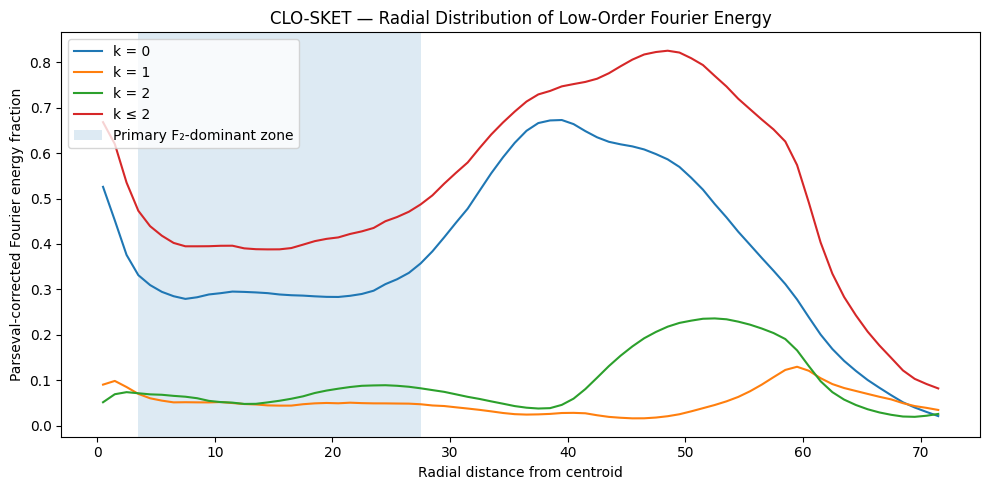

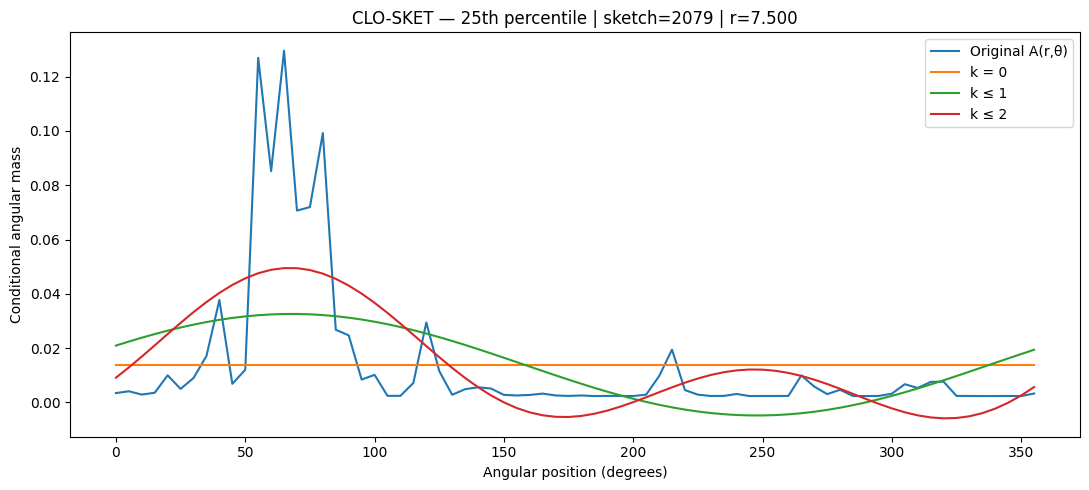

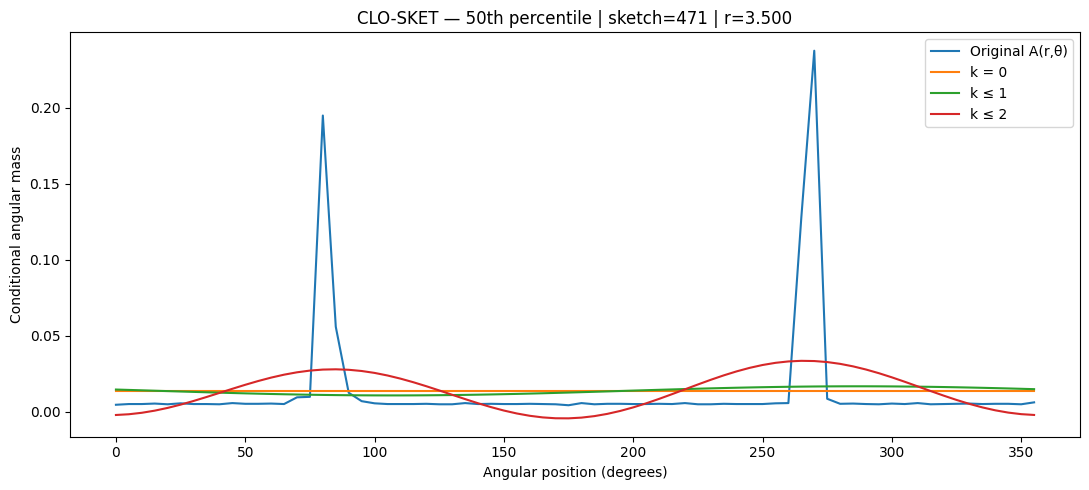

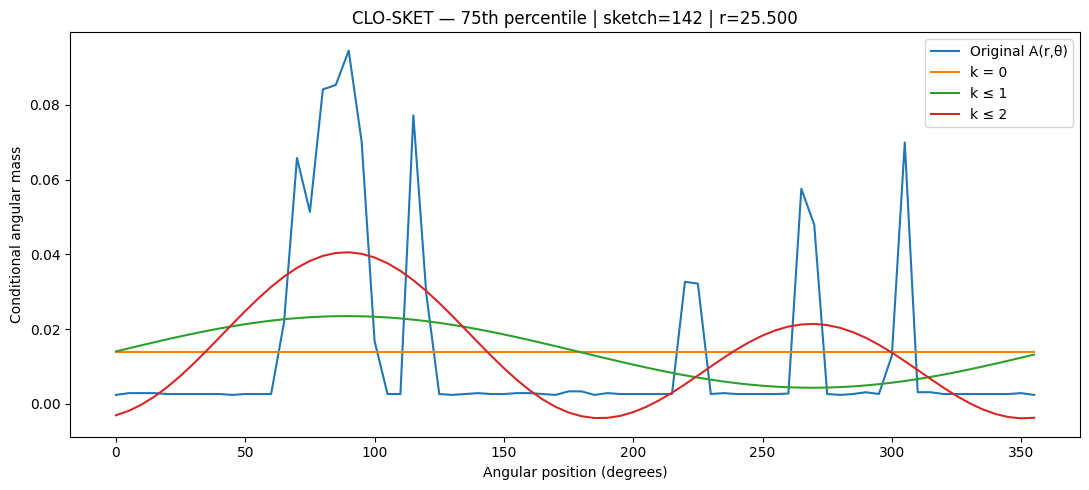


🟢 CELL 15R — PARSEVAL-CORRECTED FOURIER AUDIT COMPLETE

ESTABLISHED:

    1. A(r,θ) is represented by its angular
       Fourier coefficients.

    2. Fourier energy fractions use the correct
       one-sided rFFT Parseval weighting.

    3. k=0, k=1 and k=2 contributions are
       separately quantified.

    4. The combined k≤2 contribution is quantified.

    5. Low-order energy is localized radially.

    6. Representative sketches are selected from
       the Cell 13 primary F₂-dominant radial zone.

    7. Each representative sketch is reconstructed
       at its OWN F₂ peak shell within that zone.

    8. k=0, k≤1 and k≤2 reconstructions are compared
       directly against the measured angular profile.

    9. Full Fourier reconstruction provides a numerical
       reconstruction check.

IMPORTANT:

    |F₂|
        measures the strength of the second angular harmonic.

    F₂ energy fraction
        measures its contribution to total angular
        signal energy.

    k≤2 re

In [ ]:
# ========================================================================
# 🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# CELL 15R — PARSEVAL-CORRECTED FOURIER ENERGY + CONTROLLED RECONSTRUCTION
# ========================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n" + "=" * 72)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("CELL 15R — PARSEVAL-CORRECTED FOURIER ENERGY + CONTROLLED RECONSTRUCTION")
print("=" * 72)


# ========================================================================
# 1. INPUT VERIFICATION
# ========================================================================

print("\nINPUT VERIFICATION")
print("-" * 72)

required = [
    "conditional_angular",
    "conditional_fft",
    "radial_centers",
]

missing = [v for v in required if v not in globals()]

if missing:
    raise RuntimeError(
        "Required Cell 11R variables are missing:\n"
        + "\n".join(f"    - {v}" for v in missing)
    )

A = np.asarray(conditional_angular, dtype=np.float64)
F = np.asarray(conditional_fft, dtype=np.complex128)
r = np.asarray(radial_centers, dtype=np.float64)

N_SKETCH, N_RADIAL, N_ANGLE = A.shape
N_FREQ = F.shape[-1]

print(f"Conditional angular : {A.shape}")
print(f"Conditional Fourier : {F.shape}")
print(f"Radial centers      : {r.shape}")
print(f"Angular bins        : {N_ANGLE}")
print(f"Fourier bins        : {N_FREQ}")

if F.shape[:2] != (N_SKETCH, N_RADIAL):
    raise RuntimeError(
        "conditional_fft and conditional_angular dimensions do not agree."
    )

if N_ANGLE % 2 != 0:
    raise RuntimeError(
        "This audit expects an even number of angular bins."
    )

print("🟢 INPUTS VERIFIED")


# ========================================================================
# 2. RADIAL / ANGULAR FOURIER CONVENTION
# ========================================================================

print("\nFOURIER CONVENTION")
print("-" * 72)

print(
    """
For each sketch and radial shell:

    A(r, θ)

is decomposed using the discrete angular Fourier transform:

    F_k(r) = Σθ A(r,θ) exp(-i 2πkθ/Nθ)

conditional_fft contains the one-sided rFFT coefficients.

For even Nθ:

    E_total =
        |F0|²
        + 2 Σ(k=1...Nθ/2-1) |Fk|²
        + |F_Nθ/2|²

The factor of 2 is required because
the positive-frequency rFFT stores only one member
of each ±k Fourier pair.
"""
)


# ========================================================================
# 3. PARSEVAL ENERGY FRACTIONS
# ========================================================================

power = np.abs(F) ** 2

total_energy = power[..., 0].copy()

if N_FREQ > 2:
    total_energy += 2.0 * np.sum(power[..., 1:-1], axis=-1)

total_energy += power[..., -1]

eps = 1e-15

k0_energy = power[..., 0]

if N_FREQ > 1:
    k1_energy = 2.0 * power[..., 1]
else:
    k1_energy = np.zeros_like(k0_energy)

if N_FREQ > 2:
    k2_energy = 2.0 * power[..., 2]
else:
    k2_energy = np.zeros_like(k0_energy)

k_le_2_energy = k0_energy + k1_energy + k2_energy

valid_energy = total_energy > eps

k0_fraction = np.full_like(total_energy, np.nan)
k1_fraction = np.full_like(total_energy, np.nan)
k2_fraction = np.full_like(total_energy, np.nan)
k_le_2_fraction = np.full_like(total_energy, np.nan)

k0_fraction[valid_energy] = (
    k0_energy[valid_energy] / total_energy[valid_energy]
)

k1_fraction[valid_energy] = (
    k1_energy[valid_energy] / total_energy[valid_energy]
)

k2_fraction[valid_energy] = (
    k2_energy[valid_energy] / total_energy[valid_energy]
)

k_le_2_fraction[valid_energy] = (
    k_le_2_energy[valid_energy] / total_energy[valid_energy]
)

print("\nPARSEVAL-CORRECTED FOURIER ENERGY")
print("-" * 72)

print(
    f"Mean k=0 energy fraction   : "
    f"{np.nanmean(k0_fraction):.6f}"
)

print(
    f"Mean k=1 energy fraction   : "
    f"{np.nanmean(k1_fraction):.6f}"
)

print(
    f"Mean k=2 energy fraction   : "
    f"{np.nanmean(k2_fraction):.6f}"
)

print(
    f"Mean k≤2 energy fraction   : "
    f"{np.nanmean(k_le_2_fraction):.6f}"
)


# ========================================================================
# 4. PARSEVAL CONSISTENCY AUDIT
# ========================================================================

# Reconstruct total energy directly from the spatial representation.
# Parseval for numpy FFT convention:
#
#     Σ |A|² = (1/N) Σ |F|²
#
spatial_energy = np.sum(A ** 2, axis=-1)

fourier_energy_check = total_energy / N_ANGLE

parseval_error = np.abs(
    spatial_energy - fourier_energy_check
)

print("\nPARSEVAL CONSISTENCY CHECK")
print("-" * 72)

print(
    f"Maximum absolute Parseval error : "
    f"{np.nanmax(parseval_error):.6e}"
)

print(
    f"Mean absolute Parseval error    : "
    f"{np.nanmean(parseval_error):.6e}"
)

if np.nanmax(parseval_error) > 1e-10:
    raise RuntimeError(
        "Parseval consistency check failed."
    )

print("🟢 PARSEVAL CHECK PASSED")


# ========================================================================
# 5. DEFINE THE PRIMARY RADIAL F₂-DOMINANT ZONE
# ========================================================================

print("\nPRIMARY RADIAL F₂-DOMINANT ZONE")
print("-" * 72)

# Cell 13 established:
#
#     primary zone = r = 3.5 → 27.5
#
# We deliberately restrict representative selection to this region.
# This prevents sparse outer shells from dominating the reconstruction
# audit simply because a nearly delta-like angular profile can have
# |F2| close to 1.

zone_mask = (
    (r >= 3.5) &
    (r <= 27.5)
)

zone_indices = np.where(zone_mask)[0]

if len(zone_indices) == 0:
    raise RuntimeError(
        "No radial shells found inside the Cell 13 primary F₂ zone."
    )

print(
    f"Primary zone : {r[zone_indices[0]]:.4f}"
    f" → {r[zone_indices[-1]]:.4f}"
)

print(
    f"Radial shells: {len(zone_indices)}"
)

print("🟢 PRIMARY ZONE RECOVERED")


# ========================================================================
# 6. CONTROLLED SKETCH-LEVEL F₂ STRENGTH
# ========================================================================

F2_mag = np.abs(F[..., 2])

# Restrict sketch-level score to the scientifically localized zone.
zone_F2 = F2_mag[:, zone_indices]

sketch_F2_score = np.nanmean(
    zone_F2,
    axis=1
)

valid_sketch = np.isfinite(sketch_F2_score)

valid_indices = np.where(valid_sketch)[0]

if len(valid_indices) < 3:
    raise RuntimeError(
        "Insufficient valid sketches for percentile selection."
    )


# ========================================================================
# 7. CONTROLLED REPRESENTATIVE SKETCHES
# ========================================================================

print("\nCONTROLLED REPRESENTATIVE SKETCHES")
print("-" * 72)

percentiles = [25, 50, 75]

selected = []

for p in percentiles:

    target = np.percentile(
        sketch_F2_score[valid_sketch],
        p
    )

    idx_local = np.argmin(
        np.abs(
            sketch_F2_score[valid_sketch] - target
        )
    )

    sketch_idx = valid_indices[idx_local]

    selected.append(sketch_idx)

    print(
        f"{p:>2}th percentile"
        f" | index={sketch_idx:4d}"
        f" | mean |F₂| in primary zone="
        f"{sketch_F2_score[sketch_idx]:.6f}"
    )


# ========================================================================
# 8. RADIAL LOW-ORDER ENERGY LOCALIZATION
# ========================================================================

mean_k0_fraction = np.nanmean(
    k0_fraction,
    axis=0
)

mean_k1_fraction = np.nanmean(
    k1_fraction,
    axis=0
)

mean_k2_fraction = np.nanmean(
    k2_fraction,
    axis=0
)

mean_k_le_2_fraction = np.nanmean(
    k_le_2_fraction,
    axis=0
)

peak_k2_idx = np.nanargmax(
    np.where(zone_mask, mean_k2_fraction, np.nan)
)

peak_k_le_2_idx = np.nanargmax(
    np.where(zone_mask, mean_k_le_2_fraction, np.nan)
)

print("\nRADIAL LOW-ORDER ENERGY LOCALIZATION")
print("-" * 72)

print(
    f"Maximum mean k=2 energy fraction : "
    f"{mean_k2_fraction[peak_k2_idx]:.6f}"
)

print(
    f"    radius = {r[peak_k2_idx]:.4f}"
)

print(
    f"Maximum mean k≤2 energy fraction : "
    f"{mean_k_le_2_fraction[peak_k_le_2_idx]:.6f}"
)

print(
    f"    radius = {r[peak_k_le_2_idx]:.4f}"
)


# ========================================================================
# 9. LOW-ORDER RECONSTRUCTION FUNCTION
# ========================================================================

def reconstruct_from_rfft(
    coeffs,
    max_k=None
):
    """
    Reconstruct one angular profile from one-sided rFFT coefficients.

    Parameters
    ----------
    coeffs : complex ndarray
        One-sided rFFT coefficients, length N//2 + 1.

    max_k : int or None
        Highest retained harmonic.
        None = full reconstruction.

    Returns
    -------
    ndarray
        Reconstructed angular profile.
    """

    coeffs = np.asarray(
        coeffs,
        dtype=np.complex128
    )

    if max_k is None:
        return np.fft.irfft(
            coeffs,
            n=N_ANGLE
        )

    truncated = np.zeros_like(
        coeffs
    )

    kmax = min(
        int(max_k),
        len(coeffs) - 1
    )

    truncated[:kmax + 1] = coeffs[:kmax + 1]

    return np.fft.irfft(
        truncated,
        n=N_ANGLE
    )


def nrmse(reference, reconstruction):

    reference = np.asarray(
        reference,
        dtype=np.float64
    )

    reconstruction = np.asarray(
        reconstruction,
        dtype=np.float64
    )

    denominator = np.sqrt(
        np.mean(
            reference ** 2
        )
    )

    if denominator < eps:
        return np.nan

    return (
        np.sqrt(
            np.mean(
                (reference - reconstruction) ** 2
            )
        )
        / denominator
    )


# ========================================================================
# 10. REPRESENTATIVE RECONSTRUCTIONS
# ========================================================================

print("\nREPRESENTATIVE RECONSTRUCTIONS")
print("-" * 72)

theta_deg = np.arange(
    N_ANGLE
) * 360.0 / N_ANGLE

reconstruction_records = []


for p, sketch_idx in zip(
    percentiles,
    selected
):

    # ------------------------------------------------------------
    # Find this sketch's F2 peak INSIDE the primary zone.
    # ------------------------------------------------------------

    local_F2 = F2_mag[
        sketch_idx,
        zone_indices
    ]

    peak_local = np.nanargmax(
        local_F2
    )

    shell_idx = zone_indices[
        peak_local
    ]

    radius_value = r[
        shell_idx
    ]

    coeffs = F[
        sketch_idx,
        shell_idx,
        :
    ]

    original_profile = A[
        sketch_idx,
        shell_idx,
        :
    ]

    # ------------------------------------------------------------
    # Reconstructions
    # ------------------------------------------------------------

    recon_k0 = reconstruct_from_rfft(
        coeffs,
        max_k=0
    )

    recon_k1 = reconstruct_from_rfft(
        coeffs,
        max_k=1
    )

    recon_k2 = reconstruct_from_rfft(
        coeffs,
        max_k=2
    )

    recon_full = reconstruct_from_rfft(
        coeffs,
        max_k=None
    )

    err_k0 = nrmse(
        original_profile,
        recon_k0
    )

    err_k1 = nrmse(
        original_profile,
        recon_k1
    )

    err_k2 = nrmse(
        original_profile,
        recon_k2
    )

    err_full = nrmse(
        original_profile,
        recon_full
    )

    F2_value = np.abs(
        coeffs[2]
    )

    F2_phase = np.angle(
        coeffs[2]
    )

    F2_axis_deg = (
        np.degrees(F2_phase) / 2.0
    ) % 180.0

    reconstruction_records.append({
        "percentile": p,
        "sketch": sketch_idx,
        "shell": shell_idx,
        "radius": radius_value,
        "F2": F2_value,
        "F2_phase_deg": np.degrees(F2_phase),
        "F2_axis_deg": F2_axis_deg,
        "NRMSE_k0": err_k0,
        "NRMSE_k1": err_k1,
        "NRMSE_k2": err_k2,
        "NRMSE_full": err_full,
    })

    print(f"\n{p}th percentile")
    print(
        f"    sketch index : {sketch_idx}"
    )
    print(
        f"    radial shell : {shell_idx}"
    )
    print(
        f"    radius       : {radius_value:.4f}"
    )
    print(
        f"    |F₂|         : {F2_value:.8f}"
    )
    print(
        f"    F₂ axis      : {F2_axis_deg:.2f}°"
    )
    print(
        f"    NRMSE k=0    : {err_k0:.6f}"
    )
    print(
        f"    NRMSE k≤1    : {err_k1:.6f}"
    )
    print(
        f"    NRMSE k≤2    : {err_k2:.6f}"
    )
    print(
        f"    NRMSE full   : {err_full:.6e}"
    )


# ========================================================================
# 11. RADIAL ENERGY VISUALIZATION
# ========================================================================

print("\nGENERATING RADIAL ENERGY VISUALIZATION")
print("-" * 72)

plt.figure(figsize=(10, 5))

plt.plot(
    r,
    mean_k0_fraction,
    label="k = 0"
)

plt.plot(
    r,
    mean_k1_fraction,
    label="k = 1"
)

plt.plot(
    r,
    mean_k2_fraction,
    label="k = 2"
)

plt.plot(
    r,
    mean_k_le_2_fraction,
    label="k ≤ 2"
)

plt.axvspan(
    r[zone_indices[0]],
    r[zone_indices[-1]],
    alpha=0.15,
    label="Primary F₂-dominant zone"
)

plt.xlabel(
    "Radial distance from centroid"
)

plt.ylabel(
    "Parseval-corrected Fourier energy fraction"
)

plt.title(
    "CLO-SKET — Radial Distribution of Low-Order Fourier Energy"
)

plt.legend()
plt.tight_layout()
plt.show()


# ========================================================================
# 12. CONTROLLED ANGULAR RECONSTRUCTIONS
# ========================================================================

for record in reconstruction_records:

    sketch_idx = record["sketch"]
    shell_idx = record["shell"]
    radius_value = record["radius"]

    coeffs = F[
        sketch_idx,
        shell_idx,
        :
    ]

    original_profile = A[
        sketch_idx,
        shell_idx,
        :
    ]

    recon_k0 = reconstruct_from_rfft(
        coeffs,
        max_k=0
    )

    recon_k1 = reconstruct_from_rfft(
        coeffs,
        max_k=1
    )

    recon_k2 = reconstruct_from_rfft(
        coeffs,
        max_k=2
    )

    plt.figure(
        figsize=(11, 5)
    )

    plt.plot(
        theta_deg,
        original_profile,
        label="Original A(r,θ)"
    )

    plt.plot(
        theta_deg,
        recon_k0,
        label="k = 0"
    )

    plt.plot(
        theta_deg,
        recon_k1,
        label="k ≤ 1"
    )

    plt.plot(
        theta_deg,
        recon_k2,
        label="k ≤ 2"
    )

    plt.xlabel(
        "Angular position (degrees)"
    )

    plt.ylabel(
        "Conditional angular mass"
    )

    plt.title(
        f"CLO-SKET — {record['percentile']}th percentile"
        f" | sketch={sketch_idx}"
        f" | r={radius_value:.3f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# ========================================================================
# 13. FINAL AUDIT
# ========================================================================

print("\n" + "=" * 72)
print("🟢 CELL 15R — PARSEVAL-CORRECTED FOURIER AUDIT COMPLETE")
print("=" * 72)

print(
    """
ESTABLISHED:

    1. A(r,θ) is represented by its angular
       Fourier coefficients.

    2. Fourier energy fractions use the correct
       one-sided rFFT Parseval weighting.

    3. k=0, k=1 and k=2 contributions are
       separately quantified.

    4. The combined k≤2 contribution is quantified.

    5. Low-order energy is localized radially.

    6. Representative sketches are selected from
       the Cell 13 primary F₂-dominant radial zone.

    7. Each representative sketch is reconstructed
       at its OWN F₂ peak shell within that zone.

    8. k=0, k≤1 and k≤2 reconstructions are compared
       directly against the measured angular profile.

    9. Full Fourier reconstruction provides a numerical
       reconstruction check.

IMPORTANT:

    |F₂|
        measures the strength of the second angular harmonic.

    F₂ energy fraction
        measures its contribution to total angular
        signal energy.

    k≤2 reconstruction error
        measures how much of the measured angular
        distribution can be represented by low-order
        harmonics.

    These are different quantities and are not conflated.

CRITICAL CONTROL:

    Outer sparse radial shells are NOT used for
    representative selection.

    The reconstruction audit is anchored to the
    radial region already identified independently
    in Cell 13.

NO SEMANTIC CLAIM:

    This remains geometric analysis.

    No garment labels.
    No garment-part identity.
    No classifier.
    No clustering.
    No PCA.
    No image thresholding.
    No image resizing.
    No rotation.

NEXT:

    We can now determine whether this low-order
    radial-angular representation is stable across
    sketches and categories before attempting
    any semantic learning.
"""
)

print("=" * 72)


In [ ]:
# Cell 16R lineage bridge — derive fields directly from canonical rFFT
import numpy as np

_CFFT = np.asarray(conditional_fft, dtype=np.complex128)

if _CFFT.ndim != 3 or _CFFT.shape[-1] < 3:
    raise RuntimeError(
        f"Expected conditional_fft shape (sketch, radial, frequency>=3); "
        f"got {_CFFT.shape}"
    )

F1_mag_radial = np.abs(_CFFT[..., 1])
F2_mag_radial = np.abs(_CFFT[..., 2])
F2_phase_radial = np.angle(_CFFT[..., 2])  # radians

_expected = _CFFT.shape[:2]

assert F1_mag_radial.shape == _expected
assert F2_mag_radial.shape == _expected
assert F2_phase_radial.shape == _expected
assert np.asarray(radial_centers).shape == (_expected[1],)

print("Cell 16R inputs recovered from canonical conditional_fft")
print("F1 magnitude :", F1_mag_radial.shape)
print("F2 magnitude :", F2_mag_radial.shape)
print("F2 phase     :", F2_phase_radial.shape, "| radians")
print("Radial axis  :", np.asarray(radial_centers).shape)

Cell 16R inputs recovered from canonical conditional_fft
F1 magnitude : (2300, 72)
F2 magnitude : (2300, 72)
F2 phase     : (2300, 72) | radians
Radial axis  : (72,)



🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
CELL 16R — CANONICAL F₂ RADIAL + AXIAL CONCENTRATION AUDIT

CANONICAL INPUT VERIFICATION
------------------------------------------------------------------------
Conditional Fourier     : (2300, 72, 37)
F₁ magnitude            : (2300, 72)
F₂ magnitude            : (2300, 72)
F₂ phase                : (2300, 72) | radians
F₂ axial orientation    : (2300, 72) | degrees modulo 180°
Radial-bin centres      : (72,)
Population              : 2300
Fourier bins            : 37
🟢 CANONICAL INPUTS VERIFIED

FOURIER / AXIAL CONVENTION
------------------------------------------------------------------------

For the canonical angular rFFT coefficient

    F₂(r) = |F₂(r)| exp(i φ₂(r)),

the corresponding two-fold component is proportional to

    cos(2θ + φ₂(r)).

Therefore its positive axial direction is

    α₂(r) = -φ₂(r) / 2  mod 180°.

The orientation is axial rather than directional:
α₂ and α₂ + 180° represent the same axis.


FIXED PRIMARY R

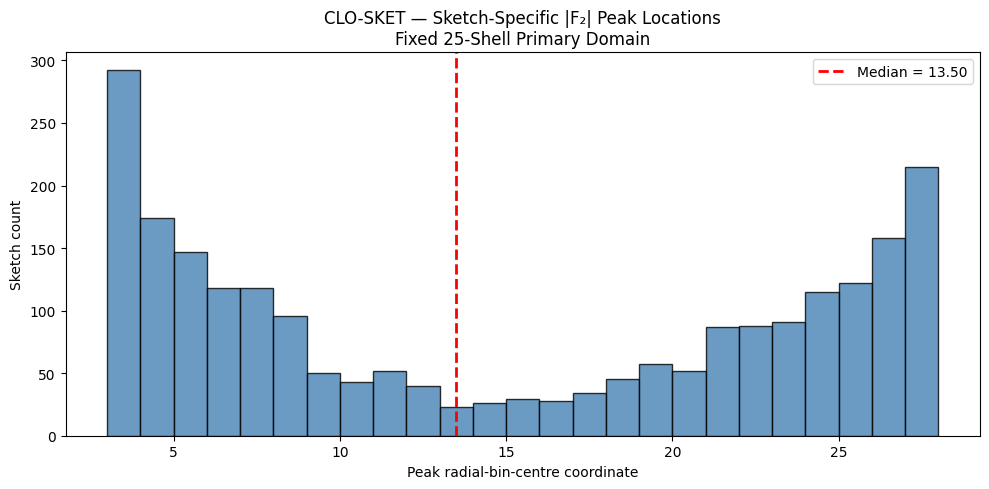

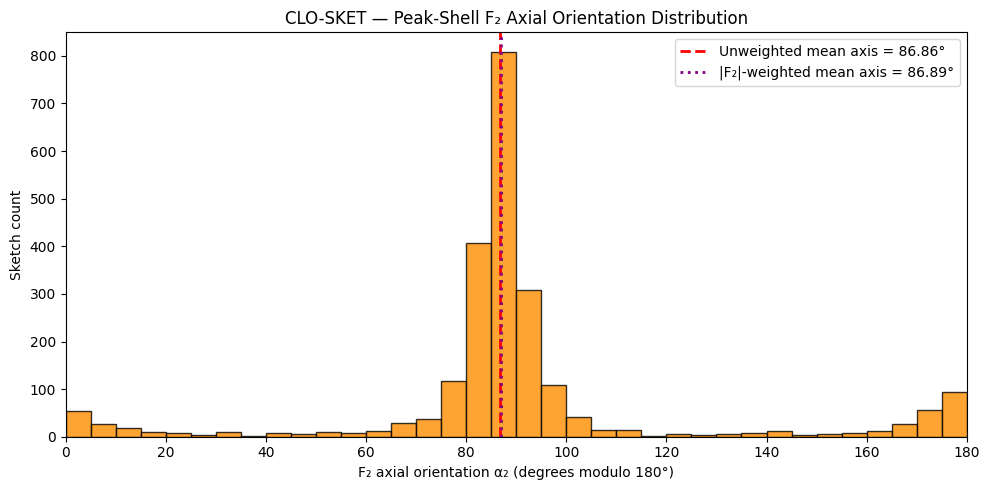

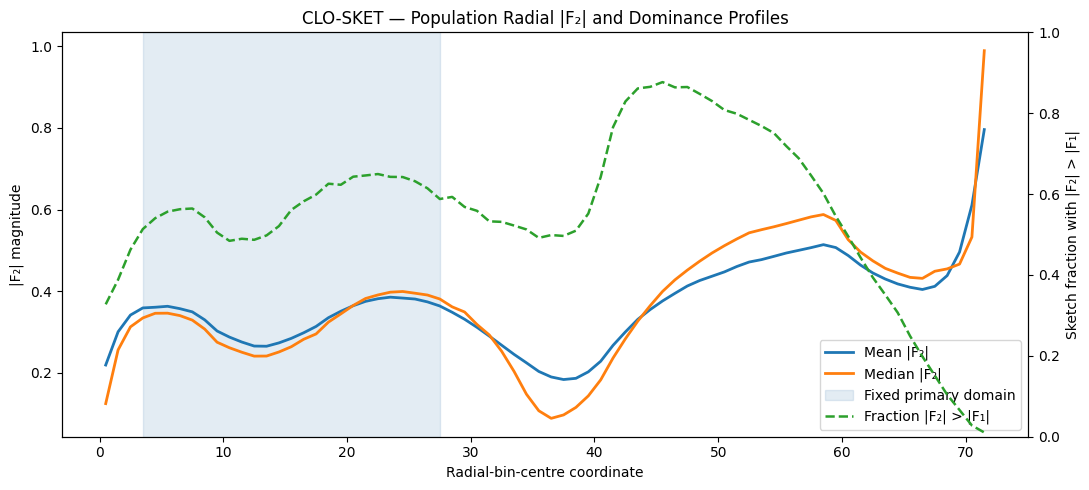


🟢 CELL 16R — CANONICAL F₂ AUDIT COMPLETE

ESTABLISHED:

    1. |F₁|, |F₂| and φ₂ were derived directly from
       the canonical conditional rFFT.

    2. F₂ axial orientation uses:

           α₂ = -arg(F₂)/2 mod 180°.

    3. Sketch-specific peaks were selected only inside
       the fixed 25-shell primary domain.

    4. The retained domain is expressed as:

           radial-bin centres:
               3.5 → 27.5

           normalized radial centres:
               0.048611
               →
               0.381944

    5. The radial peak-location distribution was quantified.

    6. Population axial concentration was quantified using
       doubled-angle circular statistics.

    7. Both unweighted and |F₂|-weighted axial resultants
       were reported.

    8. Peak location–magnitude association was reported
       descriptively.

CLAIM BOUNDARY:

    • Radial coordinates are bin-centre coordinates,
      not physical distances.

    • Axial concentration across sketches is not

In [ ]:
# ============================================================================
# 🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# CELL 16R — CANONICAL F₂ RADIAL + AXIAL CONCENTRATION AUDIT
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n" + "=" * 72)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("CELL 16R — CANONICAL F₂ RADIAL + AXIAL CONCENTRATION AUDIT")
print("=" * 72)


# ============================================================================
# 1. CANONICAL INPUT VERIFICATION
# ============================================================================

print("\nCANONICAL INPUT VERIFICATION")
print("-" * 72)

required = [
    "conditional_fft",
    "radial_centers",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Required canonical variables are missing:\n"
        + "\n".join(f"    - {name}" for name in missing)
    )

F = np.asarray(
    conditional_fft,
    dtype=np.complex128
)

R_BIN = np.asarray(
    radial_centers,
    dtype=np.float64
)

if F.ndim != 3:
    raise RuntimeError(
        "conditional_fft must have shape "
        "(sketch, radial_shell, Fourier_bin); "
        f"received {F.shape}"
    )

if F.shape[-1] < 3:
    raise RuntimeError(
        "conditional_fft does not contain the k=2 coefficient."
    )

N_SKETCHES, N_RADIAL, N_FOURIER = F.shape

if R_BIN.shape != (N_RADIAL,):
    raise RuntimeError(
        "radial_centers must have shape "
        f"({N_RADIAL},); received {R_BIN.shape}"
    )

if N_RADIAL != 72:
    raise RuntimeError(
        f"This audit expects 72 radial shells; received {N_RADIAL}."
    )

# Canonical Fourier-derived fields
F1_COMPLEX = F[..., 1]
F2_COMPLEX = F[..., 2]

F1_MAG = np.abs(F1_COMPLEX)
F2_MAG = np.abs(F2_COMPLEX)
F2_PHASE_RAD = np.angle(F2_COMPLEX)

# α₂ = -arg(F₂)/2, modulo π
F2_AXIS_DEG = (
    np.degrees(-0.5 * F2_PHASE_RAD)
    % 180.0
)

# Phase is undefined when |F₂| is numerically zero.
F2_EPS = 1e-15
F2_AXIS_DEG = np.where(
    F2_MAG > F2_EPS,
    F2_AXIS_DEG,
    np.nan
)

# Corresponding normalized radial-bin centres.
R_NORMALIZED = R_BIN / float(N_RADIAL)

print(f"Conditional Fourier     : {F.shape}")
print(f"F₁ magnitude            : {F1_MAG.shape}")
print(f"F₂ magnitude            : {F2_MAG.shape}")
print(f"F₂ phase                : {F2_PHASE_RAD.shape} | radians")
print(f"F₂ axial orientation    : {F2_AXIS_DEG.shape} | degrees modulo 180°")
print(f"Radial-bin centres      : {R_BIN.shape}")
print(f"Population              : {N_SKETCHES}")
print(f"Fourier bins            : {N_FOURIER}")

print("🟢 CANONICAL INPUTS VERIFIED")


# ============================================================================
# 2. FOURIER / AXIAL CONVENTION
# ============================================================================

print("\nFOURIER / AXIAL CONVENTION")
print("-" * 72)

print(
    """
For the canonical angular rFFT coefficient

    F₂(r) = |F₂(r)| exp(i φ₂(r)),

the corresponding two-fold component is proportional to

    cos(2θ + φ₂(r)).

Therefore its positive axial direction is

    α₂(r) = -φ₂(r) / 2  mod 180°.

The orientation is axial rather than directional:
α₂ and α₂ + 180° represent the same axis.
"""
)


# ============================================================================
# 3. FIXED PRIMARY RADIAL-BIN DOMAIN
# ============================================================================

print("\nFIXED PRIMARY RADIAL-BIN DOMAIN")
print("-" * 72)

# This domain was fixed by the preceding radial audit.
# It is expressed in radial-bin-centre coordinates, not physical distance.

PRIMARY_BIN_MIN = 3.5
PRIMARY_BIN_MAX = 27.5

primary_mask = (
    (R_BIN >= PRIMARY_BIN_MIN)
    & (R_BIN <= PRIMARY_BIN_MAX)
)

primary_indices = np.flatnonzero(primary_mask)

if primary_indices.size != 25:
    raise RuntimeError(
        "Expected 25 retained shells in the fixed primary domain; "
        f"found {primary_indices.size}."
    )

if not np.all(np.diff(primary_indices) == 1):
    raise RuntimeError(
        "The fixed primary radial domain is not contiguous."
    )

print(
    "Radial-bin-centre range : "
    f"{R_BIN[primary_indices[0]]:.4f} → "
    f"{R_BIN[primary_indices[-1]]:.4f}"
)

print(
    "Normalized-centre range : "
    f"{R_NORMALIZED[primary_indices[0]]:.6f} → "
    f"{R_NORMALIZED[primary_indices[-1]]:.6f}"
)

print(f"Retained radial shells   : {primary_indices.size}")

print("🟢 FIXED PRIMARY DOMAIN VERIFIED")


# ============================================================================
# 4. DESCRIPTIVE F₂-vs-F₁ DOMINANCE PROFILE
# ============================================================================

print("\nDESCRIPTIVE F₂-vs-F₁ DOMINANCE PROFILE")
print("-" * 72)

finite_pair = (
    np.isfinite(F1_MAG)
    & np.isfinite(F2_MAG)
)

dominance_profile = np.full(
    N_RADIAL,
    np.nan,
    dtype=np.float64
)

for j in range(N_RADIAL):
    valid = finite_pair[:, j]

    if np.any(valid):
        dominance_profile[j] = np.mean(
            F2_MAG[valid, j] > F1_MAG[valid, j]
        )

primary_dominance = dominance_profile[primary_indices]

print(
    "Mean sketch fraction with |F₂|>|F₁| "
    f"inside fixed domain : {np.nanmean(primary_dominance):.6f}"
)

print(
    "Minimum shell fraction inside domain : "
    f"{np.nanmin(primary_dominance):.6f}"
)

print(
    "Maximum shell fraction inside domain : "
    f"{np.nanmax(primary_dominance):.6f}"
)

print(
    """
This profile is descriptive.

It is not used here to redefine or optimize the retained radial domain.
"""
)


# ============================================================================
# 5. SKETCH-SPECIFIC F₂ PEAK INSIDE FIXED DOMAIN
# ============================================================================

print("\nSKETCH-SPECIFIC F₂ PEAK INSIDE FIXED DOMAIN")
print("-" * 72)

peak_indices = np.full(
    N_SKETCHES,
    -1,
    dtype=np.int64
)

peak_bin_center = np.full(
    N_SKETCHES,
    np.nan,
    dtype=np.float64
)

peak_normalized_center = np.full(
    N_SKETCHES,
    np.nan,
    dtype=np.float64
)

peak_F2 = np.full(
    N_SKETCHES,
    np.nan,
    dtype=np.float64
)

peak_phase_rad = np.full(
    N_SKETCHES,
    np.nan,
    dtype=np.float64
)

peak_axis_deg = np.full(
    N_SKETCHES,
    np.nan,
    dtype=np.float64
)

for i in range(N_SKETCHES):

    local_values = F2_MAG[i, primary_indices]
    valid_local = np.isfinite(local_values)

    if not np.any(valid_local):
        continue

    valid_indices = primary_indices[valid_local]
    local_max_position = np.argmax(local_values[valid_local])
    j = valid_indices[local_max_position]

    if F2_MAG[i, j] <= F2_EPS:
        continue

    peak_indices[i] = j
    peak_bin_center[i] = R_BIN[j]
    peak_normalized_center[i] = R_NORMALIZED[j]
    peak_F2[i] = F2_MAG[i, j]
    peak_phase_rad[i] = F2_PHASE_RAD[i, j]
    peak_axis_deg[i] = F2_AXIS_DEG[i, j]

valid_peak = (
    (peak_indices >= 0)
    & np.isfinite(peak_bin_center)
    & np.isfinite(peak_F2)
    & np.isfinite(peak_axis_deg)
)

N_VALID = int(np.sum(valid_peak))

if N_VALID == 0:
    raise RuntimeError(
        "No sketch has a valid F₂ peak in the fixed primary domain."
    )

print(f"Valid sketches : {N_VALID}/{N_SKETCHES}")
print(
    "Peak selection : maximum |F₂| for each sketch "
    "within the fixed 25-shell domain"
)


# ============================================================================
# 6. RADIAL PEAK-LOCATION DISTRIBUTION
# ============================================================================

print("\nRADIAL PEAK-LOCATION DISTRIBUTION")
print("-" * 72)

rp_bin = peak_bin_center[valid_peak]
rp_norm = peak_normalized_center[valid_peak]
fp = peak_F2[valid_peak]

print(f"Median bin-centre location : {np.median(rp_bin):.4f}")
print(f"Mean bin-centre location   : {np.mean(rp_bin):.4f}")
print(f"SD bin-centre location     : {np.std(rp_bin, ddof=1):.4f}")
print(f"25th percentile            : {np.percentile(rp_bin, 25):.4f}")
print(f"75th percentile            : {np.percentile(rp_bin, 75):.4f}")

print(
    "Median normalized location : "
    f"{np.median(rp_norm):.6f}"
)

print(f"Median peak |F₂|           : {np.median(fp):.8f}")
print(f"Mean peak |F₂|             : {np.mean(fp):.8f}")

median_bin = np.median(rp_bin)

print("\nConcentration around the median peak shell:")

for delta in [2.0, 4.0, 6.0, 8.0]:
    fraction = np.mean(
        np.abs(rp_bin - median_bin) <= delta
    )

    print(
        f"    within ±{delta:.1f} bin-centre units : "
        f"{fraction:.6f}"
    )


# ============================================================================
# 7. AXIAL ORIENTATION CONCENTRATION
# ============================================================================

print("\nF₂ AXIAL ORIENTATION CONCENTRATION")
print("-" * 72)

axes = peak_axis_deg[valid_peak]
weights = peak_F2[valid_peak]

# Axial data have period 180°. Doubling converts them to ordinary
# directional angles with period 360°.
theta2 = np.radians(2.0 * axes)

# Unweighted circular resultant
unweighted_vector = np.mean(
    np.exp(1j * theta2)
)

R_axial = np.abs(unweighted_vector)

mean_axis_deg = (
    0.5
    * np.degrees(np.angle(unweighted_vector))
) % 180.0

# Magnitude-weighted circular resultant
weight_sum = np.sum(weights)

if weight_sum <= 0:
    raise RuntimeError(
        "Peak |F₂| weights do not have positive total mass."
    )

weighted_vector = (
    np.sum(weights * np.exp(1j * theta2))
    / weight_sum
)

R_axial_weighted = np.abs(weighted_vector)

mean_axis_weighted_deg = (
    0.5
    * np.degrees(np.angle(weighted_vector))
) % 180.0


def axial_difference_deg(a, b):
    """Smallest difference between 180°-periodic axial angles."""
    return np.abs(
        ((np.asarray(a) - b + 90.0) % 180.0) - 90.0
    )


axis_deviation_deg = axial_difference_deg(
    axes,
    mean_axis_deg
)

weighted_axis_deviation_deg = axial_difference_deg(
    axes,
    mean_axis_weighted_deg
)

print(f"Unweighted mean axis        : {mean_axis_deg:.4f}°")
print(f"Unweighted axial resultant  : {R_axial:.6f}")

print(
    f"|F₂|-weighted mean axis     : "
    f"{mean_axis_weighted_deg:.4f}°"
)

print(
    f"|F₂|-weighted resultant     : "
    f"{R_axial_weighted:.6f}"
)

print(
    f"Median deviation from unweighted mean : "
    f"{np.median(axis_deviation_deg):.4f}°"
)

print(
    f"Mean deviation from unweighted mean   : "
    f"{np.mean(axis_deviation_deg):.4f}°"
)

print("\nFraction within axial-deviation thresholds:")

for threshold in [15.0, 30.0, 45.0, 60.0, 90.0]:
    fraction = np.mean(
        axis_deviation_deg <= threshold
    )

    print(
        f"    ≤ {threshold:4.0f}° : "
        f"{fraction:.6f}"
    )

print(
    """
Interpretation:

    R_axial → 1
        peak-shell axes are concentrated around a common
        population-level axial direction.

    R_axial → 0
        peak-shell axes are broadly distributed.

This is a cross-sketch concentration audit.
It is not, by itself, a longitudinal or perturbation-based
test of statistical stability.
"""
)


# ============================================================================
# 8. PEAK-LOCATION / PEAK-MAGNITUDE ASSOCIATION
# ============================================================================

print("\nPEAK-LOCATION / PEAK-MAGNITUDE ASSOCIATION")
print("-" * 72)


def average_ranks(values):
    """Average ranks for tied values; ranks begin at 1."""
    values = np.asarray(values, dtype=np.float64)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]

    ranked_sorted = np.empty(
        values.size,
        dtype=np.float64
    )

    start = 0

    while start < values.size:
        end = start + 1

        while (
            end < values.size
            and sorted_values[end] == sorted_values[start]
        ):
            end += 1

        ranked_sorted[start:end] = (
            (start + 1 + end) / 2.0
        )

        start = end

    ranks = np.empty_like(ranked_sorted)
    ranks[order] = ranked_sorted

    return ranks


valid_association = (
    np.isfinite(rp_bin)
    & np.isfinite(fp)
)

association_x = rp_bin[valid_association]
association_y = fp[valid_association]

if association_x.size >= 3:

    rank_x = average_ranks(association_x)
    rank_y = average_ranks(association_y)

    rank_x -= np.mean(rank_x)
    rank_y -= np.mean(rank_y)

    denominator = np.sqrt(
        np.sum(rank_x**2)
        * np.sum(rank_y**2)
    )

    if denominator > 0:
        peak_location_magnitude_rho = (
            np.sum(rank_x * rank_y)
            / denominator
        )
    else:
        peak_location_magnitude_rho = np.nan

else:
    peak_location_magnitude_rho = np.nan

print(
    "Spearman rank correlation : "
    f"{peak_location_magnitude_rho:.6f}"
)

print(
    """
This measures a descriptive association between:

    • where the strongest retained-domain |F₂| occurs, and
    • the magnitude of that peak.

It does not establish causality, semantics, garment-part identity,
or category identity.
"""
)


# ============================================================================
# 9. POPULATION RADIAL |F₂| PROFILE
# ============================================================================

print("\nPOPULATION RADIAL |F₂| PROFILE")
print("-" * 72)

mean_F2_radial = np.nanmean(
    F2_MAG,
    axis=0
)

median_F2_radial = np.nanmedian(
    F2_MAG,
    axis=0
)

primary_mean_profile = mean_F2_radial[primary_indices]

population_primary_peak_local = np.nanargmax(
    primary_mean_profile
)

population_primary_peak_idx = primary_indices[
    population_primary_peak_local
]

population_primary_peak_bin = R_BIN[
    population_primary_peak_idx
]

population_primary_peak_normalized = R_NORMALIZED[
    population_primary_peak_idx
]

population_primary_peak_value = mean_F2_radial[
    population_primary_peak_idx
]

print(
    "Population mean |F₂| peak inside fixed domain:"
)

print(
    f"    radial-bin centre : "
    f"{population_primary_peak_bin:.4f}"
)

print(
    f"    normalized centre : "
    f"{population_primary_peak_normalized:.6f}"
)

print(
    f"    mean |F₂|         : "
    f"{population_primary_peak_value:.8f}"
)


# ============================================================================
# 10. DIRECT SOURCE-CONSISTENCY CHECK
# ============================================================================

print("\nDIRECT SOURCE-CONSISTENCY CHECK")
print("-" * 72)

magnitude_error = np.nanmax(
    np.abs(
        F2_MAG
        - np.abs(conditional_fft[..., 2])
    )
)

axis_recomputed = (
    np.degrees(
        -0.5 * np.angle(conditional_fft[..., 2])
    )
    % 180.0
)

valid_axis_check = (
    (F2_MAG > F2_EPS)
    & np.isfinite(F2_AXIS_DEG)
    & np.isfinite(axis_recomputed)
)

axis_error = np.nanmax(
    axial_difference_deg(
        F2_AXIS_DEG[valid_axis_check],
        axis_recomputed[valid_axis_check]
    )
)

print(f"Maximum |F₂| source error : {magnitude_error:.6e}")
print(f"Maximum axial-axis error  : {axis_error:.6e}°")

if magnitude_error > 1e-12:
    raise RuntimeError(
        "F₂ magnitude is inconsistent with the canonical rFFT source."
    )

if axis_error > 1e-10:
    raise RuntimeError(
        "F₂ axial orientation is inconsistent with "
        "α₂ = -arg(F₂)/2 mod 180°."
    )

print("🟢 CANONICAL F₂ SOURCE VERIFIED")


# ============================================================================
# 11. VISUALIZATION
# ============================================================================

print("\nGENERATING AUDIT VISUALIZATIONS")
print("-" * 72)

# --------------------------------------------------------------------------
# A. Distribution of sketch-specific peak radial-bin centres
# --------------------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    rp_bin,
    bins=np.arange(
        PRIMARY_BIN_MIN - 0.5,
        PRIMARY_BIN_MAX + 1.5,
        1.0
    ),
    color="steelblue",
    alpha=0.80,
    edgecolor="black"
)

plt.axvline(
    np.median(rp_bin),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {np.median(rp_bin):.2f}"
)

plt.xlabel("Peak radial-bin-centre coordinate")
plt.ylabel("Sketch count")

plt.title(
    "CLO-SKET — Sketch-Specific |F₂| Peak Locations\n"
    "Fixed 25-Shell Primary Domain"
)

plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# B. Distribution of sketch-specific F₂ axial orientations
# --------------------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    axes,
    bins=np.linspace(0.0, 180.0, 37),
    color="darkorange",
    alpha=0.80,
    edgecolor="black"
)

plt.axvline(
    mean_axis_deg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Unweighted mean axis = {mean_axis_deg:.2f}°"
)

plt.axvline(
    mean_axis_weighted_deg,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=(
        f"|F₂|-weighted mean axis = "
        f"{mean_axis_weighted_deg:.2f}°"
    )
)

plt.xlim(0.0, 180.0)
plt.xlabel("F₂ axial orientation α₂ (degrees modulo 180°)")
plt.ylabel("Sketch count")

plt.title(
    "CLO-SKET — Peak-Shell F₂ Axial Orientation Distribution"
)

plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# C. Population radial |F₂| profile and F₂-vs-F₁ dominance
# --------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    R_BIN,
    mean_F2_radial,
    color="tab:blue",
    linewidth=2,
    label="Mean |F₂|"
)

ax1.plot(
    R_BIN,
    median_F2_radial,
    color="tab:orange",
    linewidth=2,
    label="Median |F₂|"
)

ax1.axvspan(
    PRIMARY_BIN_MIN,
    PRIMARY_BIN_MAX,
    color="steelblue",
    alpha=0.15,
    label="Fixed primary domain"
)

ax1.set_xlabel("Radial-bin-centre coordinate")
ax1.set_ylabel("|F₂| magnitude")

ax2 = ax1.twinx()

ax2.plot(
    R_BIN,
    dominance_profile,
    color="tab:green",
    linewidth=1.8,
    linestyle="--",
    label="Fraction |F₂| > |F₁|"
)

ax2.set_ylabel("Sketch fraction with |F₂| > |F₁|")
ax2.set_ylim(0.0, 1.0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.title(
    "CLO-SKET — Population Radial |F₂| and Dominance Profiles"
)

fig.tight_layout()
plt.show()


# ============================================================================
# 12. FINAL AUDIT SUMMARY
# ============================================================================

print("\n" + "=" * 72)
print("🟢 CELL 16R — CANONICAL F₂ AUDIT COMPLETE")
print("=" * 72)

print(
    f"""
ESTABLISHED:

    1. |F₁|, |F₂| and φ₂ were derived directly from
       the canonical conditional rFFT.

    2. F₂ axial orientation uses:

           α₂ = -arg(F₂)/2 mod 180°.

    3. Sketch-specific peaks were selected only inside
       the fixed 25-shell primary domain.

    4. The retained domain is expressed as:

           radial-bin centres:
               {PRIMARY_BIN_MIN:.1f} → {PRIMARY_BIN_MAX:.1f}

           normalized radial centres:
               {R_NORMALIZED[primary_indices[0]]:.6f}
               →
               {R_NORMALIZED[primary_indices[-1]]:.6f}

    5. The radial peak-location distribution was quantified.

    6. Population axial concentration was quantified using
       doubled-angle circular statistics.

    7. Both unweighted and |F₂|-weighted axial resultants
       were reported.

    8. Peak location–magnitude association was reported
       descriptively.

CLAIM BOUNDARY:

    • Radial coordinates are bin-centre coordinates,
      not physical distances.

    • Axial concentration across sketches is not equivalent
      to longitudinal, perturbation, or resampling stability.

    • No semantic, garment-part, category, classifier,
      clustering, PCA, thresholding, resizing, or rotation
      claim is made.
"""
)

print("=" * 72)

## 5. Canonical F₂ radial and α₂ descriptors

The next two cells construct the 9 radial summaries and 7 axial summaries from the frozen field.


🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION

INPUT VERIFICATION
------------------------------------------------------------------------
F₂ magnitude source : F2_mag
F₂ magnitude shape  : (2300, 72)
Radial centers      : (72,)
Population          : 2300
🟢 CANONICAL F₂ INPUT VERIFIED

CANONICAL F₂ REPRESENTATION
------------------------------------------------------------------------

The canonical radial F₂ field is defined as:

    m_i(r) = |F₂_i(r)|

using the historically validated F2_mag object.

IMPORTANT:

    F2_mag is NOT reconstructed from conditional_fourier here.

    Historical provenance was established in CELL 20E:

        peak_F2
            =
        max(F2_primary)

    with:

        correlation = 1
        RMSE        = 0

    Therefore F2_mag is the authoritative magnitude
    representation for the descriptor chain.

PRIMARY F₂ RADIAL ZONE
-------------------------------------------------------------------

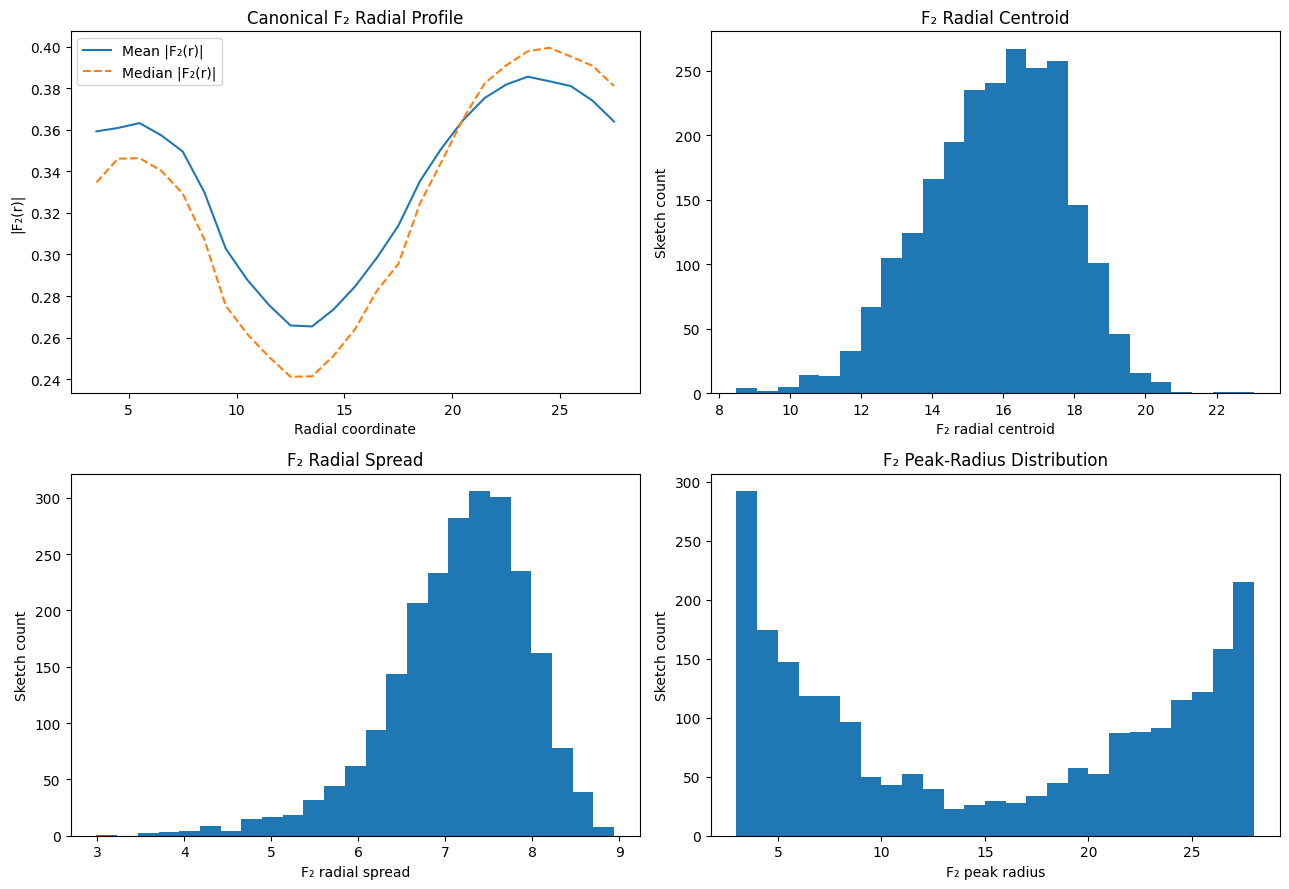


🟢 CELL 20 — CANONICAL F₂ RADIAL DESCRIPTOR AUDIT COMPLETE

CANONICAL REPRESENTATION
------------------------

    F₂(r) = F2_mag

restricted to:

    r = 3.5 → 27.5


HISTORICAL PROVENANCE
---------------------

    peak_F2
        =
    max(F2_mag within primary zone)

Historical identity is checked explicitly
within this cell.


DESCRIPTORS
-----------

    F2_integral
    F2_radial_centroid
    F2_radial_spread
    F2_radial_concentration
    F2_onset_radius
    F2_termination_radius
    F2_radial_extent
    F2_peak_radius
    F2_peak_magnitude


SCIENTIFIC ROLE
---------------

These descriptors convert the validated
radial F₂ field into interpretable
sketch-level geometric quantities.

They describe:

    amount
    location
    spread
    concentration
    support
    peak


IMPORTANT
---------

No category information was used.

No semantic label was assigned.

No classifier was trained.

No clustering was performed.

No image thresholding was performed.

No image resizing was 

In [ ]:
# ========================================================================
# 🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION
# ========================================================================

print("=" * 72)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION")
print("=" * 72)


# ========================================================================
# 1. INPUT VERIFICATION
# ========================================================================

print("\nINPUT VERIFICATION")
print("-" * 72)

required = {
    "F2_mag": "F2_mag",
    "radial_centers": "radial_centers",
}

missing = [
    name for name, var in required.items()
    if var not in globals()
]

if missing:
    raise RuntimeError(
        "Required canonical F₂ variables are missing:\n"
        + "\n".join(f"    - {x}" for x in missing)
        + "\n\n"
        "F2_mag must be the validated F₂ magnitude field "
        "recovered in CELL 20E."
    )

F2_MAG = np.asarray(F2_mag, dtype=float)
R = np.asarray(radial_centers, dtype=float)

if F2_MAG.ndim != 2:
    raise RuntimeError(
        f"F2_mag must have shape (sketch, radial), "
        f"received {F2_MAG.shape}"
    )

N_SKETCH, N_RADIAL = F2_MAG.shape

if R.ndim != 1 or len(R) != N_RADIAL:
    raise RuntimeError(
        "radial_centers is incompatible with F2_mag:\n"
        f"    F2_mag       : {F2_MAG.shape}\n"
        f"    radial_centers: {R.shape}"
    )

print(f"F₂ magnitude source : F2_mag")
print(f"F₂ magnitude shape  : {F2_MAG.shape}")
print(f"Radial centers      : {R.shape}")
print(f"Population          : {N_SKETCH}")
print("🟢 CANONICAL F₂ INPUT VERIFIED")


# ========================================================================
# 2. CANONICAL REPRESENTATION DEFINITION
# ========================================================================

print("\nCANONICAL F₂ REPRESENTATION")
print("-" * 72)

print("""
The canonical radial F₂ field is defined as:

    m_i(r) = |F₂_i(r)|

using the historically validated F2_mag object.

IMPORTANT:

    F2_mag is NOT reconstructed from conditional_fourier here.

    Historical provenance was established in CELL 20E:

        peak_F2
            =
        max(F2_primary)

    with:

        correlation = 1
        RMSE        = 0

    Therefore F2_mag is the authoritative magnitude
    representation for the descriptor chain.
""")


# ========================================================================
# 3. RECOVER ESTABLISHED PRIMARY RADIAL ZONE
# ========================================================================

print("PRIMARY F₂ RADIAL ZONE")
print("-" * 72)

# Prefer the previously established Cell 13 zone.
# If its indices are not available, recover the same fixed radial zone.

if "primary_zone_mask" in globals():

    zone_mask = np.asarray(primary_zone_mask, dtype=bool)

elif "primary_zone_indices" in globals():

    zone_mask = np.zeros(N_RADIAL, dtype=bool)
    zone_mask[np.asarray(primary_zone_indices, dtype=int)] = True

else:

    # Canonical zone established by Cell 13:
    # radius = 3.5 → 27.5
    zone_mask = (R >= 3.5) & (R <= 27.5)


if not np.any(zone_mask):
    raise RuntimeError(
        "No valid primary radial zone could be recovered."
    )

zone_idx = np.where(zone_mask)[0]
zone_r = R[zone_mask]
zone_f2 = F2_MAG[:, zone_mask]

print(
    f"Primary zone : "
    f"{zone_r[0]:.4f} → {zone_r[-1]:.4f}"
)

print(f"Radial shells: {len(zone_r)}")
print("🟢 ESTABLISHED ZONE RECOVERED")


# ========================================================================
# 4. NUMERICAL VALIDITY
# ========================================================================

print("\nNUMERICAL VALIDITY")
print("-" * 72)

finite_mask = np.isfinite(zone_f2)

valid_sketch = np.any(finite_mask, axis=1)

print(
    f"Valid sketches : "
    f"{np.sum(valid_sketch)}/{N_SKETCH}"
)

if not np.all(valid_sketch):
    print(
        "⚠️ Some sketches contain no finite F₂ values "
        "inside the primary zone."
    )

# Replace invalid values only for numerical integration.
# This does NOT alter the canonical F₂ field.
zone_f2_safe = np.where(
    np.isfinite(zone_f2),
    zone_f2,
    0.0
)

if np.any(zone_f2_safe < 0):
    raise RuntimeError(
        "F2_mag contains negative values. "
        "A magnitude field must be non-negative."
    )

print("🟢 F₂ MAGNITUDE FIELD VALID")


# ========================================================================
# 5. RADIAL INTEGRATION WEIGHTS
# ========================================================================

# The radial centers are uniformly spaced in the current representation.
# np.gradient provides the radial differential element without assuming
# a hard-coded spacing.

dr = np.gradient(zone_r)

if np.any(dr <= 0):
    raise RuntimeError(
        "Radial centers are not strictly increasing."
    )


# ========================================================================
# 6. F₂ RADIAL DESCRIPTORS
# ========================================================================

print("\nF₂ RADIAL DESCRIPTOR DEFINITIONS")
print("-" * 72)

print("""
For every sketch:

    m(r) = |F₂(r)|

inside the established primary radial zone.

Descriptors:

    1. F₂ integral

           ∫ m(r) dr

    2. F₂ radial centroid

           ∫ r m(r) dr
           -------------
             ∫ m(r) dr

    3. F₂ radial spread

           sqrt[
               ∫ (r-r̄)² m(r) dr
               ------------------
                    ∫ m(r) dr
           ]

    4. F₂ radial concentration

       Fraction of integrated F₂ magnitude
       contained within ±4 radial units of
       the sketch-specific F₂ peak.

    5. F₂ onset radius

       First radius where:

           m(r) ≥ 0.10 × peak(m)

    6. F₂ termination radius

       Last radius satisfying the same threshold.

    7. F₂ radial extent

           termination - onset

    8. F₂ peak radius

           argmax m(r)

    9. F₂ peak magnitude

           max m(r)

No category information is used.
""")


# ========================================================================
# 7. PREALLOCATE DESCRIPTORS
# ========================================================================

F2_integral = np.full(N_SKETCH, np.nan)
F2_radial_centroid = np.full(N_SKETCH, np.nan)
F2_radial_spread = np.full(N_SKETCH, np.nan)
F2_radial_concentration = np.full(N_SKETCH, np.nan)

F2_onset_radius = np.full(N_SKETCH, np.nan)
F2_termination_radius = np.full(N_SKETCH, np.nan)
F2_radial_extent = np.full(N_SKETCH, np.nan)

F2_peak_radius = np.full(N_SKETCH, np.nan)
F2_peak_magnitude = np.full(N_SKETCH, np.nan)


# ========================================================================
# 8. COMPUTE SKETCH-LEVEL DESCRIPTORS
# ========================================================================

print("\nCOMPUTING SKETCH-LEVEL RADIAL DESCRIPTORS")
print("-" * 72)

for i in range(N_SKETCH):

    m = zone_f2_safe[i]

    if not np.any(m > 0):
        continue

    # ------------------------------------------------------------
    # Peak
    # ------------------------------------------------------------

    peak_idx = int(np.argmax(m))
    peak_value = float(m[peak_idx])
    peak_radius = float(zone_r[peak_idx])

    F2_peak_magnitude[i] = peak_value
    F2_peak_radius[i] = peak_radius

    if peak_value <= 0:
        continue

    # ------------------------------------------------------------
    # Integral
    # ------------------------------------------------------------

    mass = float(np.sum(m * dr))

    if mass <= 0:
        continue

    F2_integral[i] = mass

    # ------------------------------------------------------------
    # Radial centroid
    # ------------------------------------------------------------

    centroid = float(
        np.sum(zone_r * m * dr) / mass
    )

    F2_radial_centroid[i] = centroid

    # ------------------------------------------------------------
    # Radial spread
    # ------------------------------------------------------------

    variance = float(
        np.sum(
            ((zone_r - centroid) ** 2)
            * m
            * dr
        )
        / mass
    )

    F2_radial_spread[i] = np.sqrt(
        max(variance, 0.0)
    )

    # ------------------------------------------------------------
    # Radial concentration around peak
    # ------------------------------------------------------------

    concentration_mask = (
        np.abs(zone_r - peak_radius) <= 4.0
    )

    local_mass = float(
        np.sum(
            m[concentration_mask]
            * dr[concentration_mask]
        )
    )

    F2_radial_concentration[i] = (
        local_mass / mass
    )

    # ------------------------------------------------------------
    # 10% peak threshold
    # ------------------------------------------------------------

    threshold = 0.10 * peak_value

    above = m >= threshold

    if np.any(above):

        onset_idx = int(np.where(above)[0][0])
        termination_idx = int(np.where(above)[0][-1])

        onset = float(zone_r[onset_idx])
        termination = float(zone_r[termination_idx])

        F2_onset_radius[i] = onset
        F2_termination_radius[i] = termination

        F2_radial_extent[i] = (
            termination - onset
        )


# ========================================================================
# 9. HISTORICAL PEAK_F2 CONSISTENCY CHECK
# ========================================================================

print("\nHISTORICAL PEAK_F₂ CONSISTENCY CHECK")
print("-" * 72)

if "peak_F2" in globals():

    historical_peak = np.asarray(
        peak_F2,
        dtype=float
    )

    same_shape = (
        historical_peak.shape
        == F2_peak_magnitude.shape
    )

    if same_shape:

        difference = np.abs(
            historical_peak
            - F2_peak_magnitude
        )

        finite_compare = (
            np.isfinite(historical_peak)
            & np.isfinite(F2_peak_magnitude)
        )

        if np.any(finite_compare):

            max_diff = float(
                np.max(
                    difference[finite_compare]
                )
            )

            mean_diff = float(
                np.mean(
                    difference[finite_compare]
                )
            )

            print(
                f"Maximum absolute difference : "
                f"{max_diff:.12e}"
            )

            print(
                f"Mean absolute difference    : "
                f"{mean_diff:.12e}"
            )

            if max_diff < 1e-12:
                print(
                    "🟢 HISTORICAL peak_F2 REPRODUCED "
                    "EXACTLY"
                )
            else:
                raise RuntimeError(
                    "Canonical F₂ peak does not reproduce "
                    "historical peak_F2."
                )

        else:
            raise RuntimeError(
                "No finite values available for "
                "historical peak_F2 comparison."
            )

    else:
        raise RuntimeError(
            "Historical peak_F2 shape does not match "
            "canonical descriptor shape."
        )

else:

    print(
        "⚠️ historical peak_F2 not available; "
        "provenance check skipped."
    )


# ========================================================================
# 10. DESCRIPTOR VALIDITY
# ========================================================================

print("\nDESCRIPTOR VALIDITY")
print("-" * 72)

descriptor_arrays = {
    "F2_integral": F2_integral,
    "F2_radial_centroid": F2_radial_centroid,
    "F2_radial_spread": F2_radial_spread,
    "F2_radial_concentration": F2_radial_concentration,
    "F2_onset_radius": F2_onset_radius,
    "F2_termination_radius": F2_termination_radius,
    "F2_radial_extent": F2_radial_extent,
    "F2_peak_radius": F2_peak_radius,
    "F2_peak_magnitude": F2_peak_magnitude,
}

for name, values in descriptor_arrays.items():

    n_valid = int(
        np.sum(np.isfinite(values))
    )

    print(
        f"{name:<30} "
        f"{n_valid}/{N_SKETCH} valid"
    )


# ========================================================================
# 11. POPULATION SUMMARY
# ========================================================================

summary_rows = []

for name, values in descriptor_arrays.items():

    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        summary_rows.append({
            "descriptor": name,
            "mean": np.nan,
            "median": np.nan,
            "sd": np.nan,
            "min": np.nan,
            "max": np.nan,
        })
        continue

    summary_rows.append({
        "descriptor": name,
        "mean": np.mean(finite),
        "median": np.median(finite),
        "sd": np.std(finite, ddof=1),
        "min": np.min(finite),
        "max": np.max(finite),
    })

f2_radial_summary = pd.DataFrame(
    summary_rows
)

print("\nPOPULATION RADIAL DESCRIPTOR SUMMARY")
print("-" * 72)

print(
    f2_radial_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ========================================================================
# 12. CONSTRUCT ONE ROW PER SKETCH
# ========================================================================

f2_radial_descriptors = pd.DataFrame({
    "F2_integral": F2_integral,
    "F2_radial_centroid": F2_radial_centroid,
    "F2_radial_spread": F2_radial_spread,
    "F2_radial_concentration": F2_radial_concentration,
    "F2_onset_radius": F2_onset_radius,
    "F2_termination_radius": F2_termination_radius,
    "F2_radial_extent": F2_radial_extent,
    "F2_peak_radius": F2_peak_radius,
    "F2_peak_magnitude": F2_peak_magnitude,
})


# ========================================================================
# 13. EXPORT CANONICAL OBJECTS
# ========================================================================

# Explicit aliases used by later cells.

f2_canonical_radial = zone_f2.copy()

f2_canonical_radii = zone_r.copy()

f2_canonical_zone_mask = zone_mask.copy()


# ========================================================================
# 14. VISUALIZATION
# ========================================================================

print("\nGENERATING RADIAL DESCRIPTOR VISUALIZATION")
print("-" * 72)

try:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13, 9)
    )

    # Population F₂ radial profile
    mean_profile = np.nanmean(
        zone_f2,
        axis=0
    )

    median_profile = np.nanmedian(
        zone_f2,
        axis=0
    )

    axes[0, 0].plot(
        zone_r,
        mean_profile,
        label="Mean |F₂(r)|"
    )

    axes[0, 0].plot(
        zone_r,
        median_profile,
        linestyle="--",
        label="Median |F₂(r)|"
    )

    axes[0, 0].set_xlabel(
        "Radial coordinate"
    )

    axes[0, 0].set_ylabel(
        "|F₂(r)|"
    )

    axes[0, 0].set_title(
        "Canonical F₂ Radial Profile"
    )

    axes[0, 0].legend()

    # Radial centroid
    axes[0, 1].hist(
        F2_radial_centroid[
            np.isfinite(F2_radial_centroid)
        ],
        bins=25
    )

    axes[0, 1].set_xlabel(
        "F₂ radial centroid"
    )

    axes[0, 1].set_ylabel(
        "Sketch count"
    )

    axes[0, 1].set_title(
        "F₂ Radial Centroid"
    )

    # Radial spread
    axes[1, 0].hist(
        F2_radial_spread[
            np.isfinite(F2_radial_spread)
        ],
        bins=25
    )

    axes[1, 0].set_xlabel(
        "F₂ radial spread"
    )

    axes[1, 0].set_ylabel(
        "Sketch count"
    )

    axes[1, 0].set_title(
        "F₂ Radial Spread"
    )

    # Peak radius
    axes[1, 1].hist(
        F2_peak_radius[
            np.isfinite(F2_peak_radius)
        ],
        bins=np.arange(
            zone_r[0] - 0.5,
            zone_r[-1] + 1.5,
            1.0
        )
    )

    axes[1, 1].set_xlabel(
        "F₂ peak radius"
    )

    axes[1, 1].set_ylabel(
        "Sketch count"
    )

    axes[1, 1].set_title(
        "F₂ Peak-Radius Distribution"
    )

    plt.tight_layout()
    plt.show()

except Exception as exc:

    print(
        f"⚠️ Visualization skipped: {exc}"
    )


# ========================================================================
# 15. FINAL AUDIT
# ========================================================================

print("\n" + "=" * 72)
print("🟢 CELL 20 — CANONICAL F₂ RADIAL DESCRIPTOR AUDIT COMPLETE")
print("=" * 72)

print("""
CANONICAL REPRESENTATION
------------------------

    F₂(r) = F2_mag

restricted to:

    r = 3.5 → 27.5


HISTORICAL PROVENANCE
---------------------

    peak_F2
        =
    max(F2_mag within primary zone)

Historical identity is checked explicitly
within this cell.


DESCRIPTORS
-----------

    F2_integral
    F2_radial_centroid
    F2_radial_spread
    F2_radial_concentration
    F2_onset_radius
    F2_termination_radius
    F2_radial_extent
    F2_peak_radius
    F2_peak_magnitude


SCIENTIFIC ROLE
---------------

These descriptors convert the validated
radial F₂ field into interpretable
sketch-level geometric quantities.

They describe:

    amount
    location
    spread
    concentration
    support
    peak


IMPORTANT
---------

No category information was used.

No semantic label was assigned.

No classifier was trained.

No clustering was performed.

No image thresholding was performed.

No image resizing was performed.

No rotation was performed.


NEXT
----

CELL 21

    α₂ RADIAL / AXIAL DESCRIPTORS

followed by:

    CELL 22
        radial–angular relational features

    CELL 23
        feature-family correlation /
        redundancy audit

    CELL 24
        controlled category discrimination
""")

print("=" * 72)


🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION

INPUT VERIFICATION
------------------------------------------------------------------------
F₂ magnitude source : F2_mag
F₂ magnitude shape  : (2300, 72)
Radial centers      : (72,)
Population          : 2300
Radial shells       : 72
Conditional Fourier : (2300, 72, 37) [conditional_fft]
🟢 REQUIRED CANONICAL F₂ OBJECTS VERIFIED

DIRECT CANONICAL-SOURCE CHECK
------------------------------------------------------------------------
Canonical definition : |conditional_fft[..., 2]|
Maximum source error : 0.000000000000e+00
Mean source error    : 0.000000000000e+00
🟢 F2_mag VERIFIED AGAINST THE CANONICAL k=2 rFFT COEFFICIENT

PRIMARY F₂ RADIAL DOMAIN
------------------------------------------------------------------------
Primary zone          : 3.5000 → 27.5000
Retained shells       : 25
Coordinate span       : 24.0000 radial-bin units
Uniform shell spacing : True
Shell-center spacing  :

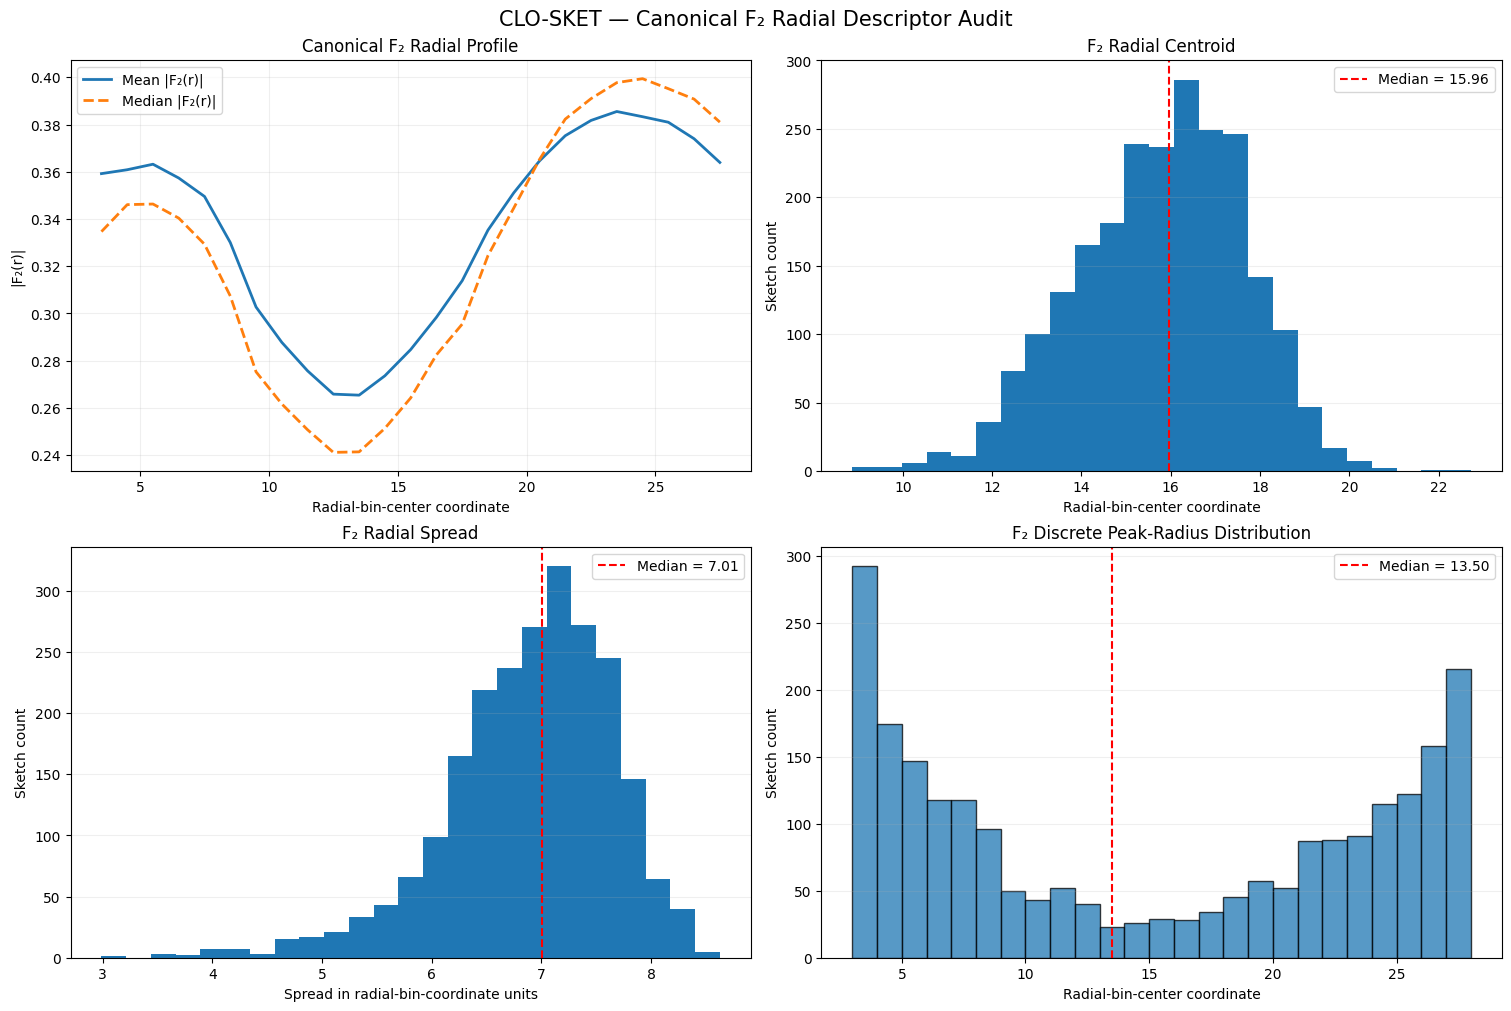


🟢 CANONICAL F₂ RADIAL DESCRIPTOR AUDIT COMPLETE

CANONICAL REPRESENTATION
------------------------

    F₂(r) = F2_mag

restricted to:

    radial-bin centers = 3.5 → 27.5
    retained shells    = 25


SOURCE CONSISTENCY
------------------

    F2_mag was verified elementwise against the magnitude of conditional_fft[..., 2].

    Historical peak_F2 was reproduced exactly as:

        peak_F2
            =
        max(F2_mag inside the fixed primary domain)


DESCRIPTORS
-----------

    F2_integral
    F2_radial_centroid
    F2_radial_spread
    F2_radial_concentration
    F2_onset_radius
    F2_termination_radius
    F2_radial_extent
    F2_peak_radius
    F2_peak_magnitude


SEPARATE AUDIT VARIABLES
------------------------

    F2_onset_left_censored
    F2_termination_right_censored
    F2_extent_domain_spanning
    F2_concentration_window_clipped
    F2_concentration_window_span
    F2_peak_at_left_boundary
    F2_peak_at_right_boundary
    F2_peak_at_domain_boundary
    F2_peak_

In [ ]:
# ============================================================================
# CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================================
# DISPLAY HEADER
# ============================================================================

print("=" * 72)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("AUDITED — CANONICAL F₂ RADIAL DESCRIPTOR CONSTRUCTION")
print("=" * 72)


# ============================================================================
# CONFIGURATION
# ============================================================================

PRIMARY_RADIUS_MIN = 3.5
PRIMARY_RADIUS_MAX = 27.5

RELATIVE_SUPPORT_THRESHOLD = 0.10
CONCENTRATION_HALF_WIDTH = 4.0

SOURCE_CHECK_ATOL = 1e-12


# ============================================================================
# REQUIRED CANONICAL OBJECTS
# ============================================================================

required_objects = [
    "F2_mag",
    "radial_centers",
    "peak_F2",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing required canonical object(s): "
        + ", ".join(missing_objects)
    )


# Recognize either Fourier-array name used in the notebook.
if "conditional_fft" in globals():
    conditional_fourier_source = np.asarray(conditional_fft)
    conditional_fourier_source_name = "conditional_fft"

elif "conditional_fourier" in globals():
    conditional_fourier_source = np.asarray(conditional_fourier)
    conditional_fourier_source_name = "conditional_fourier"

else:
    conditional_fourier_source = None
    conditional_fourier_source_name = None


F2_mag_arr = np.asarray(F2_mag, dtype=float)

radial_centers_arr = np.asarray(
    radial_centers,
    dtype=float,
).reshape(-1)

historical_peak_F2 = np.asarray(
    peak_F2,
    dtype=float,
).reshape(-1)


# ============================================================================
# INPUT-SHAPE VERIFICATION
# ============================================================================

if F2_mag_arr.ndim != 2:
    raise ValueError(
        "F2_mag must have shape "
        "(population, radial shells)."
    )

if radial_centers_arr.ndim != 1:
    raise ValueError(
        "radial_centers must be one-dimensional."
    )

if F2_mag_arr.shape[1] != radial_centers_arr.size:
    raise ValueError(
        "The radial dimension of F2_mag does not match "
        "the length of radial_centers."
    )

if historical_peak_F2.size != F2_mag_arr.shape[0]:
    raise ValueError(
        "The length of peak_F2 does not match the "
        "F2_mag population size."
    )


population_size, radial_shell_count = F2_mag_arr.shape


print("\nINPUT VERIFICATION")
print("-" * 72)
print("F₂ magnitude source : F2_mag")
print(f"F₂ magnitude shape  : {F2_mag_arr.shape}")
print(f"Radial centers      : {radial_centers_arr.shape}")
print(f"Population          : {population_size}")
print(f"Radial shells       : {radial_shell_count}")

if conditional_fourier_source is not None:
    print(
        f"Conditional Fourier : "
        f"{conditional_fourier_source.shape} "
        f"[{conditional_fourier_source_name}]"
    )
else:
    print(
        "Conditional Fourier : "
        "not present in current namespace"
    )

print("🟢 REQUIRED CANONICAL F₂ OBJECTS VERIFIED")


# ============================================================================
# DIRECT CANONICAL-SOURCE CHECK
# ============================================================================

direct_source_check_performed = False
direct_source_check_passed = False

max_source_error = np.nan
mean_source_error = np.nan


print("\nDIRECT CANONICAL-SOURCE CHECK")
print("-" * 72)


if conditional_fourier_source is not None:

    if conditional_fourier_source.ndim != 3:
        raise ValueError(
            f"{conditional_fourier_source_name} must have shape "
            "(population, radial shells, Fourier bins)."
        )

    if (
        conditional_fourier_source.shape[0]
        != F2_mag_arr.shape[0]
    ):
        raise ValueError(
            f"{conditional_fourier_source_name} and F2_mag "
            "have different population dimensions."
        )

    if (
        conditional_fourier_source.shape[1]
        != F2_mag_arr.shape[1]
    ):
        raise ValueError(
            f"{conditional_fourier_source_name} and F2_mag "
            "have different radial-shell dimensions."
        )

    if conditional_fourier_source.shape[2] <= 2:
        raise ValueError(
            f"{conditional_fourier_source_name} does not contain "
            "the canonical k=2 Fourier coefficient."
        )

    # Canonical F₂ magnitude from the angular rFFT.
    F2_mag_from_fourier = np.abs(
        conditional_fourier_source[..., 2]
    )

    finite_source_pairs = (
        np.isfinite(F2_mag_arr)
        & np.isfinite(F2_mag_from_fourier)
    )

    if not np.any(finite_source_pairs):
        raise ValueError(
            "No finite F₂ source pairs are available "
            "for direct comparison."
        )

    source_abs_error = np.abs(
        F2_mag_arr[finite_source_pairs]
        - F2_mag_from_fourier[finite_source_pairs]
    )

    max_source_error = float(
        np.max(source_abs_error)
    )

    mean_source_error = float(
        np.mean(source_abs_error)
    )

    direct_source_check_performed = True

    direct_source_check_passed = np.allclose(
        F2_mag_arr,
        F2_mag_from_fourier,
        rtol=0.0,
        atol=SOURCE_CHECK_ATOL,
        equal_nan=True,
    )

    print(
        "Canonical definition : "
        f"|{conditional_fourier_source_name}[..., 2]|"
    )
    print(
        f"Maximum source error : "
        f"{max_source_error:.12e}"
    )
    print(
        f"Mean source error    : "
        f"{mean_source_error:.12e}"
    )

    if not direct_source_check_passed:
        raise AssertionError(
            "F2_mag is not elementwise identical to "
            f"|{conditional_fourier_source_name}[..., 2]| "
            f"within atol={SOURCE_CHECK_ATOL:.1e}."
        )

    print(
        "🟢 F2_mag VERIFIED AGAINST THE CANONICAL "
        "k=2 rFFT COEFFICIENT"
    )

else:
    print(
        "Conditional Fourier array is not present in the "
        "current namespace."
    )
    print(
        "Direct elementwise verification is inherited "
        "from CELL 16R."
    )
    print(
        "F2_mag is used as the historically validated "
        "canonical magnitude field."
    )


# ============================================================================
# FIXED PRIMARY RADIAL DOMAIN
# ============================================================================

primary_mask = (
    np.isfinite(radial_centers_arr)
    & (radial_centers_arr >= PRIMARY_RADIUS_MIN)
    & (radial_centers_arr <= PRIMARY_RADIUS_MAX)
)

primary_r = radial_centers_arr[primary_mask]

F2_primary = F2_mag_arr[:, primary_mask]


if primary_r.size != 25:
    raise AssertionError(
        "Expected exactly 25 radial shells inside the "
        f"primary domain, but recovered {primary_r.size}."
    )

if not np.all(np.diff(primary_r) > 0):
    raise ValueError(
        "Primary radial-bin centers must be strictly increasing."
    )

if not np.isclose(
    primary_r[0],
    PRIMARY_RADIUS_MIN,
):
    raise AssertionError(
        "The first primary radial-bin center is not 3.5."
    )

if not np.isclose(
    primary_r[-1],
    PRIMARY_RADIUS_MAX,
):
    raise AssertionError(
        "The last primary radial-bin center is not 27.5."
    )


primary_coordinate_span = float(
    primary_r[-1] - primary_r[0]
)

radial_spacing = np.diff(primary_r)

uniform_radial_spacing = np.allclose(
    radial_spacing,
    radial_spacing[0],
    rtol=0.0,
    atol=1e-12,
)


print("\nPRIMARY F₂ RADIAL DOMAIN")
print("-" * 72)
print(
    f"Primary zone          : "
    f"{primary_r[0]:.4f} → {primary_r[-1]:.4f}"
)
print(
    f"Retained shells       : "
    f"{primary_r.size}"
)
print(
    f"Coordinate span       : "
    f"{primary_coordinate_span:.4f} radial-bin units"
)
print(
    f"Uniform shell spacing : "
    f"{uniform_radial_spacing}"
)

if uniform_radial_spacing:
    print(
        f"Shell-center spacing  : "
        f"{radial_spacing[0]:.4f}"
    )

print("🟢 FIXED 25-SHELL PRIMARY DOMAIN RECOVERED")


# ============================================================================
# NUMERICAL VALIDITY
# ============================================================================

finite_primary = np.all(
    np.isfinite(F2_primary),
    axis=1,
)

nonnegative_primary = np.all(
    F2_primary >= 0.0,
    axis=1,
)

positive_profile = np.any(
    F2_primary > 0.0,
    axis=1,
)

valid_sketch = (
    finite_primary
    & nonnegative_primary
    & positive_profile
)

valid_count = int(
    np.sum(valid_sketch)
)


print("\nNUMERICAL VALIDITY")
print("-" * 72)
print(
    f"Finite profiles       : "
    f"{int(finite_primary.sum())}/{population_size}"
)
print(
    f"Nonnegative profiles  : "
    f"{int(nonnegative_primary.sum())}/{population_size}"
)
print(
    f"Nonzero profiles      : "
    f"{int(positive_profile.sum())}/{population_size}"
)
print(
    f"Valid sketches        : "
    f"{valid_count}/{population_size}"
)


if valid_count != population_size:
    raise ValueError(
        "Not all primary-domain F₂ profiles are finite, "
        "nonnegative, and nonzero."
    )

print("🟢 PRIMARY-DOMAIN F₂ MAGNITUDE FIELD VALID")


# ============================================================================
# DESCRIPTOR DEFINITIONS
# ============================================================================

print("\nF₂ RADIAL DESCRIPTOR DEFINITIONS")
print("-" * 72)

print(
    """
For every sketch:

    m(r) = |F₂(r)|

inside the fixed primary radial-bin domain.

Numerical integration uses the trapezoidal rule over the
radial-bin-center coordinates.

Descriptors:

    1. F2_integral

           ∫ m(r) dr

    2. F2_radial_centroid

           ∫ r m(r) dr
           -------------
             ∫ m(r) dr

    3. F2_radial_spread

           sqrt[
               ∫ (r-r̄)² m(r) dr
               ------------------
                    ∫ m(r) dr
           ]

    4. F2_radial_concentration

       Fraction of the full-domain integrated F₂ magnitude
       contained within ±4 radial-bin units of the
       sketch-specific discrete F₂ peak.

    5. F2_onset_radius

       First observed radial center where:

           m(r) ≥ 0.10 × peak(m)

    6. F2_termination_radius

       Last observed radial center satisfying the same
       threshold.

    7. F2_radial_extent

           observed termination - observed onset

    8. F2_peak_radius

           discrete radial center at argmax m(r)

    9. F2_peak_magnitude

           max m(r)

The integral is a magnitude integral in radial-bin-center
coordinate units. It is not a physical-distance integral
and is not Fourier energy.

No category information is used.
""".strip()
)


# ============================================================================
# OUTPUT ARRAYS
# ============================================================================

n = population_size

F2_integral = np.full(n, np.nan)
F2_radial_centroid = np.full(n, np.nan)
F2_radial_spread = np.full(n, np.nan)
F2_radial_concentration = np.full(n, np.nan)
F2_onset_radius = np.full(n, np.nan)
F2_termination_radius = np.full(n, np.nan)
F2_radial_extent = np.full(n, np.nan)
F2_peak_radius = np.full(n, np.nan)
F2_peak_magnitude = np.full(n, np.nan)


# Audit variables are deliberately kept separate from the
# locked nine-feature radial descriptor family.

F2_onset_left_censored = np.zeros(
    n,
    dtype=bool,
)

F2_termination_right_censored = np.zeros(
    n,
    dtype=bool,
)

F2_extent_domain_spanning = np.zeros(
    n,
    dtype=bool,
)

F2_concentration_window_clipped = np.zeros(
    n,
    dtype=bool,
)

F2_concentration_window_span = np.full(
    n,
    np.nan,
)

F2_peak_at_left_boundary = np.zeros(
    n,
    dtype=bool,
)

F2_peak_at_right_boundary = np.zeros(
    n,
    dtype=bool,
)

F2_peak_at_domain_boundary = np.zeros(
    n,
    dtype=bool,
)

F2_peak_second_best_gap = np.full(
    n,
    np.nan,
)

F2_peak_relative_gap = np.full(
    n,
    np.nan,
)


# ============================================================================
# COMPUTE SKETCH-LEVEL DESCRIPTORS
# ============================================================================

print("\nCOMPUTING SKETCH-LEVEL RADIAL DESCRIPTORS")
print("-" * 72)


for i in range(n):

    if not valid_sketch[i]:
        continue

    m = F2_primary[i]

    # -----------------------------------------------------------------------
    # Full-domain trapezoidal magnitude integral
    # -----------------------------------------------------------------------

    integral = np.trapezoid(
        m,
        x=primary_r,
    )

    if not np.isfinite(integral) or integral <= 0.0:
        continue

    # -----------------------------------------------------------------------
    # Discrete peak
    # -----------------------------------------------------------------------

    peak_index = int(
        np.argmax(m)
    )

    peak_radius = float(
        primary_r[peak_index]
    )

    peak_magnitude = float(
        m[peak_index]
    )

    # -----------------------------------------------------------------------
    # Magnitude-weighted centroid
    # -----------------------------------------------------------------------

    centroid_numerator = np.trapezoid(
        primary_r * m,
        x=primary_r,
    )

    centroid = (
        centroid_numerator
        / integral
    )

    # -----------------------------------------------------------------------
    # Magnitude-weighted radial spread
    # -----------------------------------------------------------------------

    spread_variance = np.trapezoid(
        ((primary_r - centroid) ** 2) * m,
        x=primary_r,
    ) / integral

    # Guard against negligible negative floating-point error.
    spread_variance = max(
        float(spread_variance),
        0.0,
    )

    spread = np.sqrt(
        spread_variance
    )

    # -----------------------------------------------------------------------
    # Concentration around the discrete peak
    # -----------------------------------------------------------------------

    desired_window_min = (
        peak_radius
        - CONCENTRATION_HALF_WIDTH
    )

    desired_window_max = (
        peak_radius
        + CONCENTRATION_HALF_WIDTH
    )

    concentration_mask = (
        (primary_r >= desired_window_min)
        & (primary_r <= desired_window_max)
    )

    concentration_r = primary_r[
        concentration_mask
    ]

    concentration_m = m[
        concentration_mask
    ]

    if concentration_r.size >= 2:
        local_integral = np.trapezoid(
            concentration_m,
            x=concentration_r,
        )

        observed_window_span = float(
            concentration_r[-1]
            - concentration_r[0]
        )

    else:
        local_integral = 0.0
        observed_window_span = 0.0

    concentration = (
        local_integral
        / integral
    )

    concentration_window_clipped = (
        desired_window_min < primary_r[0]
        or desired_window_max > primary_r[-1]
    )

    # -----------------------------------------------------------------------
    # Relative-threshold observed support
    # -----------------------------------------------------------------------

    threshold = (
        RELATIVE_SUPPORT_THRESHOLD
        * peak_magnitude
    )

    support_mask = (
        m >= threshold
    )

    support_indices = np.flatnonzero(
        support_mask
    )

    if support_indices.size == 0:
        continue

    onset_index = int(
        support_indices[0]
    )

    termination_index = int(
        support_indices[-1]
    )

    onset_radius = float(
        primary_r[onset_index]
    )

    termination_radius = float(
        primary_r[termination_index]
    )

    radial_extent = (
        termination_radius
        - onset_radius
    )

    onset_left_censored = np.isclose(
        onset_radius,
        primary_r[0],
        rtol=0.0,
        atol=1e-12,
    )

    termination_right_censored = np.isclose(
        termination_radius,
        primary_r[-1],
        rtol=0.0,
        atol=1e-12,
    )

    extent_domain_spanning = (
        onset_left_censored
        and termination_right_censored
    )

    # -----------------------------------------------------------------------
    # Discrete-peak decisiveness audit
    # -----------------------------------------------------------------------

    sorted_m = np.sort(m)

    if sorted_m.size >= 2:
        second_best_magnitude = float(
            sorted_m[-2]
        )

        second_best_gap = (
            peak_magnitude
            - second_best_magnitude
        )

        if peak_magnitude > 0.0:
            relative_peak_gap = (
                second_best_gap
                / peak_magnitude
            )
        else:
            relative_peak_gap = np.nan

    else:
        second_best_gap = np.nan
        relative_peak_gap = np.nan

    # -----------------------------------------------------------------------
    # Store canonical descriptors
    # -----------------------------------------------------------------------

    F2_integral[i] = integral
    F2_radial_centroid[i] = centroid
    F2_radial_spread[i] = spread
    F2_radial_concentration[i] = concentration
    F2_onset_radius[i] = onset_radius
    F2_termination_radius[i] = termination_radius
    F2_radial_extent[i] = radial_extent
    F2_peak_radius[i] = peak_radius
    F2_peak_magnitude[i] = peak_magnitude

    # -----------------------------------------------------------------------
    # Store audit information
    # -----------------------------------------------------------------------

    F2_onset_left_censored[i] = (
        onset_left_censored
    )

    F2_termination_right_censored[i] = (
        termination_right_censored
    )

    F2_extent_domain_spanning[i] = (
        extent_domain_spanning
    )

    F2_concentration_window_clipped[i] = (
        concentration_window_clipped
    )

    F2_concentration_window_span[i] = (
        observed_window_span
    )

    F2_peak_at_left_boundary[i] = (
        peak_index == 0
    )

    F2_peak_at_right_boundary[i] = (
        peak_index == primary_r.size - 1
    )

    F2_peak_at_domain_boundary[i] = (
        F2_peak_at_left_boundary[i]
        or F2_peak_at_right_boundary[i]
    )

    F2_peak_second_best_gap[i] = (
        second_best_gap
    )

    F2_peak_relative_gap[i] = (
        relative_peak_gap
    )


print("🟢 SKETCH-LEVEL DESCRIPTORS COMPUTED")


# ============================================================================
# HISTORICAL peak_F2 CONSISTENCY CHECK
# ============================================================================

historical_abs_difference = np.abs(
    F2_peak_magnitude
    - historical_peak_F2
)

max_historical_difference = float(
    np.nanmax(
        historical_abs_difference
    )
)

mean_historical_difference = float(
    np.nanmean(
        historical_abs_difference
    )
)


print("\nHISTORICAL peak_F2 CONSISTENCY CHECK")
print("-" * 72)
print(
    f"Maximum absolute difference : "
    f"{max_historical_difference:.12e}"
)
print(
    f"Mean absolute difference    : "
    f"{mean_historical_difference:.12e}"
)


if not np.allclose(
    F2_peak_magnitude,
    historical_peak_F2,
    rtol=0.0,
    atol=SOURCE_CHECK_ATOL,
    equal_nan=True,
):
    raise AssertionError(
        "Computed primary-domain F₂ peak magnitude does not "
        "reproduce historical peak_F2."
    )

print("🟢 HISTORICAL peak_F2 REPRODUCED EXACTLY")


# ============================================================================
# CANONICAL NINE-FEATURE TABLE
# ============================================================================

F2_radial_descriptors = pd.DataFrame(
    {
        "F2_integral":
            F2_integral,

        "F2_radial_centroid":
            F2_radial_centroid,

        "F2_radial_spread":
            F2_radial_spread,

        "F2_radial_concentration":
            F2_radial_concentration,

        "F2_onset_radius":
            F2_onset_radius,

        "F2_termination_radius":
            F2_termination_radius,

        "F2_radial_extent":
            F2_radial_extent,

        "F2_peak_radius":
            F2_peak_radius,

        "F2_peak_magnitude":
            F2_peak_magnitude,
    }
)


# ============================================================================
# SEPARATE AUDIT TABLE
# ============================================================================

F2_radial_audit_flags = pd.DataFrame(
    {
        "F2_onset_left_censored":
            F2_onset_left_censored,

        "F2_termination_right_censored":
            F2_termination_right_censored,

        "F2_extent_domain_spanning":
            F2_extent_domain_spanning,

        "F2_concentration_window_clipped":
            F2_concentration_window_clipped,

        "F2_concentration_window_span":
            F2_concentration_window_span,

        "F2_peak_at_left_boundary":
            F2_peak_at_left_boundary,

        "F2_peak_at_right_boundary":
            F2_peak_at_right_boundary,

        "F2_peak_at_domain_boundary":
            F2_peak_at_domain_boundary,

        "F2_peak_second_best_gap":
            F2_peak_second_best_gap,

        "F2_peak_relative_gap":
            F2_peak_relative_gap,
    }
)


descriptor_names = list(
    F2_radial_descriptors.columns
)


# ============================================================================
# DESCRIPTOR VALIDITY
# ============================================================================

print("\nDESCRIPTOR VALIDITY")
print("-" * 72)


for descriptor_name in descriptor_names:

    descriptor_valid_count = int(
        np.isfinite(
            F2_radial_descriptors[
                descriptor_name
            ].to_numpy()
        ).sum()
    )

    print(
        f"{descriptor_name:<32s} "
        f"{descriptor_valid_count:4d}/{n} valid"
    )


if not np.isfinite(
    F2_radial_descriptors.to_numpy()
).all():
    raise AssertionError(
        "At least one canonical F₂ radial descriptor "
        "is nonfinite."
    )


# ============================================================================
# POPULATION DESCRIPTOR SUMMARY
# ============================================================================

descriptor_summary = pd.DataFrame(
    {
        "descriptor":
            descriptor_names,

        "mean":
            [
                F2_radial_descriptors[name].mean()
                for name in descriptor_names
            ],

        "median":
            [
                F2_radial_descriptors[name].median()
                for name in descriptor_names
            ],

        "sd":
            [
                F2_radial_descriptors[name].std(
                    ddof=0
                )
                for name in descriptor_names
            ],

        "min":
            [
                F2_radial_descriptors[name].min()
                for name in descriptor_names
            ],

        "max":
            [
                F2_radial_descriptors[name].max()
                for name in descriptor_names
            ],
    }
)


print("\nPOPULATION RADIAL DESCRIPTOR SUMMARY")
print("-" * 72)

print(
    descriptor_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ============================================================================
# BOUNDARY / CENSORING AUDIT
# ============================================================================

left_censored_fraction = float(
    np.mean(
        F2_onset_left_censored
    )
)

right_censored_fraction = float(
    np.mean(
        F2_termination_right_censored
    )
)

domain_spanning_fraction = float(
    np.mean(
        F2_extent_domain_spanning
    )
)

concentration_window_clipped_fraction = float(
    np.mean(
        F2_concentration_window_clipped
    )
)

left_boundary_peak_fraction = float(
    np.mean(
        F2_peak_at_left_boundary
    )
)

right_boundary_peak_fraction = float(
    np.mean(
        F2_peak_at_right_boundary
    )
)

domain_boundary_peak_fraction = float(
    np.mean(
        F2_peak_at_domain_boundary
    )
)


print("\nBOUNDARY / CENSORING AUDIT")
print("-" * 72)

print(
    "Onset at left domain boundary        : "
    f"{left_censored_fraction:.6f}"
)

print(
    "Termination at right boundary        : "
    f"{right_censored_fraction:.6f}"
)

print(
    "Threshold extent spans full domain   : "
    f"{domain_spanning_fraction:.6f}"
)

print(
    "±4 concentration window is clipped  : "
    f"{concentration_window_clipped_fraction:.6f}"
)

print(
    "Peak at left domain boundary         : "
    f"{left_boundary_peak_fraction:.6f}"
)

print(
    "Peak at right domain boundary        : "
    f"{right_boundary_peak_fraction:.6f}"
)

print(
    "Peak at either domain boundary       : "
    f"{domain_boundary_peak_fraction:.6f}"
)

print(
    "Median second-best peak gap          : "
    f"{np.nanmedian(F2_peak_second_best_gap):.8f}"
)

print(
    "Median relative second-best gap      : "
    f"{np.nanmedian(F2_peak_relative_gap):.8f}"
)


print(
    """
Interpretation:

    Boundary-valued onset and termination estimates are
    censored by the retained primary domain.

    They do not demonstrate that the complete F₂ support
    begins or ends at those radial coordinates.

    A clipped concentration window has less than the
    nominal eight-unit radial integration span and is
    therefore boundary-sensitive.

    Peak radius is a discrete argmax descriptor.

    A small second-best gap indicates that the selected
    peak radius may be sensitive to small numerical or
    sampling perturbations.
""".strip()
)


# ============================================================================
# VISUALIZATION
# ============================================================================

print("\nGENERATING RADIAL DESCRIPTOR VISUALIZATION")
print("-" * 72)


population_mean_profile = np.mean(
    F2_primary,
    axis=0,
)

population_median_profile = np.median(
    F2_primary,
    axis=0,
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    constrained_layout=True,
)


# ---------------------------------------------------------------------------
# Population profile
# ---------------------------------------------------------------------------

ax = axes[0, 0]

ax.plot(
    primary_r,
    population_mean_profile,
    linewidth=2.0,
    label="Mean |F₂(r)|",
)

ax.plot(
    primary_r,
    population_median_profile,
    linewidth=2.0,
    linestyle="--",
    label="Median |F₂(r)|",
)

ax.set_title(
    "Canonical F₂ Radial Profile"
)

ax.set_xlabel(
    "Radial-bin-center coordinate"
)

ax.set_ylabel(
    "|F₂(r)|"
)

ax.legend()

ax.grid(
    alpha=0.20
)


# ---------------------------------------------------------------------------
# Centroid distribution
# ---------------------------------------------------------------------------

ax = axes[0, 1]

ax.hist(
    F2_radial_centroid,
    bins=25,
    color="tab:blue",
    edgecolor="none",
)

ax.axvline(
    np.median(F2_radial_centroid),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{np.median(F2_radial_centroid):.2f}"
    ),
)

ax.set_title(
    "F₂ Radial Centroid"
)

ax.set_xlabel(
    "Radial-bin-center coordinate"
)

ax.set_ylabel(
    "Sketch count"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20,
)


# ---------------------------------------------------------------------------
# Spread distribution
# ---------------------------------------------------------------------------

ax = axes[1, 0]

ax.hist(
    F2_radial_spread,
    bins=25,
    color="tab:blue",
    edgecolor="none",
)

ax.axvline(
    np.median(F2_radial_spread),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{np.median(F2_radial_spread):.2f}"
    ),
)

ax.set_title(
    "F₂ Radial Spread"
)

ax.set_xlabel(
    "Spread in radial-bin-coordinate units"
)

ax.set_ylabel(
    "Sketch count"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20,
)


# ---------------------------------------------------------------------------
# Discrete peak-radius distribution
# ---------------------------------------------------------------------------

ax = axes[1, 1]

if uniform_radial_spacing:
    half_spacing = (
        0.5 * radial_spacing[0]
    )
else:
    half_spacing = 0.5

peak_histogram_edges = np.concatenate(
    [
        primary_r - half_spacing,
        [primary_r[-1] + half_spacing],
    ]
)

ax.hist(
    F2_peak_radius,
    bins=peak_histogram_edges,
    color="tab:blue",
    edgecolor="black",
    alpha=0.75,
)

ax.axvline(
    np.median(F2_peak_radius),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{np.median(F2_peak_radius):.2f}"
    ),
)

ax.set_title(
    "F₂ Discrete Peak-Radius Distribution"
)

ax.set_xlabel(
    "Radial-bin-center coordinate"
)

ax.set_ylabel(
    "Sketch count"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20,
)


fig.suptitle(
    "CLO-SKET — Canonical F₂ Radial Descriptor Audit",
    fontsize=15,
)

plt.show()


# ============================================================================
# FINAL AUDIT STATEMENT
# ============================================================================

print("\n" + "=" * 72)
print("🟢 CANONICAL F₂ RADIAL DESCRIPTOR AUDIT COMPLETE")
print("=" * 72)


if direct_source_check_performed:
    source_statement = (
        f"F2_mag was verified elementwise against the magnitude "
        f"of {conditional_fourier_source_name}[..., 2]."
    )
else:
    source_statement = (
        "The direct Fourier-source verification established in "
        "CELL 16R was inherited because the canonical Fourier "
        "array was not present in the current namespace."
    )


print(
    f"""
CANONICAL REPRESENTATION
------------------------

    F₂(r) = F2_mag

restricted to:

    radial-bin centers = 3.5 → 27.5
    retained shells    = 25


SOURCE CONSISTENCY
------------------

    {source_statement}

    Historical peak_F2 was reproduced exactly as:

        peak_F2
            =
        max(F2_mag inside the fixed primary domain)


DESCRIPTORS
-----------

    F2_integral
    F2_radial_centroid
    F2_radial_spread
    F2_radial_concentration
    F2_onset_radius
    F2_termination_radius
    F2_radial_extent
    F2_peak_radius
    F2_peak_magnitude


SEPARATE AUDIT VARIABLES
------------------------

    F2_onset_left_censored
    F2_termination_right_censored
    F2_extent_domain_spanning
    F2_concentration_window_clipped
    F2_concentration_window_span
    F2_peak_at_left_boundary
    F2_peak_at_right_boundary
    F2_peak_at_domain_boundary
    F2_peak_second_best_gap
    F2_peak_relative_gap


SCIENTIFIC ROLE
---------------

    These descriptors convert the validated radial F₂
    magnitude field into sketch-level geometric quantities.

    They describe:

        amount
        magnitude-weighted location
        magnitude-weighted spread
        local peak concentration
        observed threshold support
        discrete peak location
        peak magnitude


CLAIM BOUNDARY
--------------

    • Radial coordinates are bin-center coordinates,
      not physical distances.

    • F2_integral integrates magnitude rather than squared
      magnitude and is therefore not Fourier energy.

    • Onset, termination, and extent describe observed
      threshold support inside the retained domain.

    • Boundary-valued onset and termination estimates
      are censored.

    • The ±4 concentration descriptor is boundary-sensitive
      when its nominal window is clipped.

    • Peak radius is a discrete argmax and is not by itself
      a perturbation or resampling stability measure.

    • No category information was used.

    • No semantic label was assigned.

    • No classifier was trained.

    • No clustering was performed.

    • No image thresholding was performed.

    • No image resizing was performed.

    • No rotation was performed.
"""
)

## 6. Observed and learned circular moments

For each sketch and retained radial shell, the observed quantities are

\[
C_2=\sum_\theta p(\theta\mid r)\cos(2\theta),\quad
S_2=\sum_\theta p(\theta\mid r)\sin(2\theta),
\]

\[
R_2=\sqrt{C_2^2+S_2^2},\qquad
\mu_2=\tfrac12\operatorname{atan2}(S_2,C_2)\pmod{\pi}.
\]

No extra `dθ` factor is applied because each conditional angular vector already sums to one. The learned values are grouped out-of-fold predictions from radius and F₂ magnitude. They estimate the first axial moment only; they are not per-sketch von Mises fits.


🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
AUDITED — GROUPED-OOF RECONSTRUCTION OF THE FIRST AXIAL MOMENT

INPUT VERIFICATION
--------------------------------------------------------------------------------
conditional_angular : (2300, 72, 72)
F2_mag              : (2300, 72)
radial_centers      : (72,)
Population          : 2300
Radial shells       : 72
Angular bins        : 72
🟢 INPUT OBJECTS VERIFIED

PRIMARY F₂ RADIAL ZONE
--------------------------------------------------------------------------------
Primary zone : 3.5000 → 27.5000
Radial shells: 25
🟢 ESTABLISHED ZONE RECOVERED

OBSERVED ANGULAR PROBABILITY DISTRIBUTION
--------------------------------------------------------------------------------
Valid sketch × radial shells : 57500/57500
Mean angular normalization    : 1.000000
🟢 p(theta | r) CONSTRUCTED

OBSERVED AXIAL CIRCULAR MOMENTS
--------------------------------------------------------------------------------
Mean observed R₂   : 0.335334
Median observed R₂ : 0.3

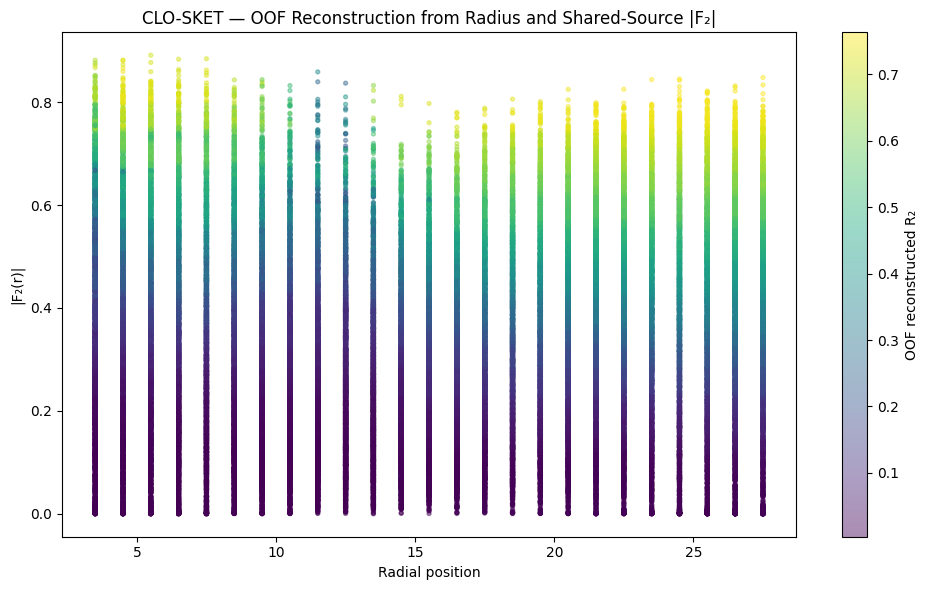

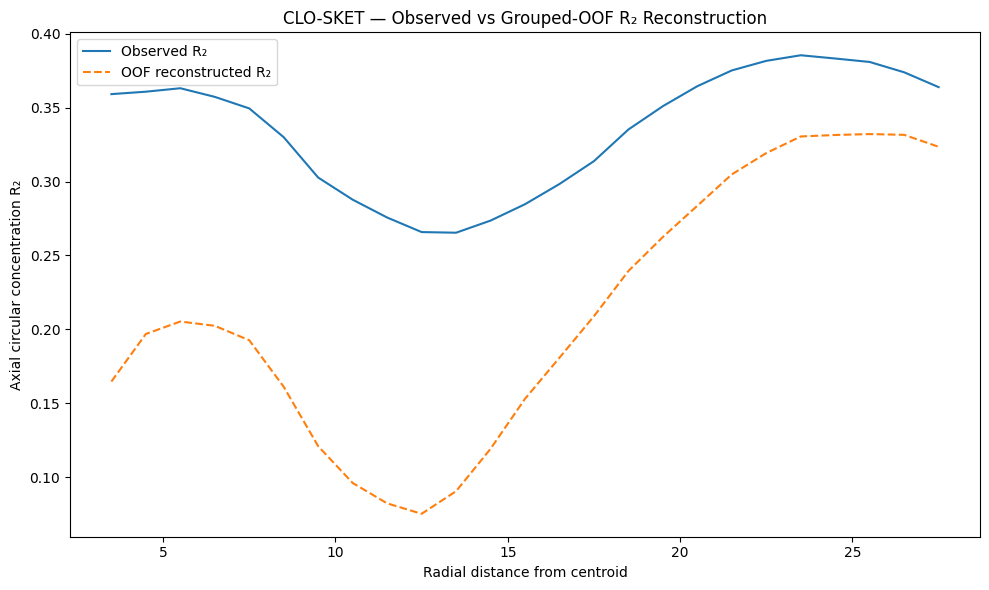


OUTPUT OBJECTS
--------------------------------------------------------------------------------

p_theta
    → observed p(theta | r)
      shape = (sketch, radial, angle)

C2_obs
    → observed axial cosine moment

S2_obs
    → observed axial sine moment

R2_obs
    → observed axial circular resultant

mu2_obs_deg
    → observed preferred axial orientation

C2_hat_field
    → grouped-OOF reconstructed cosine moment

S2_hat_field
    → grouped-OOF reconstructed sine moment

R2_hat_field
    → grouped-OOF reconstructed axial resultant

mu2_hat_field_deg
    → grouped-OOF reconstructed axial orientation

mu2_hat_reliability_field
    → R₂-based continuous orientation reliability weight

mu2_hat_defined_field
    → numerical nonzero-resultant orientation mask

shared_source_audit
    → Fourier identity and external |F₂| normalization audit

fold_scores
    → grouped cross-validation scores

null_comparison
    → fold-local global vs radius-only vs
      radius + |F₂| OOF reconstruction

i

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance


print("=" * 80)
print("🧪 CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY")
print("AUDITED — GROUPED-OOF RECONSTRUCTION OF THE FIRST AXIAL MOMENT")
print("=" * 80)


# ============================================================================
# 1. INPUT VERIFICATION
# ============================================================================

required_objects = [
    "conditional_angular",
    "F2_mag",
    "radial_centers"
]

missing = [x for x in required_objects if x not in globals()]

if missing:
    raise NameError(
        "Required objects missing: " + ", ".join(missing)
    )

A = np.asarray(conditional_angular, dtype=float)
F2_all = np.asarray(F2_mag, dtype=float)
r_all = np.asarray(radial_centers, dtype=float)

if A.ndim != 3:
    raise ValueError(
        f"conditional_angular must be 3D, got {A.shape}"
    )

if F2_all.ndim != 2:
    raise ValueError(
        f"F2_mag must be 2D, got {F2_all.shape}"
    )

if A.shape[:2] != F2_all.shape:
    raise ValueError(
        f"Angular field {A.shape[:2]} does not match F2_mag {F2_all.shape}"
    )

if A.shape[1] != len(r_all):
    raise ValueError(
        f"Radial coordinate length {len(r_all)} does not match "
        f"radial dimension {A.shape[1]}"
    )

n_sketches, n_radial, n_angles = A.shape

print("\nINPUT VERIFICATION")
print("-" * 80)
print(f"conditional_angular : {A.shape}")
print(f"F2_mag              : {F2_all.shape}")
print(f"radial_centers      : {r_all.shape}")
print(f"Population          : {n_sketches}")
print(f"Radial shells       : {n_radial}")
print(f"Angular bins        : {n_angles}")
print("🟢 INPUT OBJECTS VERIFIED")


# ============================================================================
# 2. RECOVER PRIMARY F₂ ZONE
# ============================================================================

if "zone_r" in globals():
    zone_r_existing = np.asarray(zone_r, dtype=float)

    zone_mask = np.isin(
        np.round(r_all, 10),
        np.round(zone_r_existing, 10)
    )

elif "primary_zone_mask" in globals():
    zone_mask = np.asarray(primary_zone_mask, dtype=bool)

else:
    # Canonical established zone from Cells 20–21
    zone_mask = (r_all >= 3.5) & (r_all <= 27.5)

if zone_mask.sum() == 0:
    raise ValueError("No radial shells found inside primary F₂ zone.")

zone_idx = np.where(zone_mask)[0]

r = r_all[zone_idx]
F2 = F2_all[:, zone_idx]
A_zone = A[:, zone_idx, :]

n_zone = len(zone_idx)

print("\nPRIMARY F₂ RADIAL ZONE")
print("-" * 80)
print(f"Primary zone : {r.min():.4f} → {r.max():.4f}")
print(f"Radial shells: {n_zone}")
print("🟢 ESTABLISHED ZONE RECOVERED")


# ============================================================================
# 3. CONSTRUCT OBSERVED p(theta | r)
# ============================================================================

row_mass = np.sum(A_zone, axis=2, keepdims=True)

valid = (
    np.isfinite(A_zone).all(axis=2)
    & np.isfinite(F2).all(axis=1)[:, None]
    & (row_mass[..., 0] > 0)
)

p_theta = np.divide(
    A_zone,
    row_mass,
    out=np.zeros_like(A_zone),
    where=row_mass > 0
)

normalization_error = np.abs(
    p_theta.sum(axis=2) - 1.0
)

print("\nOBSERVED ANGULAR PROBABILITY DISTRIBUTION")
print("-" * 80)
print(
    f"Valid sketch × radial shells : "
    f"{valid.sum()}/{valid.size}"
)
print(
    f"Mean angular normalization    : "
    f"{p_theta.sum(axis=2)[valid].mean():.6f}"
)

if normalization_error[valid].max() > 1e-8:
    raise ValueError(
        "Angular probability normalization failed."
    )

print("🟢 p(theta | r) CONSTRUCTED")


# ============================================================================
# 4. OBSERVED AXIAL CIRCULAR MOMENTS
# ============================================================================
#
# For axial orientation:
#
#       β = 2θ
#
# Therefore:
#
#       C₂ = E[cos(2θ)]
#       S₂ = E[sin(2θ)]
#
#       R₂ = sqrt(C₂² + S₂²)
#
#       μ₂ = 1/2 atan2(S₂, C₂)
#
# These are OBSERVED quantities, not learned quantities.
# ============================================================================

theta = np.linspace(
    0.0,
    2.0 * np.pi,
    n_angles,
    endpoint=False
)

cos2 = np.cos(2.0 * theta)
sin2 = np.sin(2.0 * theta)

C2_obs = np.sum(
    p_theta * cos2[None, None, :],
    axis=2
)

S2_obs = np.sum(
    p_theta * sin2[None, None, :],
    axis=2
)

R2_obs = np.sqrt(
    C2_obs**2 + S2_obs**2
)

mu2_obs_rad = (
    0.5 * np.arctan2(S2_obs, C2_obs)
) % np.pi

mu2_obs_deg = np.degrees(mu2_obs_rad)

print("\nOBSERVED AXIAL CIRCULAR MOMENTS")
print("-" * 80)
print(f"Mean observed R₂   : {np.nanmean(R2_obs):.6f}")
print(f"Median observed R₂ : {np.nanmedian(R2_obs):.6f}")
print("🟢 OBSERVED C₂ / S₂ / R₂ / μ₂ RECOVERED")


# ============================================================================
# 5. SHARED-SOURCE FOURIER IDENTITY AUDIT
# ============================================================================
#
# p(theta | r), C₂, S₂ and the second angular Fourier coefficient are derived
# from the same angular field.  With NumPy's FFT convention,
#
#   FFT(p)[2] = sum p(theta) exp(-i 2 theta) = C₂ - i S₂.
#
# This audit establishes the algebraic coupling before any regression is fit.
# It prevents the OOF model from being interpreted as evidence that an
# independent radial variable predicts angular organization.
# ============================================================================

P_fft = np.fft.fft(p_theta, axis=2)
F2_normalized_complex = P_fft[:, :, 2]

fourier_error_minus = np.abs(
    F2_normalized_complex - (C2_obs - 1j * S2_obs)
)
fourier_error_plus = np.abs(
    F2_normalized_complex - (C2_obs + 1j * S2_obs)
)

if np.nanmean(fourier_error_minus[valid]) <= np.nanmean(fourier_error_plus[valid]):
    fft_sign_convention = "FFT(p)[2] = C2 - i*S2"
    fourier_identity_error = fourier_error_minus
else:
    fft_sign_convention = "FFT(p)[2] = C2 + i*S2"
    fourier_identity_error = fourier_error_plus

R2_from_fft = np.abs(F2_normalized_complex)
R2_identity_error = np.abs(R2_from_fft - R2_obs)

# |F2| may differ from |FFT(p)[2]| by the shell mass used to normalize A.
# Test both the raw and mass-normalized external predictor explicitly.
row_mass_2d = row_mass[..., 0]
F2_external_normalized = np.divide(
    F2,
    row_mass_2d,
    out=np.full_like(F2, np.nan),
    where=row_mass_2d > 0
)

external_raw_rmse = np.sqrt(np.nanmean((F2 - R2_obs) ** 2))
external_normalized_rmse = np.sqrt(
    np.nanmean((F2_external_normalized - R2_obs) ** 2)
)

shared_source_audit = pd.DataFrame({
    "audit": [
        "complex_F2_identity",
        "R2_equals_abs_normalized_F2",
        "external_F2_mag_raw_vs_R2",
        "external_F2_mag_mass_normalized_vs_R2"
    ],
    "RMSE": [
        np.sqrt(np.nanmean(fourier_identity_error[valid] ** 2)),
        np.sqrt(np.nanmean(R2_identity_error[valid] ** 2)),
        external_raw_rmse,
        external_normalized_rmse
    ],
    "max_abs_error": [
        np.nanmax(fourier_identity_error[valid]),
        np.nanmax(R2_identity_error[valid]),
        np.nanmax(np.abs(F2 - R2_obs)),
        np.nanmax(np.abs(F2_external_normalized - R2_obs))
    ]
})

print("\nSHARED-SOURCE FOURIER IDENTITY AUDIT")
print("-" * 80)
print(f"Detected FFT convention : {fft_sign_convention}")
print(shared_source_audit.to_string(index=False))

if shared_source_audit.loc[0, "max_abs_error"] > 1e-10:
    raise ValueError(
        "Observed moments do not match the second Fourier coefficient "
        "under either tested sign convention. Check angular-bin convention."
    )

print("🟢 ALGEBRAIC SHARED-SOURCE COUPLING VERIFIED")


# ============================================================================
# 6. BUILD RECONSTRUCTION DATASET
# ============================================================================
#
# Each training observation corresponds to:
#
#       one sketch
#       one radial shell
#
# Predictors:
#
#       r
#       |F₂(r)|
#
# Targets:
#
#       C₂
#       S₂
#
# Sketch identity is retained ONLY for grouped CV.
# It is NOT supplied to the model.
# ============================================================================

R_grid = np.broadcast_to(
    r[None, :],
    F2.shape
)

sketch_ids = np.repeat(
    np.arange(n_sketches),
    n_zone
)

X_r = np.tile(r, n_sketches)
X_f2 = F2.ravel()

y_C2 = C2_obs.ravel()
y_S2 = S2_obs.ravel()

valid_flat = (
    np.isfinite(X_r)
    & np.isfinite(X_f2)
    & np.isfinite(y_C2)
    & np.isfinite(y_S2)
)

X_r = X_r[valid_flat]
X_f2 = X_f2[valid_flat]
y_C2 = y_C2[valid_flat]
y_S2 = y_S2[valid_flat]
groups = sketch_ids[valid_flat]

X_full = np.column_stack([
    X_r,
    X_f2
])

X_radius = X_r.reshape(-1, 1)

print("\nBUILDING OOF RECONSTRUCTION DATASET")
print("-" * 80)
print(f"Learning samples : {len(y_C2)}")
print("Predictors:")
print("    r")
print("    |F₂(r)|")
print("Targets:")
print("    C₂ = E[cos(2θ)]")
print("    S₂ = E[sin(2θ)]")
print("🟢 RECONSTRUCTION DATASET CONSTRUCTED")


# ============================================================================
# 7. RECONSTRUCTION MODEL
# ============================================================================
#
# HistGradientBoosting provides a nonlinear empirical reconstruction audit.
#
# The model learns nonlinear relationships while remaining much simpler and
# more auditable than a neural latent representation.
#
# TWO separate regressors are fitted:
#
#       C₂_hat = f_C(r, |F₂|)
#
#       S₂_hat = f_S(r, |F₂|)
#
# No category labels are used.
# ============================================================================

def make_model():
    return HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )


# ============================================================================
# 8. GROUPED CROSS-VALIDATION
# ============================================================================
#
# CRITICAL:
#
# All radial observations from a sketch remain in one fold.
#
# Therefore the model is evaluated on completely unseen sketches.
# ============================================================================

gkf = GroupKFold(n_splits=5)

C2_oof = np.full(len(y_C2), np.nan)
S2_oof = np.full(len(y_S2), np.nan)
C2_radius_oof = np.full(len(y_C2), np.nan)
S2_radius_oof = np.full(len(y_S2), np.nan)
C2_global_oof = np.full(len(y_C2), np.nan)
S2_global_oof = np.full(len(y_S2), np.nan)

fold_scores = []
importance_rows = []

print("\nGROUPED CROSS-VALIDATION")
print("-" * 80)

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_full, y_C2, groups=groups),
    start=1
):

    # ---------------------------------------------------------
    # Full model: r + |F₂|
    # ---------------------------------------------------------

    model_C = make_model()
    model_S = make_model()

    model_C.fit(
        X_full[train_idx],
        y_C2[train_idx]
    )

    model_S.fit(
        X_full[train_idx],
        y_S2[train_idx]
    )

    pred_C = model_C.predict(
        X_full[test_idx]
    )

    pred_S = model_S.predict(
        X_full[test_idx]
    )

    C2_oof[test_idx] = pred_C
    S2_oof[test_idx] = pred_S

    # Radius-only comparators use the identical train/test split.
    radius_C = make_model()
    radius_S = make_model()
    radius_C.fit(X_radius[train_idx], y_C2[train_idx])
    radius_S.fit(X_radius[train_idx], y_S2[train_idx])
    pred_C_radius = radius_C.predict(X_radius[test_idx])
    pred_S_radius = radius_S.predict(X_radius[test_idx])
    C2_radius_oof[test_idx] = pred_C_radius
    S2_radius_oof[test_idx] = pred_S_radius

    # Fold-local global means avoid fitting the baseline on held-out targets.
    pred_C_global = np.full(len(test_idx), np.mean(y_C2[train_idx]))
    pred_S_global = np.full(len(test_idx), np.mean(y_S2[train_idx]))
    C2_global_oof[test_idx] = pred_C_global
    S2_global_oof[test_idx] = pred_S_global

    rmse_C = np.sqrt(
        mean_squared_error(
            y_C2[test_idx],
            pred_C
        )
    )

    rmse_S = np.sqrt(
        mean_squared_error(
            y_S2[test_idx],
            pred_S
        )
    )

    rmse_C_radius = np.sqrt(mean_squared_error(y_C2[test_idx], pred_C_radius))
    rmse_S_radius = np.sqrt(mean_squared_error(y_S2[test_idx], pred_S_radius))
    rmse_C_global = np.sqrt(mean_squared_error(y_C2[test_idx], pred_C_global))
    rmse_S_global = np.sqrt(mean_squared_error(y_S2[test_idx], pred_S_global))

    # Held-out-fold permutation importance.  Values are increases in RMSE.
    perm_C_fold = permutation_importance(
        model_C, X_full[test_idx], y_C2[test_idx], n_repeats=5,
        random_state=42 + fold, scoring="neg_root_mean_squared_error"
    )
    perm_S_fold = permutation_importance(
        model_S, X_full[test_idx], y_S2[test_idx], n_repeats=5,
        random_state=142 + fold, scoring="neg_root_mean_squared_error"
    )

    for predictor_index, predictor_name in enumerate(
        ["radial_position", "F2_magnitude"]
    ):
        importance_rows.append({
            "fold": fold,
            "predictor": predictor_name,
            "C2_importance": perm_C_fold.importances_mean[predictor_index],
            "S2_importance": perm_S_fold.importances_mean[predictor_index]
        })

    fold_scores.append({
        "fold": fold,
        "RMSE_C2": rmse_C,
        "RMSE_S2": rmse_S,
        "RMSE_C2_radius": rmse_C_radius,
        "RMSE_S2_radius": rmse_S_radius,
        "RMSE_C2_global": rmse_C_global,
        "RMSE_S2_global": rmse_S_global,
        "delta_RMSE_C2_radius_minus_full": rmse_C_radius - rmse_C,
        "delta_RMSE_S2_radius_minus_full": rmse_S_radius - rmse_S,
        "n_test_sketches": len(
            np.unique(groups[test_idx])
        )
    })

fold_scores = pd.DataFrame(fold_scores)

print(
    f"Mean grouped CV RMSE C₂ : "
    f"{fold_scores.RMSE_C2.mean():.6f}"
)

print(
    f"Mean grouped CV RMSE S₂ : "
    f"{fold_scores.RMSE_S2.mean():.6f}"
)

print("🟢 GROUPED OOF RECONSTRUCTION COMPLETE")


# ============================================================================
# 9. INCREMENTAL RECONSTRUCTION COMPARISON
# ============================================================================
#
# This is scientifically important.
#
# We compare:
#
#       Model 0:
#           global mean
#
#       Model 1:
#           radius only
#
#       Model 2:
#           radius + |F₂|
#
# The key question is:
#
#       How much does shared-source |F₂| improve reconstruction beyond radius?
# ============================================================================

# All comparators below are strictly OOF and use identical grouped folds.
C2_global_rmse = np.sqrt(
    mean_squared_error(y_C2, C2_global_oof)
)

S2_global_rmse = np.sqrt(
    mean_squared_error(y_S2, S2_global_oof)
)


# Radius-only
C2_radius_rmse = np.sqrt(mean_squared_error(y_C2, C2_radius_oof))

S2_radius_rmse = np.sqrt(mean_squared_error(y_S2, S2_radius_oof))


# Radius + F₂
C2_full_rmse = np.sqrt(
    mean_squared_error(
        y_C2,
        C2_oof
    )
)

S2_full_rmse = np.sqrt(
    mean_squared_error(
        y_S2,
        S2_oof
    )
)


null_comparison = pd.DataFrame({
    "model": [
        "Fold-local global baseline",
        "Radius-only OOF model",
        "Radius + |F₂| OOF reconstruction"
    ],
    "RMSE_C2": [
        C2_global_rmse,
        C2_radius_rmse,
        C2_full_rmse
    ],
    "RMSE_S2": [
        S2_global_rmse,
        S2_radius_rmse,
        S2_full_rmse
    ]
})

print("\nNULL-MODEL COMPARISON")
print("-" * 80)
print(
    null_comparison.to_string(
        index=False
    )
)

incremental_reconstruction = pd.DataFrame({
    "target": ["C2", "S2"],
    "radius_RMSE": [C2_radius_rmse, S2_radius_rmse],
    "radius_plus_F2_RMSE": [C2_full_rmse, S2_full_rmse],
    "absolute_RMSE_reduction": [
        C2_radius_rmse - C2_full_rmse,
        S2_radius_rmse - S2_full_rmse
    ],
    "relative_RMSE_reduction_percent": [
        100.0 * (C2_radius_rmse - C2_full_rmse) / C2_radius_rmse,
        100.0 * (S2_radius_rmse - S2_full_rmse) / S2_radius_rmse
    ]
})

print("\nINCREMENTAL RECONSTRUCTION FROM SHARED-SOURCE |F₂|")
print("-" * 80)
print(incremental_reconstruction.to_string(index=False))


# ============================================================================
# 10. RECOVER OOF MOMENT RECONSTRUCTIONS
# ============================================================================
#
# From predicted C₂ and S₂:
#
#       R₂_hat = sqrt(C₂_hat² + S₂_hat²)
#
#       μ₂_hat = 1/2 atan2(S₂_hat, C₂_hat)
#
# The regressors are unconstrained.  Bound violations are audited before any
# clipping.  The exported field retains the raw OOF resultant so the audit is
# transparent; a bounded copy is supplied separately for visualization only.
# ============================================================================

R2_hat_flat = np.sqrt(
    C2_oof**2 + S2_oof**2
)

R2_hat_bound_violation = R2_hat_flat > (1.0 + 1e-12)
R2_hat_bounded_flat = np.clip(R2_hat_flat, 0.0, 1.0)

mu2_hat_flat = (
    0.5 * np.arctan2(
        S2_oof,
        C2_oof
    )
) % np.pi

mu2_hat_deg_flat = np.degrees(
    mu2_hat_flat
)

# Orientation has no meaningful interpretation when the reconstructed
# resultant approaches zero.  No arbitrary threshold is imposed here;
# reliability weights and a zero-resultant mask are exported for Cell 23.
mu2_hat_reliability_weight = R2_hat_flat.copy()
mu2_hat_defined = R2_hat_flat > np.finfo(float).eps

# Population axial orientation is obtained from aggregated doubled-angle
# components, never by an arithmetic average of angles.
population_C2_hat_global = np.nanmean(C2_oof)
population_S2_hat_global = np.nanmean(S2_oof)
population_R2_hat_global = np.hypot(
    population_C2_hat_global, population_S2_hat_global
)
population_mu2_hat_deg = np.degrees(
    (0.5 * np.arctan2(population_S2_hat_global, population_C2_hat_global))
    % np.pi
)

print("\nOOF RECONSTRUCTED CIRCULAR PARAMETERS")
print("-" * 80)
print(
    f"Mean OOF R₂ reconstruction   : "
    f"{np.nanmean(R2_hat_flat):.6f}"
)

print(
    f"Median OOF R₂ reconstruction : "
    f"{np.nanmedian(R2_hat_flat):.6f}"
)

print(
    f"Population OOF μ₂ (from mean C₂,S₂) : "
    f"{population_mu2_hat_deg:.4f}°"
)
print(
    f"R₂ physical-bound violations : "
    f"{R2_hat_bound_violation.sum()}/{R2_hat_bound_violation.size}"
)

print("🟢 OOF MOMENT RECONSTRUCTIONS RECOVERED")


# ============================================================================
# 11. RECOVER SKETCH × RADIAL FIELDS
# ============================================================================

C2_hat_field = np.full(
    (n_sketches, n_zone),
    np.nan
)

S2_hat_field = np.full(
    (n_sketches, n_zone),
    np.nan
)

R2_hat_field = np.full(
    (n_sketches, n_zone),
    np.nan
)

mu2_hat_field_deg = np.full(
    (n_sketches, n_zone),
    np.nan
)

mu2_hat_reliability_field = np.full((n_sketches, n_zone), np.nan)
mu2_hat_defined_field = np.zeros((n_sketches, n_zone), dtype=bool)

valid_positions = np.flatnonzero(valid_flat)

for flat_position, original_position in enumerate(
    valid_positions
):

    i = original_position // n_zone
    j = original_position % n_zone

    C2_hat_field[i, j] = C2_oof[flat_position]
    S2_hat_field[i, j] = S2_oof[flat_position]

    R2_hat_field[i, j] = R2_hat_flat[flat_position]

    mu2_hat_field_deg[i, j] = (
        mu2_hat_deg_flat[flat_position]
    )

    mu2_hat_reliability_field[i, j] = (
        mu2_hat_reliability_weight[flat_position]
    )
    mu2_hat_defined_field[i, j] = mu2_hat_defined[flat_position]


# ============================================================================
# 12. OBSERVED ↔ OOF RECONSTRUCTION QUALITY
# ============================================================================

valid_pred = (
    np.isfinite(R2_obs.ravel()[valid_positions])
    & np.isfinite(R2_hat_flat)
)

R2_prediction_rmse = np.sqrt(
    mean_squared_error(
        R2_obs.ravel()[valid_positions][valid_pred],
        R2_hat_flat[valid_pred]
    )
)

R2_prediction_corr = np.corrcoef(
    R2_obs.ravel()[valid_positions][valid_pred],
    R2_hat_flat[valid_pred]
)[0, 1]

print("\nOBSERVED ↔ OOF MOMENT RECONSTRUCTION")
print("-" * 80)
print(
    f"R₂ prediction RMSE : "
    f"{R2_prediction_rmse:.6f}"
)

print(
    f"R₂ prediction Pearson r : "
    f"{R2_prediction_corr:.6f}"
)

print(
    f"Observed mean R₂ : "
    f"{np.nanmean(R2_obs):.6f}"
)

print(
    f"OOF reconstructed mean R₂ : "
    f"{np.nanmean(R2_hat_field):.6f}"
)


# ============================================================================
# 13. HELD-OUT-FOLD PERMUTATION IMPORTANCE
# ============================================================================
#
# Importance is evaluated only on each held-out fold and then summarized.
# It remains descriptive and must not be interpreted causally.
# ============================================================================

importance_by_fold = pd.DataFrame(importance_rows)
importance = (
    importance_by_fold
    .groupby("predictor", as_index=False)
    .agg(
        C2_importance=("C2_importance", "mean"),
        C2_importance_sd=("C2_importance", "std"),
        S2_importance=("S2_importance", "mean"),
        S2_importance_sd=("S2_importance", "std")
    )
)

print("\nHELD-OUT-FOLD PERMUTATION IMPORTANCE")
print("-" * 80)
print(
    importance.to_string(
        index=False
    )
)


# ============================================================================
# 14. POPULATION RADIAL PROFILE
# ============================================================================

population_f2 = np.nanmean(
    F2,
    axis=0
)

population_R2_obs = np.nanmean(
    R2_obs,
    axis=0
)

population_R2_hat = np.nanmean(
    R2_hat_field,
    axis=0
)

# Aggregate components directly.  This naturally weights orientation by the
# shell-level resultant and avoids averaging undefined/weak angles equally.
population_C2_obs = np.nanmean(C2_obs, axis=0)
population_S2_obs = np.nanmean(S2_obs, axis=0)
population_mu2_obs_deg = np.degrees(
    (0.5 * np.arctan2(population_S2_obs, population_C2_obs)) % np.pi
)

population_C2_hat = np.nanmean(C2_hat_field, axis=0)
population_S2_hat = np.nanmean(S2_hat_field, axis=0)
population_mu2_hat_field_deg = np.degrees(
    (0.5 * np.arctan2(population_S2_hat, population_C2_hat)) % np.pi
)


# ============================================================================
# 15. VISUALIZATION
# ============================================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    X_r,
    X_f2,
    c=R2_hat_bounded_flat,
    s=8,
    alpha=0.45
)

ax.set_xlabel(
    "Radial position"
)

ax.set_ylabel(
    "|F₂(r)|"
)

ax.set_title(
    "CLO-SKET — OOF Reconstruction from Radius and Shared-Source |F₂|"
)

cbar = plt.colorbar(
    ax.collections[0],
    ax=ax
)

cbar.set_label(
    "OOF reconstructed R₂"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    r,
    population_R2_obs,
    label="Observed R₂"
)

ax.plot(
    r,
    population_R2_hat,
    linestyle="--",
    label="OOF reconstructed R₂"
)

ax.set_xlabel(
    "Radial distance from centroid"
)

ax.set_ylabel(
    "Axial circular concentration R₂"
)

ax.set_title(
    "CLO-SKET — Observed vs Grouped-OOF R₂ Reconstruction"
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================================
# 16. OUTPUT OBJECTS
# ============================================================================

print("\nOUTPUT OBJECTS")
print("-" * 80)

print("""
p_theta
    → observed p(theta | r)
      shape = (sketch, radial, angle)

C2_obs
    → observed axial cosine moment

S2_obs
    → observed axial sine moment

R2_obs
    → observed axial circular resultant

mu2_obs_deg
    → observed preferred axial orientation

C2_hat_field
    → grouped-OOF reconstructed cosine moment

S2_hat_field
    → grouped-OOF reconstructed sine moment

R2_hat_field
    → grouped-OOF reconstructed axial resultant

mu2_hat_field_deg
    → grouped-OOF reconstructed axial orientation

mu2_hat_reliability_field
    → R₂-based continuous orientation reliability weight

mu2_hat_defined_field
    → numerical nonzero-resultant orientation mask

shared_source_audit
    → Fourier identity and external |F₂| normalization audit

fold_scores
    → grouped cross-validation scores

null_comparison
    → fold-local global vs radius-only vs
      radius + |F₂| OOF reconstruction

incremental_reconstruction
    → absolute and relative OOF RMSE reductions

importance
    → held-out-fold descriptive permutation importance

population_f2
    → population canonical F₂ radial profile

population_R2_obs
    → observed population axial concentration

population_R2_hat
    → OOF reconstructed population axial resultant
""")


# ============================================================================
# 17. SCIENTIFIC AUDIT
# ============================================================================

print("\n" + "=" * 80)
print("🟢 CELL 22B — GROUPED-OOF AXIAL-MOMENT RECONSTRUCTION AUDIT COMPLETE")
print("=" * 80)

print("""
RELATION TO CELL 22A
--------------------

Cell 22A tested:

    K = 1 axial von Mises
    K = 2 axial von Mises mixture

The two-component model was NOT supported by BIC:

    Mixture BIC wins at peak shells : 0 / 2300
    Mixture BIC wins across radial shells : 0 / 25

This supports retaining the first axial moment as the complexity-adjusted
summary examined here.  Cell 22B itself is moment regression; it is not a
von Mises density model and does not refit the Cell 22A mixture comparison.

SHARED-SOURCE DEPENDENCE
------------------------

The predictor |F₂| and targets C₂, S₂ are derived from the same angular field.
Under the detected FFT convention:

    FFT(p)[2] = C₂ - i S₂

and therefore:

    R₂ = |FFT(p)[2]|.

Consequently, the grouped-OOF model estimates an empirical reconstruction:

    (r, |F₂|) → (C₂, S₂),

where predictor and targets have shared mathematical provenance.  This is a
consistency/compression audit, not evidence that an independent radial feature
predicts angular organization.

GROUPED OOF CONTROL
-------------------

All radial observations from a sketch remain within one fold.  Full,
radius-only and fold-local global comparators use identical splits, so every
reported comparison is evaluated on unseen sketches.

INCREMENTAL RECONSTRUCTION
--------------------------

The radius-only versus radius + |F₂| comparison quantifies incremental OOF
reconstruction accuracy.  Because |F₂| is shared-source, improvement must not
be described as independent information about angular organization.  C₂ and
S₂ improvements are reported separately; a negligible S₂ reduction must not
be pooled into a broad positive claim.

RESULTANT SHRINKAGE
-------------------

OOF component regression can shrink vector magnitude toward the population
mean.  Observed and reconstructed mean/median R₂, together with R₂ RMSE, are
therefore retained explicitly.  High correlation alone is not calibration.

ORIENTATION HANDLING
--------------------

Axial orientation is derived with the doubled-angle formula.  Population
orientation is computed from aggregated C₂ and S₂, never from an arithmetic
mean of μ₂.  Reconstructed orientation is numerically undefined at R₂ = 0 and
scientifically unstable as R₂ approaches zero.  The exported R₂ reliability
weights must accompany any downstream use; Cell 23 may define a threshold only
if it is justified and declared before outcome analysis.

FEATURE STATUS FOR CELL 23
--------------------------

The provenance classes are:

    |F₂| descriptors                 shared-source Fourier family
    observed C₂, S₂, R₂, μ₂         direct same-field derivatives
    OOF C₂_hat, S₂_hat, R₂_hat      reconstruction-audit derivatives
    OOF μ₂_hat                       conditional orientation derivative

The OOF outputs are not a genuinely independent feature family and must not be
counted as independent evidence or automatically admitted to a final feature
vector.  Cell 23 should audit them for redundancy and calibration.

NO CATEGORY INFORMATION
-----------------------

No category labels were used.

No classifier was trained.

No semantic labels were assigned.

No category-specific optimization was performed.

VALID SCIENTIFIC CHAIN
----------------------

    raw sketch
        ↓
    radial-angular representation
        ↓
    observed p(theta | r)
        ↓
    shared second harmonic
        ├── |F₂|
        └── observed C₂, S₂, R₂, μ₂
        ↓
    grouped-OOF reconstruction audit
        (r, |F₂|) → (C₂_hat, S₂_hat)
        ↓
    calibration, shrinkage and redundancy evidence

NEXT
----

CELL 23

    FEATURE-FAMILY AUDIT

We will now quantify whether:

    F₂ radial descriptors
    α₂ descriptors
    observed circular descriptors
    OOF reconstructed circular descriptors

are algebraically redundant, empirically overlapping, or retain distinct
nonlinear information after provenance is respected.

Only after redundancy is quantified should the
controlled category discrimination experiment begin.
""")


## 7. Redundancy audit and exact 28-D assembly

The canonical order is fixed as `9 + 7 + 3 + 4 + 5 = 28`. The final lock cell must report an exact concatenation match and maximum difference zero.


CLO-SKET — CELL 23
PROVENANCE-AWARE FEATURE REDUNDANCY AUDIT

INPUT VERIFICATION
--------------------------------------------------------------------------------
Population             : 2300
Primary radial shells  : 25
Primary radial zone    : 3.5000 -> 27.5000
Cell 21 descriptors    : not exported; reconstructed below
Cell 21 angle field    : reconstructed from FFT(p)[2] phase (degrees)
Cell 22B estimator     : two HistGradientBoosting regressors
Cell 22B targets       : C2 and S2
Direct angle regression: NO
INPUTS VERIFIED

ALGEBRAIC / SHARED-SOURCE IDENTITIES
--------------------------------------------------------------------------------
Detected FFT convention: FFT(p)[2] = C2 - i*S2
                                                   audit  max_abs_error    tolerance  verified
              FFT(p)[2] = observed complex second moment   7.108896e-16 1.000000e-10      True
                      R2_obs = sqrt(C2_obs^2 + S2_obs^2)   0.000000e+00 1.000000e-10      True
     exported Cel

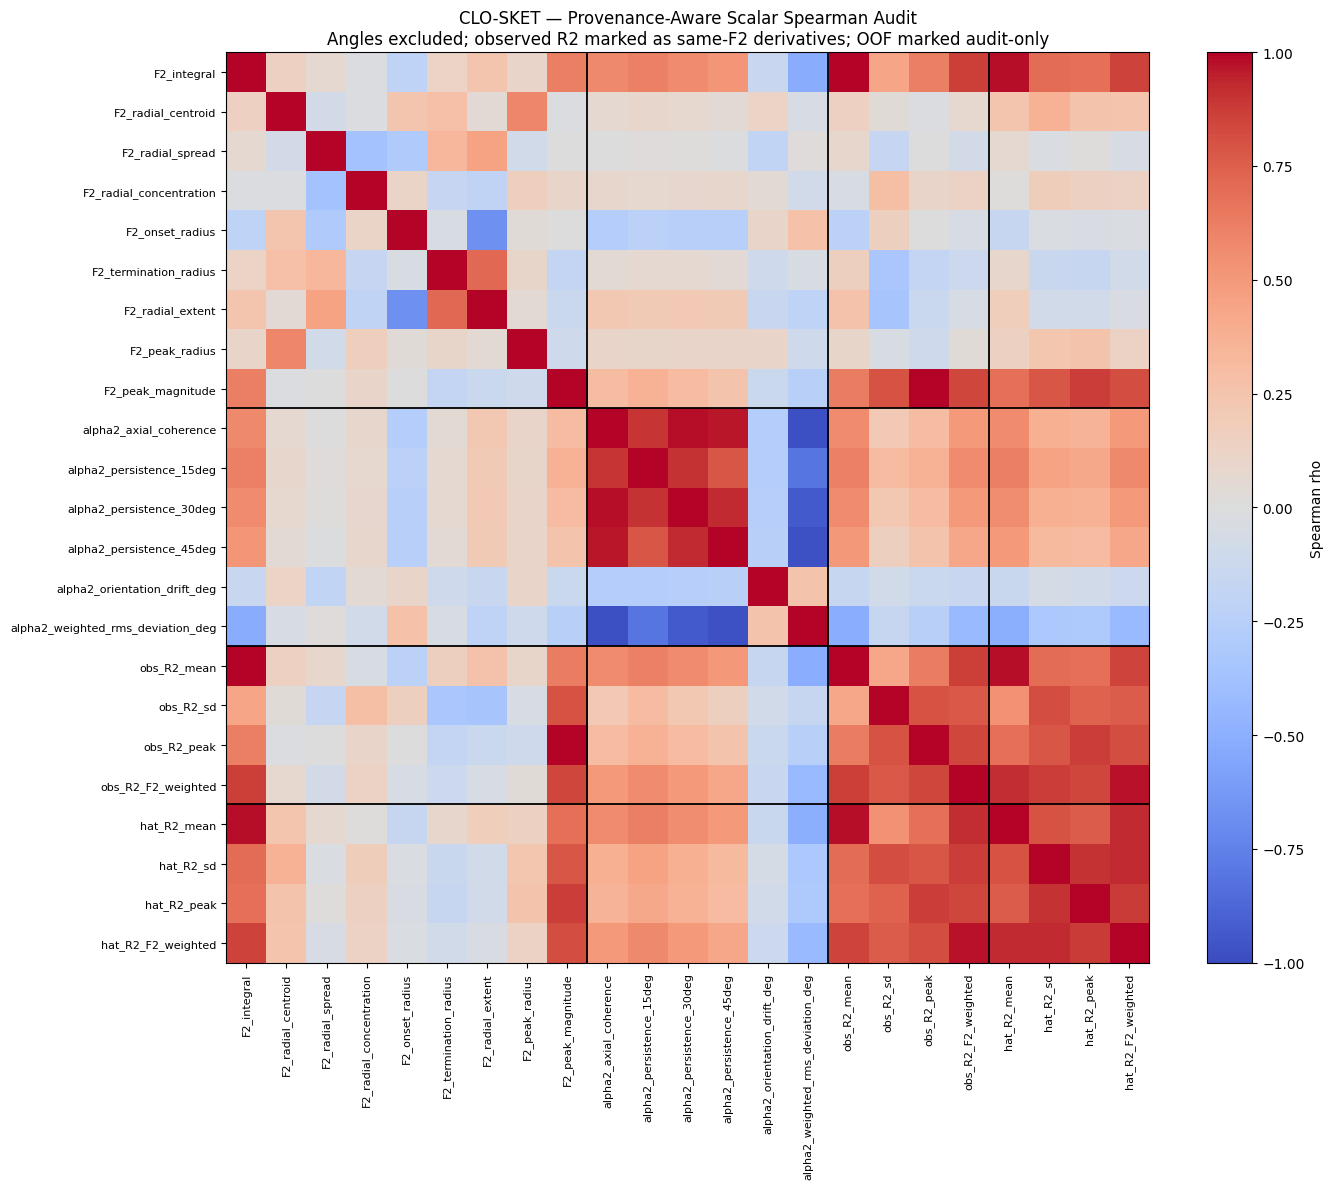


CELL 23 — PROVENANCE-AWARE AUDIT COMPLETE

SCIENTIFIC CONCLUSION
---------------------

1. |F2|, observed R2, and sqrt(C2^2 + S2^2) are the same quantity.
2. alpha2 and observed mu2 are phase representations of the same F2 harmonic.
3. Cell 22B used grouped-OOF component regression:

       (r, |F2|) -> (C2_hat, S2_hat)

   using two HistGradientBoosting regressors. It is nonlinear component-wise
   regression, not linear regression and not direct circular-angle regression.
4. OOF reconstructed quantities are lossy audit derivatives and are not an
   independent feature family.
5. Ordinary Spearman correlation was applied only to scalar quantities.
   Axial directions were assessed with modulo-180 axial differences and
   R2-based reliability.
6. Pairwise low correlation is not evidence of statistical independence or
   complementary information.
7. No category labels were used. No feature was selected or removed.

CELL 24 GATE
------------

Before category discrimination, define the 

In [ ]:
# =============================================================================
# CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# CELL 23 — PROVENANCE-AWARE FEATURE-FAMILY REDUNDANCY AUDIT (SELF-CONTAINED V3)
# =============================================================================
"""
Purpose
-------
Replacement for the original Cell 23 feature-family correlation/redundancy
audit. Audit algebraic dependence, empirical scalar overlap, and axial-angle
agreement among the descriptors produced by Cells 20–22B.

This cell does not use category labels, select features, or train a
classifier. Cell 22B is treated correctly as grouped-OOF regression of the
Cartesian axial-moment components C2 and S2. It is not direct circular
regression.

Scientific ordering
-------------------
1. Audit exact shared-source identities before computing correlations.
2. Keep axial orientation angles out of ordinary correlation matrices.
3. Treat OOF reconstructions as audit-only derivatives, not an independent
   source of evidence.
4. Do not interpret low pairwise correlation as proof of independence or
   complementary information.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 80)
print("CLO-SKET — CELL 23")
print("PROVENANCE-AWARE FEATURE REDUNDANCY AUDIT")
print("=" * 80)


# =============================================================================
# 1. REQUIRED INPUTS
# =============================================================================

required = [
    "conditional_angular",
    "F2_mag",
    "radial_centers",
    "C2_obs",
    "S2_obs",
    "R2_obs",
    "mu2_obs_deg",
    "C2_hat_field",
    "S2_hat_field",
    "R2_hat_field",
    "mu2_hat_field_deg",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run Cells 20, 21, and 22B before Cell 23. Missing: "
        + ", ".join(missing)
    )

# Cell 21 exists in two notebook naming conventions.  Recover its descriptor
# table and orientation field without requiring the later aliases.
if "alpha2_descriptors" in globals():
    alpha2_descriptor_object = globals()["alpha2_descriptors"]
    alpha2_descriptor_source = "alpha2_descriptors"
elif "X_alpha2" in globals():
    alpha2_descriptor_object = globals()["X_alpha2"]
    alpha2_descriptor_source = "X_alpha2"
else:
    alpha2_descriptor_object = None
    alpha2_descriptor_source = "not exported; reconstructed below"

if "alpha2_radial" in globals():
    alpha2_field_object = globals()["alpha2_radial"]
    alpha2_field_source = "alpha2_radial"
    alpha2_field_unit = "radian"
elif "alpha2_deg_radial" in globals():
    alpha2_field_object = globals()["alpha2_deg_radial"]
    alpha2_field_source = "alpha2_deg_radial"
    alpha2_field_unit = "degree"
else:
    alpha2_field_object = None
    alpha2_field_source = None
    alpha2_field_unit = None

# These Cell-21 exports are optional.  If absent, the axial phase field and
# its audit summaries are reconstructed below from the authoritative second
# Fourier harmonic already required by Cell 22B.

f2_all = np.asarray(F2_mag, dtype=float)
r_all = np.asarray(radial_centers, dtype=float)
angular_all = np.asarray(conditional_angular, dtype=float)

if f2_all.ndim != 2:
    raise ValueError(f"F2_mag must be 2-D; received {f2_all.shape}.")
if r_all.ndim != 1 or f2_all.shape[1] != r_all.size:
    raise ValueError(
        "F2_mag radial dimension and radial_centers do not agree: "
        f"{f2_all.shape} versus {r_all.shape}."
    )
if angular_all.ndim != 3 or angular_all.shape[:2] != f2_all.shape:
    raise ValueError(
        "conditional_angular and F2_mag do not agree: "
        f"{angular_all.shape} versus {f2_all.shape}."
    )

population = f2_all.shape[0]
primary_mask = (r_all >= 3.5) & (r_all <= 27.5)
r = r_all[primary_mask]
f2 = f2_all[:, primary_mask]
A_zone = angular_all[:, primary_mask, :]

# Reconstruct the authoritative probability field and observed moment directly
# from the angular source. This protects the audit from later notebook cells
# reusing names such as F2, R2_obs, or alpha2_radial.
row_mass = np.sum(A_zone, axis=2, keepdims=True)
p_theta_23 = np.divide(
    A_zone,
    row_mass,
    out=np.zeros_like(A_zone),
    where=row_mass > 0,
)

theta = np.linspace(0.0, 2.0 * np.pi, A_zone.shape[2], endpoint=False)
fft2 = np.fft.fft(p_theta_23, axis=2)[:, :, 2]
c2_source = np.sum(
    p_theta_23 * np.cos(2.0 * theta)[None, None, :], axis=2
)
s2_source = np.sum(
    p_theta_23 * np.sin(2.0 * theta)[None, None, :], axis=2
)
r2_source = np.sqrt(c2_source**2 + s2_source**2)
mu2_source = (
    0.5 * np.degrees(np.arctan2(s2_source, c2_source))
) % 180.0

c2_obs_exported = np.asarray(C2_obs, dtype=float)
s2_obs_exported = np.asarray(S2_obs, dtype=float)
r2_obs_exported = np.asarray(R2_obs, dtype=float)
mu2_obs_exported = np.asarray(mu2_obs_deg, dtype=float)

# Use the source-reconstructed quantities for all downstream Cell-23 audits.
c2_obs = c2_source
s2_obs = s2_source
r2_obs = r2_source
mu2_obs = mu2_source

c2_hat = np.asarray(C2_hat_field, dtype=float)
s2_hat = np.asarray(S2_hat_field, dtype=float)
r2_hat = np.asarray(R2_hat_field, dtype=float)
mu2_hat = np.asarray(mu2_hat_field_deg, dtype=float)

if alpha2_field_object is None:
    alpha2_deg_field = mu2_source.copy()
    alpha2_field_source = "reconstructed from FFT(p)[2] phase"
    alpha2_field_unit = "degree"
else:
    alpha2_field = np.asarray(alpha2_field_object, dtype=float)
    if alpha2_field.shape == f2_all.shape:
        alpha2_field = alpha2_field[:, primary_mask]
    if alpha2_field_unit == "radian":
        alpha2_deg_field = np.degrees(alpha2_field) % 180.0
    else:
        alpha2_deg_field = alpha2_field % 180.0

expected_shape = (population, r.size)
field_objects = {
    "F2 primary-zone magnitude": f2,
    "C2 observed": c2_obs,
    "S2 observed": s2_obs,
    "R2 observed": r2_obs,
    "mu2 observed": mu2_obs,
    "alpha2 field": alpha2_deg_field,
    "C2 OOF": c2_hat,
    "S2 OOF": s2_hat,
    "R2 OOF": r2_hat,
    "mu2 OOF": mu2_hat,
}

for name, value in field_objects.items():
    if value.shape != expected_shape:
        raise ValueError(
            f"{name} has shape {value.shape}; expected {expected_shape}."
        )

print("\nINPUT VERIFICATION")
print("-" * 80)
print(f"Population             : {population}")
print(f"Primary radial shells  : {r.size}")
print(f"Primary radial zone    : {r.min():.4f} -> {r.max():.4f}")
print(f"Cell 21 descriptors    : {alpha2_descriptor_source}")
print(
    f"Cell 21 angle field    : {alpha2_field_source} "
    f"({alpha2_field_unit}s)"
)
print("Cell 22B estimator     : two HistGradientBoosting regressors")
print("Cell 22B targets       : C2 and S2")
print("Direct angle regression: NO")
print("INPUTS VERIFIED")


# =============================================================================
# 2. HELPERS
# =============================================================================

def axial_difference_deg(a, b):
    """Smallest axial difference in [0, 90] degrees."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = np.mod(np.abs(a - b), 180.0)
    return np.minimum(d, 180.0 - d)


def axial_mean_deg(angle_deg, weights=None, axis=1, eps=1e-12):
    """Weighted axial mean using exp(i * 2 * angle)."""
    angle = np.asarray(angle_deg, dtype=float)
    if weights is None:
        weights = np.ones_like(angle)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(angle) & np.isfinite(weights) & (weights > 0)
    z = np.sum(
        np.where(valid, weights * np.exp(2j * np.deg2rad(angle)), 0.0),
        axis=axis,
    )
    w = np.sum(np.where(valid, weights, 0.0), axis=axis)
    out = (0.5 * np.degrees(np.angle(z))) % 180.0
    return np.where(w > eps, out, np.nan)


def safe_weighted_mean(values, weights, axis=1, eps=1e-12):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    num = np.sum(np.where(valid, values * weights, 0.0), axis=axis)
    den = np.sum(np.where(valid, weights, 0.0), axis=axis)
    return np.divide(
        num,
        den,
        out=np.full_like(num, np.nan, dtype=float),
        where=den > eps,
    )


def weighted_quantile(values, weights, q):
    values = np.asarray(values, dtype=float).ravel()
    weights = np.asarray(weights, dtype=float).ravel()
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan
    values = values[valid]
    weights = weights[valid]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) / np.sum(weights)
    return np.interp(q, cumulative, values)


def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    return np.sqrt(np.mean((a[valid] - b[valid]) ** 2))


def max_abs_error(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    valid = np.isfinite(a) & np.isfinite(b)
    return np.max(np.abs(a[valid] - b[valid]))


def exact_relation(name, a, b, tolerance=1e-10):
    error = max_abs_error(a, b)
    return {
        "audit": name,
        "max_abs_error": error,
        "tolerance": tolerance,
        "verified": bool(error <= tolerance),
    }


# =============================================================================
# 3. ALGEBRAIC SHARED-SOURCE AUDIT — MUST PRECEDE CORRELATION
# =============================================================================

r2_from_components = np.sqrt(c2_obs**2 + s2_obs**2)
r2_hat_from_components = np.sqrt(c2_hat**2 + s2_hat**2)

fft_sign_error_minus = np.abs(fft2 - (c2_obs - 1j * s2_obs))
fft_sign_error_plus = np.abs(fft2 - (c2_obs + 1j * s2_obs))
if np.nanmean(fft_sign_error_minus) <= np.nanmean(fft_sign_error_plus):
    fft_identity_target = c2_obs - 1j * s2_obs
    fft_convention_23 = "FFT(p)[2] = C2 - i*S2"
else:
    fft_identity_target = c2_obs + 1j * s2_obs
    fft_convention_23 = "FFT(p)[2] = C2 + i*S2"

row_mass_2d = row_mass[..., 0]
f2_mass_normalized = np.divide(
    f2,
    row_mass_2d,
    out=np.full_like(f2, np.nan),
    where=row_mass_2d > 0,
)

shared_source_audit_23 = pd.DataFrame([
    exact_relation(
        "FFT(p)[2] = observed complex second moment",
        fft2,
        fft_identity_target,
    ),
    exact_relation(
        "R2_obs = sqrt(C2_obs^2 + S2_obs^2)",
        r2_obs,
        r2_from_components,
    ),
    exact_relation(
        "exported Cell-22B R2_obs = source-recomputed R2_obs",
        r2_obs_exported,
        r2_obs,
    ),
    exact_relation(
        "external raw |F2| = source-recomputed R2_obs",
        r2_obs,
        f2,
    ),
    exact_relation(
        "external mass-normalized |F2| = source-recomputed R2_obs",
        r2_obs,
        f2_mass_normalized,
    ),
    exact_relation(
        "R2_hat = sqrt(C2_hat^2 + S2_hat^2)",
        r2_hat,
        r2_hat_from_components,
    ),
])

alpha_mu_difference = axial_difference_deg(alpha2_deg_field, mu2_obs)
alpha_mu_valid = np.isfinite(alpha_mu_difference) & np.isfinite(r2_obs)
alpha_mu_reliable = alpha_mu_valid & (r2_obs > 1e-12)

field_identity_rows = [{
    "audit": "alpha2(r) = observed mu2(r) modulo 180 degrees",
    "mean_axial_difference_deg": np.nanmean(
        alpha_mu_difference[alpha_mu_reliable]
    ),
    "max_axial_difference_deg": np.nanmax(
        alpha_mu_difference[alpha_mu_reliable]
    ),
    "n_reliable": int(np.sum(alpha_mu_reliable)),
}]

field_orientation_identity = pd.DataFrame(field_identity_rows)

print("\nALGEBRAIC / SHARED-SOURCE IDENTITIES")
print("-" * 80)
print(f"Detected FFT convention: {fft_convention_23}")
print(shared_source_audit_23.to_string(index=False))
print("\nAXIAL PHASE IDENTITY")
print(field_orientation_identity.to_string(index=False))

required_identity_names = {
    "FFT(p)[2] = observed complex second moment",
    "R2_obs = sqrt(C2_obs^2 + S2_obs^2)",
    "R2_hat = sqrt(C2_hat^2 + S2_hat^2)",
}
required_identity_mask = shared_source_audit_23["audit"].isin(
    required_identity_names
)
if not bool(shared_source_audit_23.loc[required_identity_mask, "verified"].all()):
    raise RuntimeError(
        "A required Fourier identity failed. Do not continue to empirical "
        "redundancy analysis until normalization and indexing are resolved."
    )


# =============================================================================
# 4. PROVENANCE LEDGER
# =============================================================================

provenance_ledger = pd.DataFrame([
    {
        "object": "F2 radial descriptors",
        "mathematical_source": "|F2(r)| from the angular field",
        "status": "direct shared-source descriptor",
        "cell24_status": "candidate only after redundancy review",
    },
    {
        "object": "alpha2 axial descriptors",
        "mathematical_source": "phase of F2(r), alpha2 = -arg(F2)/2",
        "status": "direct shared-source phase descriptor",
        "cell24_status": "candidate only after redundancy review",
    },
    {
        "object": "observed C2, S2, R2, mu2",
        "mathematical_source": "same second Fourier harmonic",
        "status": "exact same-field derivative",
        "cell24_status": "not independent evidence",
    },
    {
        "object": "OOF C2_hat, S2_hat, R2_hat, mu2_hat",
        "mathematical_source": (
            "two grouped-OOF HistGradientBoosting regressions from (r, |F2|)"
        ),
        "status": "lossy reconstruction-audit derivative",
        "cell24_status": "audit-only; not automatically admissible",
    },
    {
        "object": "F2-versus-R2 coupling features",
        "mathematical_source": "comparison of |F2| with itself",
        "status": "tautological / constructed",
        "cell24_status": "exclude as independent relational evidence",
    },
])

print("\nPROVENANCE LEDGER")
print("-" * 80)
print(provenance_ledger.to_string(index=False))


# =============================================================================
# 5. RECOVER CANONICAL SKETCH-LEVEL DESCRIPTORS
# =============================================================================

f2_names = [
    "F2_integral",
    "F2_radial_centroid",
    "F2_radial_spread",
    "F2_radial_concentration",
    "F2_onset_radius",
    "F2_termination_radius",
    "F2_radial_extent",
    "F2_peak_radius",
    "F2_peak_magnitude",
]

missing_f2 = [name for name in f2_names if name not in globals()]
if missing_f2:
    raise RuntimeError(
        "Missing canonical Cell-20 descriptors: " + ", ".join(missing_f2)
    )

f2_df = pd.DataFrame({
    name: np.asarray(globals()[name], dtype=float)
    for name in f2_names
})

if alpha2_descriptor_object is None:
    # Reconstruct transparent sketch summaries from the axial phase field.
    # All angular differences respect alpha == alpha + 180 degrees.
    alpha_weighted_mean = axial_mean_deg(alpha2_deg_field, f2)
    alpha_diff = axial_difference_deg(
        alpha2_deg_field,
        alpha_weighted_mean[:, None],
    )
    alpha_weight_sum = np.sum(f2, axis=1)

    def weighted_fraction_within(threshold_deg):
        numerator = np.sum(
            f2 * (alpha_diff <= threshold_deg), axis=1
        )
        return np.divide(
            numerator,
            alpha_weight_sum,
            out=np.full(population, np.nan),
            where=alpha_weight_sum > 1e-12,
        )

    doubled = np.exp(2j * np.deg2rad(alpha2_deg_field))
    resultant = np.sum(f2 * doubled, axis=1)
    coherence = np.divide(
        np.abs(resultant),
        alpha_weight_sum,
        out=np.full(population, np.nan),
        where=alpha_weight_sum > 1e-12,
    )
    weighted_rms = np.sqrt(
        np.divide(
            np.sum(f2 * alpha_diff**2, axis=1),
            alpha_weight_sum,
            out=np.full(population, np.nan),
            where=alpha_weight_sum > 1e-12,
        )
    )
    peak_index_23 = np.argmax(f2, axis=1)
    alpha_df = pd.DataFrame({
        "alpha2_peak_deg": alpha2_deg_field[
            np.arange(population), peak_index_23
        ],
        "alpha2_weighted_mean_deg": alpha_weighted_mean,
        "alpha2_axial_coherence": coherence,
        "alpha2_persistence_15deg": weighted_fraction_within(15.0),
        "alpha2_persistence_30deg": weighted_fraction_within(30.0),
        "alpha2_persistence_45deg": weighted_fraction_within(45.0),
        "alpha2_orientation_drift_deg": axial_difference_deg(
            alpha2_deg_field[:, 0], alpha2_deg_field[:, -1]
        ),
        "alpha2_weighted_rms_deviation_deg": weighted_rms,
    })
    alpha2_descriptor_source = (
        "reconstructed in Cell 23 from axial phase and |F2| weights"
    )
else:
    alpha_df = (
        alpha2_descriptor_object.copy()
        if isinstance(alpha2_descriptor_object, pd.DataFrame)
        else pd.DataFrame(alpha2_descriptor_object)
    )

if (
    "alpha2_weighted_mean_deg" not in alpha_df.columns
    and "alpha2_weighted_deg" in alpha_df.columns
):
    alpha_df["alpha2_weighted_mean_deg"] = alpha_df["alpha2_weighted_deg"]

alpha_direction_names = [
    "alpha2_peak_deg",
    "alpha2_weighted_mean_deg",
]

alpha_scalar_names = [
    "alpha2_axial_coherence",
    "alpha2_axial_dispersion_deg",
    "alpha2_persistence_15deg",
    "alpha2_persistence_30deg",
    "alpha2_persistence_45deg",
    "alpha2_orientation_drift_deg",
    "alpha2_weighted_rms_deviation_deg",
]

missing_alpha_directions = [
    name for name in alpha_direction_names if name not in alpha_df.columns
]
if missing_alpha_directions:
    raise RuntimeError(
        "Missing required Cell-21 directional descriptors: "
        + ", ".join(missing_alpha_directions)
    )

missing_optional_alpha = [
    name for name in alpha_scalar_names if name not in alpha_df.columns
]
alpha_scalar_names = [
    name for name in alpha_scalar_names if name in alpha_df.columns
]
if missing_optional_alpha:
    print(
        "Optional Cell-21 scalar descriptors not exported; omitted: "
        + ", ".join(missing_optional_alpha)
    )

alpha_scalar_df = alpha_df[alpha_scalar_names].reset_index(drop=True)
alpha_direction_df = alpha_df[alpha_direction_names].reset_index(drop=True)


# =============================================================================
# 6. SAME-FIELD AND OOF SKETCH-LEVEL SUMMARIES
# =============================================================================

f2_peak_idx = np.argmax(f2, axis=1)
row_index = np.arange(population)

observed_same_field_df = pd.DataFrame({
    "obs_R2_mean": np.nanmean(r2_obs, axis=1),
    "obs_R2_sd": np.nanstd(r2_obs, axis=1),
    "obs_R2_peak": np.nanmax(r2_obs, axis=1),
    "obs_R2_F2_weighted": safe_weighted_mean(r2_obs, f2),
})

oof_audit_df = pd.DataFrame({
    "hat_R2_mean": np.nanmean(r2_hat, axis=1),
    "hat_R2_sd": np.nanstd(r2_hat, axis=1),
    "hat_R2_peak": np.nanmax(r2_hat, axis=1),
    "hat_R2_F2_weighted": safe_weighted_mean(r2_hat, f2),
})

angle_df = pd.DataFrame({
    "alpha2_peak_deg": alpha_direction_df["alpha2_peak_deg"],
    "alpha2_weighted_mean_deg": alpha_direction_df[
        "alpha2_weighted_mean_deg"
    ],
    "obs_mu2_at_F2_peak_deg": mu2_obs[row_index, f2_peak_idx],
    "obs_mu2_F2_weighted_deg": axial_mean_deg(mu2_obs, f2),
    "hat_mu2_at_F2_peak_deg": mu2_hat[row_index, f2_peak_idx],
    "hat_mu2_F2_weighted_deg": axial_mean_deg(mu2_hat, f2),
})


# =============================================================================
# 7. CONSTRUCTION IDENTITIES AMONG SKETCH-LEVEL FEATURES
# =============================================================================

construction_audit = pd.DataFrame([
    exact_relation(
        "F2_peak_magnitude = obs_R2_peak",
        f2_df["F2_peak_magnitude"],
        observed_same_field_df["obs_R2_peak"],
    ),
    exact_relation(
        "F2_radial_extent = termination - onset",
        f2_df["F2_radial_extent"],
        (
            f2_df["F2_termination_radius"]
            - f2_df["F2_onset_radius"]
        ),
    ),
])

print("\nSKETCH-LEVEL CONSTRUCTION IDENTITIES")
print("-" * 80)
print(construction_audit.to_string(index=False))


# =============================================================================
# 8. SCALAR SPEARMAN AUDIT — ORIENTATION ANGLES EXCLUDED
# =============================================================================

scalar_families = {
    "F2_radial_direct": f2_df,
    "alpha2_phase_scalar_direct": alpha_scalar_df,
    "observed_same_F2_derivative": observed_same_field_df,
    "OOF_reconstruction_audit_only": oof_audit_df,
}

scalar_matrix = pd.concat(list(scalar_families.values()), axis=1)
scalar_corr = scalar_matrix.corr(method="spearman", min_periods=3)

family_of = {
    column: family
    for family, frame in scalar_families.items()
    for column in frame.columns
}

high_rows = []
columns = list(scalar_matrix.columns)
for i, left in enumerate(columns):
    for right in columns[i + 1:]:
        rho = scalar_corr.loc[left, right]
        if np.isfinite(rho) and abs(rho) >= 0.90:
            high_rows.append({
                "feature_A": left,
                "feature_B": right,
                "family_A": family_of[left],
                "family_B": family_of[right],
                "spearman_rho": rho,
                "abs_rho": abs(rho),
                "interpretation": (
                    "algebraic/constructed"
                    if (
                        "observed_same_F2_derivative" in {
                            family_of[left], family_of[right]
                        }
                        or {left, right} == {
                            "F2_radial_extent",
                            "F2_termination_radius",
                        }
                    )
                    else "empirical high association"
                ),
            })

high_redundancy_scalar = pd.DataFrame(high_rows)
if not high_redundancy_scalar.empty:
    high_redundancy_scalar = high_redundancy_scalar.sort_values(
        "abs_rho", ascending=False
    ).reset_index(drop=True)

print("\nSCALAR SPEARMAN AUDIT")
print("-" * 80)
print(f"Scalar descriptors audited : {scalar_matrix.shape[1]}")
print("Orientation angles included : 0")
print("Threshold                   : |rho| >= 0.90")
if high_redundancy_scalar.empty:
    print("No scalar pairs reached the threshold.")
else:
    print(high_redundancy_scalar.to_string(index=False))


# =============================================================================
# 9. WITHIN- AND BETWEEN-PROVENANCE SUMMARIES
# =============================================================================

within_rows = []
for family, frame in scalar_families.items():
    corr = frame.corr(method="spearman", min_periods=3).abs()
    values = corr.to_numpy()[np.triu_indices(corr.shape[0], k=1)]
    values = values[np.isfinite(values)]
    if values.size:
        within_rows.append({
            "family": family,
            "n_features": frame.shape[1],
            "mean_abs_rho": np.mean(values),
            "median_abs_rho": np.median(values),
            "max_abs_rho": np.max(values),
            "n_pairs_abs_rho_ge_0.90": np.sum(values >= 0.90),
        })

within_provenance_summary = pd.DataFrame(within_rows)

between_rows = []
family_names = list(scalar_families)
for i, family_a in enumerate(family_names):
    for family_b in family_names[i + 1:]:
        cols_a = list(scalar_families[family_a].columns)
        cols_b = list(scalar_families[family_b].columns)
        values = np.abs(scalar_corr.loc[cols_a, cols_b].to_numpy()).ravel()
        values = values[np.isfinite(values)]
        between_rows.append({
            "family_A": family_a,
            "family_B": family_b,
            "mean_abs_rho": np.mean(values),
            "median_abs_rho": np.median(values),
            "max_abs_rho": np.max(values),
            "n_pairs": values.size,
        })

between_provenance_summary = pd.DataFrame(between_rows)

print("\nWITHIN-PROVENANCE SCALAR ASSOCIATION")
print("-" * 80)
print(within_provenance_summary.to_string(index=False))

print("\nBETWEEN-PROVENANCE SCALAR ASSOCIATION")
print("-" * 80)
print(between_provenance_summary.to_string(index=False))


# =============================================================================
# 10. AXIAL-ANGLE AGREEMENT — NEVER ORDINARY ANGLE CORRELATION
# =============================================================================

angle_pairs = [
    (
        "alpha2_peak_deg",
        angle_df["alpha2_peak_deg"].to_numpy(),
        "obs_mu2_at_F2_peak_deg",
        angle_df["obs_mu2_at_F2_peak_deg"].to_numpy(),
        r2_obs[row_index, f2_peak_idx],
        "same Fourier phase; identity expected",
    ),
    (
        "alpha2_weighted_mean_deg",
        angle_df["alpha2_weighted_mean_deg"].to_numpy(),
        "obs_mu2_F2_weighted_deg",
        angle_df["obs_mu2_F2_weighted_deg"].to_numpy(),
        observed_same_field_df["obs_R2_F2_weighted"].to_numpy(),
        "same Fourier phase; identity expected",
    ),
    (
        "obs_mu2_at_F2_peak_deg",
        angle_df["obs_mu2_at_F2_peak_deg"].to_numpy(),
        "hat_mu2_at_F2_peak_deg",
        angle_df["hat_mu2_at_F2_peak_deg"].to_numpy(),
        np.sqrt(
            r2_obs[row_index, f2_peak_idx]
            * r2_hat[row_index, f2_peak_idx]
        ),
        "OOF reconstruction agreement",
    ),
    (
        "obs_mu2_F2_weighted_deg",
        angle_df["obs_mu2_F2_weighted_deg"].to_numpy(),
        "hat_mu2_F2_weighted_deg",
        angle_df["hat_mu2_F2_weighted_deg"].to_numpy(),
        np.sqrt(
            observed_same_field_df["obs_R2_F2_weighted"].to_numpy()
            * oof_audit_df["hat_R2_F2_weighted"].to_numpy()
        ),
        "OOF reconstruction agreement",
    ),
]

angle_rows = []
for name_a, a, name_b, b, reliability, interpretation in angle_pairs:
    difference = axial_difference_deg(a, b)
    valid = (
        np.isfinite(difference)
        & np.isfinite(reliability)
        & (reliability > 1e-12)
    )
    angle_rows.append({
        "angle_A": name_a,
        "angle_B": name_b,
        "n_reliable": int(np.sum(valid)),
        "median_axial_difference_deg": np.median(difference[valid]),
        "reliability_weighted_mean_deg": np.average(
            difference[valid], weights=reliability[valid]
        ),
        "reliability_weighted_median_deg": weighted_quantile(
            difference[valid], reliability[valid], 0.5
        ),
        "p90_axial_difference_deg": np.percentile(difference[valid], 90),
        "interpretation": interpretation,
    })

axial_agreement_summary = pd.DataFrame(angle_rows)

print("\nAXIAL-ANGLE AGREEMENT")
print("-" * 80)
print(axial_agreement_summary.to_string(index=False))


# =============================================================================
# 11. OOF RECONSTRUCTION CALIBRATION — AUDIT ONLY
# =============================================================================

joint_vector_rmse = np.sqrt(
    np.nanmean((c2_hat - c2_obs) ** 2 + (s2_hat - s2_obs) ** 2)
)

oof_calibration_23 = pd.DataFrame([{
    "C2_RMSE": rmse(c2_hat, c2_obs),
    "S2_RMSE": rmse(s2_hat, s2_obs),
    "joint_vector_RMSE": joint_vector_rmse,
    "R2_RMSE": rmse(r2_hat, r2_obs),
    "observed_mean_R2": np.nanmean(r2_obs),
    "OOF_mean_R2": np.nanmean(r2_hat),
    "mean_R2_bias": np.nanmean(r2_hat) - np.nanmean(r2_obs),
    "unit_disk_violations": int(np.sum(r2_hat > 1.0 + 1e-12)),
}])

print("\nOOF RECONSTRUCTION CALIBRATION")
print("-" * 80)
print(oof_calibration_23.to_string(index=False))
print("Interpretation: reconstruction quality and shrinkage, not a new feature family.")


# =============================================================================
# 12. VISUALIZATION — SCALAR VARIABLES ONLY
# =============================================================================

fig_width = max(14, 0.45 * scalar_matrix.shape[1])
fig_height = max(12, 0.42 * scalar_matrix.shape[1])
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

image = ax.imshow(
    scalar_corr.to_numpy(),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="auto",
)

ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=90, fontsize=8)
ax.set_yticklabels(columns, fontsize=8)
ax.set_title(
    "CLO-SKET — Provenance-Aware Scalar Spearman Audit\n"
    "Angles excluded; observed R2 marked as same-F2 derivatives; OOF marked audit-only"
)

boundary = 0
for family, frame in scalar_families.items():
    boundary += frame.shape[1]
    if boundary < len(columns):
        ax.axhline(boundary - 0.5, color="black", linewidth=1.3)
        ax.axvline(boundary - 0.5, color="black", linewidth=1.3)

fig.colorbar(image, ax=ax, label="Spearman rho")
plt.tight_layout()
plt.show()


# =============================================================================
# 13. EXPORTED OBJECTS AND FINAL SCIENTIFIC STATUS
# =============================================================================

cell23_feature_inventory = pd.DataFrame([
    {
        "block": name,
        "n_features": frame.shape[1],
        "role": (
            "audit-only"
            if name == "OOF_reconstruction_audit_only"
            else "direct/shared-source audit"
        ),
    }
    for name, frame in scalar_families.items()
])

print("\n" + "=" * 80)
print("CELL 23 — PROVENANCE-AWARE AUDIT COMPLETE")
print("=" * 80)
print("""
SCIENTIFIC CONCLUSION
---------------------

1. |F2|, observed R2, and sqrt(C2^2 + S2^2) are the same quantity.
2. alpha2 and observed mu2 are phase representations of the same F2 harmonic.
3. Cell 22B used grouped-OOF component regression:

       (r, |F2|) -> (C2_hat, S2_hat)

   using two HistGradientBoosting regressors. It is nonlinear component-wise
   regression, not linear regression and not direct circular-angle regression.
4. OOF reconstructed quantities are lossy audit derivatives and are not an
   independent feature family.
5. Ordinary Spearman correlation was applied only to scalar quantities.
   Axial directions were assessed with modulo-180 axial differences and
   R2-based reliability.
6. Pairwise low correlation is not evidence of statistical independence or
   complementary information.
7. No category labels were used. No feature was selected or removed.

CELL 24 GATE
------------

Before category discrimination, define the admissible feature set using this
provenance ledger. Do not count exact same-field or OOF reconstruction
derivatives as independent evidence, and do not introduce tautological
F2-versus-R2 "coupling" features.
""")


In [ ]:
# =============================================================================
# CLO-SKET — RAW IMAGE RADIAL / ANGULAR GEOMETRY
# CELL 23C — PROVENANCE-RESPECTING FEATURE-SET LOCK
# =============================================================================
"""
Freeze the direct descriptor representation before category labels are used.

Run immediately after the scientifically locked Cell 23.  This cell performs
no category-based selection, no classification, and no normalization.
Normalization, if required, must be learned inside each training fold in
Cell 24.
"""

import numpy as np
import pandas as pd

print("=" * 80)
print("CLO-SKET — CELL 23C")
print("PROVENANCE-RESPECTING FEATURE-SET LOCK")
print("=" * 80)


# =============================================================================
# 1. REQUIRED CELL-23 OUTPUTS
# =============================================================================

required = ["f2_df", "alpha_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the scientifically locked Cell 23 before Cell 23C. Missing: "
        + ", ".join(missing)
    )

f2_source = f2_df.reset_index(drop=True).copy()
alpha_source = alpha_df.reset_index(drop=True).copy()

if len(f2_source) != len(alpha_source):
    raise ValueError(
        f"F2 and alpha2 populations differ: {len(f2_source)} versus "
        f"{len(alpha_source)}."
    )

population_23C = len(f2_source)


# =============================================================================
# 2. PRE-DECLARED DIRECT FEATURE SETS
# =============================================================================

# F2_radial_extent is excluded because Cell 23 verified exactly that
# extent = termination - onset.  Keeping all three would add deterministic
# collinearity without adding information.
F2_PRIMARY = [
    "F2_integral",
    "F2_radial_centroid",
    "F2_radial_spread",
    "F2_radial_concentration",
    "F2_onset_radius",
    "F2_termination_radius",
    "F2_peak_radius",
    "F2_peak_magnitude",
]

# Raw axial degrees are not classifier inputs.  Each axial direction is
# represented by its doubled-angle Cartesian embedding, which respects
# alpha == alpha + 180 degrees.
ALPHA_REQUIRED_SOURCE = [
    "alpha2_peak_deg",
    "alpha2_weighted_mean_deg",
    "alpha2_axial_coherence",
    "alpha2_orientation_drift_deg",
]

missing_f2 = [name for name in F2_PRIMARY if name not in f2_source.columns]
missing_alpha = [
    name for name in ALPHA_REQUIRED_SOURCE
    if name not in alpha_source.columns
]
if missing_f2 or missing_alpha:
    raise RuntimeError(
        "Required direct descriptors are unavailable. "
        f"Missing F2: {missing_f2}; missing alpha2: {missing_alpha}."
    )


# =============================================================================
# 3. BUILD AXIAL-SAFE FEATURES
# =============================================================================

def axial_cos(angle_deg):
    return np.cos(2.0 * np.deg2rad(np.asarray(angle_deg, dtype=float)))


def axial_sin(angle_deg):
    return np.sin(2.0 * np.deg2rad(np.asarray(angle_deg, dtype=float)))


X_F2_primary = f2_source[F2_PRIMARY].astype(float).copy()

X_alpha2_primary = pd.DataFrame({
    "alpha2_peak_cos2": axial_cos(alpha_source["alpha2_peak_deg"]),
    "alpha2_peak_sin2": axial_sin(alpha_source["alpha2_peak_deg"]),
    "alpha2_weighted_mean_cos2": axial_cos(
        alpha_source["alpha2_weighted_mean_deg"]
    ),
    "alpha2_weighted_mean_sin2": axial_sin(
        alpha_source["alpha2_weighted_mean_deg"]
    ),
    "alpha2_axial_coherence": np.asarray(
        alpha_source["alpha2_axial_coherence"], dtype=float
    ),
    "alpha2_orientation_drift_deg": np.asarray(
        alpha_source["alpha2_orientation_drift_deg"], dtype=float
    ),
})

X_primary = pd.concat(
    [X_F2_primary, X_alpha2_primary], axis=1
)


# =============================================================================
# 4. VALIDITY AND STRUCTURAL-ID CHECKS
# =============================================================================

matrices = {
    "X_F2_primary": X_F2_primary,
    "X_alpha2_primary": X_alpha2_primary,
    "X_primary": X_primary,
}

for name, frame in matrices.items():
    if frame.shape[0] != population_23C:
        raise ValueError(f"{name} has invalid population: {frame.shape}.")
    if not np.isfinite(frame.to_numpy(dtype=float)).all():
        bad = [
            col for col in frame.columns
            if not np.isfinite(frame[col].to_numpy(dtype=float)).all()
        ]
        raise ValueError(f"{name} contains non-finite columns: {bad}.")

if X_primary.columns.duplicated().any():
    duplicates = X_primary.columns[X_primary.columns.duplicated()].tolist()
    raise ValueError(f"Duplicate locked features: {duplicates}.")


# =============================================================================
# 5. MANIFEST: INCLUDED AND EXCLUDED OBJECTS
# =============================================================================

included_rows = []
for feature in X_F2_primary.columns:
    included_rows.append({
        "feature": feature,
        "family": "F2_radial_direct",
        "status": "PRIMARY_LOCKED",
        "reason": "direct radial descriptor",
    })
for feature in X_alpha2_primary.columns:
    included_rows.append({
        "feature": feature,
        "family": "alpha2_axial_direct",
        "status": "PRIMARY_LOCKED",
        "reason": (
            "axial-safe direct descriptor"
            if feature.endswith(("cos2", "sin2"))
            else "pre-outcome representative scalar descriptor"
        ),
    })

primary_feature_manifest_23C = pd.DataFrame(included_rows)

excluded_rows = [
    (
        "F2_radial_extent", "F2_radial_direct", "EXCLUDED_EXACT_REDUNDANCY",
        "exactly termination radius minus onset radius",
    ),
    (
        "alpha2_peak_deg", "alpha2_axial_direct", "REPLACED_BY_AXIAL_ENCODING",
        "replaced by cos(2 alpha) and sin(2 alpha)",
    ),
    (
        "alpha2_weighted_mean_deg", "alpha2_axial_direct",
        "REPLACED_BY_AXIAL_ENCODING",
        "replaced by cos(2 alpha) and sin(2 alpha)",
    ),
    (
        "alpha2_persistence_15deg", "alpha2_axial_direct",
        "EXCLUDED_EMPIRICAL_REDUNDANCY",
        "persistence family is strongly redundant with axial coherence",
    ),
    (
        "alpha2_persistence_30deg", "alpha2_axial_direct",
        "EXCLUDED_EMPIRICAL_REDUNDANCY",
        "rho approximately 0.978 with axial coherence; coherence retained",
    ),
    (
        "alpha2_persistence_45deg", "alpha2_axial_direct",
        "EXCLUDED_EMPIRICAL_REDUNDANCY",
        "persistence family is strongly redundant with axial coherence",
    ),
    (
        "alpha2_weighted_rms_deviation_deg", "alpha2_axial_direct",
        "EXCLUDED_EMPIRICAL_REDUNDANCY",
        "strong inverse redundancy with axial coherence",
    ),
    (
        "observed C2/S2/R2/mu2 summaries", "observed_same_F2_derivative",
        "AUDIT_ONLY_EXCLUDED",
        "exact same-harmonic derivatives; not independent evidence",
    ),
    (
        "OOF C2_hat/S2_hat/R2_hat/mu2_hat summaries",
        "OOF_reconstruction", "AUDIT_ONLY_EXCLUDED",
        "lossy grouped-OOF reconstruction derivatives",
    ),
    (
        "F2-versus-R2 relational descriptors", "relational_constructed",
        "EXCLUDED_TAUTOLOGICAL",
        "R2 equals |F2|, so these compare a harmonic magnitude with itself",
    ),
]

excluded_feature_manifest_23C = pd.DataFrame(
    excluded_rows,
    columns=["feature", "family", "status", "reason"],
)

feature_lock_manifest_23C = pd.concat(
    [primary_feature_manifest_23C, excluded_feature_manifest_23C],
    ignore_index=True,
)


# =============================================================================
# 6. LOCK OUTPUT
# =============================================================================

CELL23C_LOCK_VERSION = "provenance_lock_v1"
CELL23C_LOCKED_COLUMNS = tuple(X_primary.columns)

print("\nLOCKED PRIMARY MATRICES")
print("-" * 80)
print(f"Population          : {population_23C}")
print(f"X_F2_primary        : {X_F2_primary.shape}")
print(f"X_alpha2_primary    : {X_alpha2_primary.shape}")
print(f"X_primary           : {X_primary.shape}")

print("\nPRIMARY FEATURE MANIFEST")
print("-" * 80)
print(primary_feature_manifest_23C.to_string(index=False))

print("\nEXCLUSION / REPLACEMENT MANIFEST")
print("-" * 80)
print(excluded_feature_manifest_23C.to_string(index=False))

print("\n" + "=" * 80)
print("CELL 23C — FEATURE SET LOCKED")
print("=" * 80)
print("""
SCIENTIFIC STATUS
-----------------

1. No category labels were read.
2. No classifier was trained.
3. No category-based feature selection was performed.
4. Raw axial angles were replaced by doubled-angle Cartesian coordinates.
5. Exact same-field, OOF reconstruction, and tautological relational
   derivatives are excluded from the primary representation.
6. No scaling was performed. Cell 24 must fit every preprocessing operation
   within each training fold.

CELL 24 PRE-DECLARED COMPARISONS
--------------------------------

    F2-only       : X_F2_primary
    alpha2-only   : X_alpha2_primary
    combined      : X_primary

The column order is frozen in CELL23C_LOCKED_COLUMNS.
""")


CLO-SKET — CELL 23C
PROVENANCE-RESPECTING FEATURE-SET LOCK

LOCKED PRIMARY MATRICES
--------------------------------------------------------------------------------
Population          : 2300
X_F2_primary        : (2300, 8)
X_alpha2_primary    : (2300, 6)
X_primary           : (2300, 14)

PRIMARY FEATURE MANIFEST
--------------------------------------------------------------------------------
                     feature              family         status                                       reason
                 F2_integral    F2_radial_direct PRIMARY_LOCKED                     direct radial descriptor
          F2_radial_centroid    F2_radial_direct PRIMARY_LOCKED                     direct radial descriptor
            F2_radial_spread    F2_radial_direct PRIMARY_LOCKED                     direct radial descriptor
     F2_radial_concentration    F2_radial_direct PRIMARY_LOCKED                     direct radial descriptor
             F2_onset_radius    F2_radial_direct PRIMARY_LO

## 8. Optional category evaluation — labels enter only here

This section is retained for exploratory category discrimination. It recomputes every score and permutation result. It contains no manuscript-locked numbers.

**Claim boundary:** because the learned circular coordinates are OOF with respect to sketches but learned over the full unlabeled population, this is a transductive frozen-representation evaluation. Do not call it strict inductive generalization.


In [ ]:
# =============================================================================
# 🧪 CLO-SKET — CATEGORY LABEL RECOVERY
# =============================================================================

import numpy as np

print("=" * 80)
print("CATEGORY LABEL RECOVERY")
print("=" * 80)

if "category_labels" in globals():
    print("🟢 category_labels already exists")
    y = np.asarray(category_labels)

elif "image_categories" in globals():
    print("🟡 category_labels missing")
    print("🟢 image_categories found — recovering category_labels")

    category_labels = np.asarray(image_categories).copy()
    y = category_labels

else:
    raise RuntimeError(
        "Neither category_labels nor image_categories exists. "
        "We need to recover the original category-label source."
    )

print("\nLABEL AUDIT")
print("-" * 80)

print("Shape :", y.shape)
print("dtype :", y.dtype)

classes, counts = np.unique(y, return_counts=True)

print("Categories :", len(classes))
print("Min count  :", counts.min())
print("Max count  :", counts.max())

print("\nCATEGORY COUNTS")

for c, n in zip(classes, counts):
    print(f"    {str(c):30s} {n}")

if len(y) != 2300:
    raise ValueError(
        f"Expected 2300 labels, found {len(y)}"
    )

if len(classes) != 23:
    raise ValueError(
        f"Expected 23 categories, found {len(classes)}"
    )

if not np.all(counts == 100):
    raise ValueError(
        "Category counts are not exactly 100 per category."
    )

print("\n🟢 CATEGORY LABELS RECOVERED AND VERIFIED")
print("=" * 80)


CATEGORY LABEL RECOVERY
🟡 category_labels missing
🟢 image_categories found — recovering category_labels

LABEL AUDIT
--------------------------------------------------------------------------------
Shape : (2300,)
dtype : <U8
Categories : 23
Min count  : 100
Max count  : 100

CATEGORY COUNTS
    A-Line                         100
    Bermuda                        100
    Blouse                         100
    Cardigan                       100
    Circle                         100
    Dress                          100
    Flare                          100
    Harem                          100
    Hoodie                         100
    Jacket                         100
    Jumpsuit                       100
    Mermaid                        100
    Mini                           100
    Pencil                         100
    Sarong                         100
    Shirt                          100
    Skinny                         100
    Straight                       100
    S

In [ ]:
# ================================================================================
# CLO-SKET — CELL 24
# INDUCTIVE CATEGORY DISCRIMINATION ON THE FROZEN PRIMARY REPRESENTATION
# ================================================================================

import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


print("=" * 80)
print("CLO-SKET — CELL 24")
print("INDUCTIVE CATEGORY DISCRIMINATION ON THE FROZEN PRIMARY REPRESENTATION")
print("=" * 80)


# ================================================================================
# 1. INPUT RECOVERY AND VERIFICATION
# ================================================================================

required = [
    "X_F2_primary",
    "X_alpha2_primary",
    "X_primary",
    "CELL23C_LOCKED_COLUMNS",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the successful Cell 23C before Cell 24. Missing: "
        + ", ".join(missing)
    )

if "category_labels" in globals():
    y = np.asarray(category_labels).reshape(-1)
    label_source = "category_labels"
elif "image_categories" in globals():
    y = np.asarray(image_categories).reshape(-1)
    category_labels = y.copy()
    label_source = "image_categories"
else:
    raise RuntimeError(
        "Neither category_labels nor image_categories is available."
    )


def _as_finite_matrix(name, obj, expected_columns):
    """Convert a locked matrix without changing its column order."""
    if isinstance(obj, pd.DataFrame):
        X = obj.to_numpy(dtype=float, copy=True)
        columns = list(obj.columns)
    else:
        X = np.asarray(obj, dtype=float)
        columns = None

    if X.ndim != 2:
        raise ValueError(f"{name} must be two-dimensional; found {X.shape}.")
    if X.shape != (2300, expected_columns):
        raise ValueError(
            f"{name}: expected (2300, {expected_columns}), found {X.shape}."
        )
    if not np.isfinite(X).all():
        raise ValueError(f"{name} contains non-finite values.")
    return X, columns


X_F2, f2_columns = _as_finite_matrix("X_F2_primary", X_F2_primary, 8)
X_alpha2, alpha_columns = _as_finite_matrix(
    "X_alpha2_primary", X_alpha2_primary, 6
)
X_combined, combined_columns = _as_finite_matrix("X_primary", X_primary, 14)

if y.shape != (2300,):
    raise ValueError(f"Expected 2300 labels, found {y.shape}.")
if pd.isna(y).any():
    raise ValueError("Category labels contain missing values.")

expected_f2 = [
    "F2_integral",
    "F2_radial_centroid",
    "F2_radial_spread",
    "F2_radial_concentration",
    "F2_onset_radius",
    "F2_termination_radius",
    "F2_peak_radius",
    "F2_peak_magnitude",
]

expected_alpha2 = [
    "alpha2_peak_cos2",
    "alpha2_peak_sin2",
    "alpha2_weighted_mean_cos2",
    "alpha2_weighted_mean_sin2",
    "alpha2_axial_coherence",
    "alpha2_orientation_drift_deg",
]

locked = CELL23C_LOCKED_COLUMNS
if isinstance(locked, dict):
    # Support the common manifests used by Cell 23C.
    locked_f2 = list(
        locked.get("X_F2_primary", locked.get("F2", expected_f2))
    )
    locked_alpha2 = list(
        locked.get("X_alpha2_primary", locked.get("alpha2", expected_alpha2))
    )
    locked_combined = list(
        locked.get("X_primary", locked.get("combined", locked_f2 + locked_alpha2))
    )
else:
    locked_combined = list(locked)
    locked_f2 = locked_combined[:8]
    locked_alpha2 = locked_combined[8:]

if locked_f2 != expected_f2:
    raise ValueError("Cell 23C F2 column order differs from the declared lock.")
if locked_alpha2 != expected_alpha2:
    raise ValueError("Cell 23C alpha2 column order differs from the declared lock.")
if locked_combined != expected_f2 + expected_alpha2:
    raise ValueError("Cell 23C combined column order differs from the declared lock.")

if f2_columns is not None and f2_columns != expected_f2:
    raise ValueError("X_F2_primary DataFrame columns violate the Cell 23C lock.")
if alpha_columns is not None and alpha_columns != expected_alpha2:
    raise ValueError("X_alpha2_primary DataFrame columns violate the Cell 23C lock.")
if combined_columns is not None and combined_columns != expected_f2 + expected_alpha2:
    raise ValueError("X_primary DataFrame columns violate the Cell 23C lock.")

# Confirm that the combined matrix is exactly the two locked blocks.
if not np.array_equal(X_combined, np.hstack([X_F2, X_alpha2])):
    raise ValueError(
        "X_primary is not exactly [X_F2_primary | X_alpha2_primary] in locked order."
    )

categories, counts = np.unique(y, return_counts=True)
if len(categories) != 23 or not np.all(counts == 100):
    raise ValueError(
        "Expected 23 balanced categories with 100 samples each; found "
        f"{dict(zip(categories.tolist(), counts.tolist()))}."
    )

print("\nINPUT VERIFICATION")
print("-" * 80)
print(f"Label source       : {label_source}")
print(f"Population         : {len(y)}")
print(f"Categories         : {len(categories)}")
print(f"X_F2_primary       : {X_F2.shape}")
print(f"X_alpha2_primary   : {X_alpha2.shape}")
print(f"X_primary          : {X_combined.shape}")
print("GREEN: CELL 23C MATRICES AND LABELS VERIFIED")


# ================================================================================
# 2. PREDECLARED REPRESENTATIONS ONLY
# ================================================================================

feature_sets = {
    "F2-only": X_F2,
    "alpha2-only": X_alpha2,
    "combined": X_combined,
}

print("\nFROZEN COMPARISONS")
print("-" * 80)
for name, X in feature_sets.items():
    print(f"{name:16s}: {X.shape}")

print("\nEXCLUDED BY CELL 23C")
print("-" * 80)
print("observed circular summaries : same-F2 derivatives")
print("OOF circular summaries      : reconstruction-audit derivatives")
print("relational descriptors       : tautological F2-versus-R2 constructs")
print("raw axial angles             : already replaced by cos(2alpha), sin(2alpha)")


# ================================================================================
# 3. ONE FIXED OUTER SPLIT LIST SHARED BY EVERY REPRESENTATION
# ================================================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_splits = list(outer_cv.split(X_combined, y))

for fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    train_counts = np.unique(y[train_idx], return_counts=True)[1]
    test_counts = np.unique(y[test_idx], return_counts=True)[1]
    if not (np.all(train_counts == 80) and np.all(test_counts == 20)):
        raise RuntimeError(f"Fold {fold} is not class-balanced as expected.")

print("\nOUTER CROSS-VALIDATION")
print("-" * 80)
print("Design             : 5-fold stratified, shuffled")
print("Random state       : 42")
print("Per fold/class     : 80 train, 20 test")
print("Split identity     : identical across all representations")
print("Evaluation status  : inductive; every score uses unseen sketches")


# ================================================================================
# 4. FIXED MODELS
# ================================================================================

def make_model():
    # Scaling is fit within each outer-training fold by the pipeline.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            solver="lbfgs",
            C=1.0,
            max_iter=5000,
            random_state=42,
        )),
    ])


def make_dummy():
    # A deterministic empirical-prior baseline; chance BA is 1/23.
    return DummyClassifier(strategy="prior")


# ================================================================================
# 5. PAIRED OUTER-FOLD EVALUATION
# ================================================================================

fold_records = []
oof_predictions = {
    name: np.empty(y.shape, dtype=y.dtype) for name in feature_sets
}
dummy_oof = np.empty(y.shape, dtype=y.dtype)

for fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    dummy = make_dummy()
    dummy.fit(X_combined[train_idx], y[train_idx])
    dummy_pred = dummy.predict(X_combined[test_idx])
    dummy_oof[test_idx] = dummy_pred

    fold_records.append({
        "fold": fold,
        "representation": "dummy-prior",
        "n_features": 0,
        "accuracy": accuracy_score(y[test_idx], dummy_pred),
        "balanced_accuracy": balanced_accuracy_score(y[test_idx], dummy_pred),
        "macro_F1": f1_score(y[test_idx], dummy_pred, average="macro"),
    })

    for name, X in feature_sets.items():
        model = make_model()
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        oof_predictions[name][test_idx] = pred

        fold_records.append({
            "fold": fold,
            "representation": name,
            "n_features": X.shape[1],
            "accuracy": accuracy_score(y[test_idx], pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred),
            "macro_F1": f1_score(y[test_idx], pred, average="macro"),
        })

cell24_fold_scores = pd.DataFrame(fold_records)


def _sample_sd(series):
    return float(np.std(np.asarray(series, dtype=float), ddof=1))


cell24_results = (
    cell24_fold_scores
    .groupby(["representation", "n_features"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", _sample_sd),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", _sample_sd),
        macro_F1_mean=("macro_F1", "mean"),
        macro_F1_sd=("macro_F1", _sample_sd),
    )
)

order = ["dummy-prior", "F2-only", "alpha2-only", "combined"]
cell24_results["_order"] = cell24_results["representation"].map(
    {name: i for i, name in enumerate(order)}
)
cell24_results = (
    cell24_results.sort_values("_order").drop(columns="_order").reset_index(drop=True)
)

print("\n" + "=" * 80)
print("CELL 24 — OUTER-FOLD RESULTS")
print("=" * 80)
print(cell24_results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# ================================================================================
# 6. PREDECLARED PAIRED REPRESENTATION CONTRASTS
# ================================================================================

metric_columns = ["balanced_accuracy", "macro_F1"]
score_lookup = {
    name: cell24_fold_scores.loc[
        cell24_fold_scores["representation"] == name
    ].sort_values("fold").set_index("fold")
    for name in order
}

contrasts = [
    ("alpha2-only", "F2-only"),
    ("combined", "F2-only"),
    ("combined", "alpha2-only"),
]

contrast_records = []
for higher, reference in contrasts:
    for metric in metric_columns:
        delta = (
            score_lookup[higher][metric] - score_lookup[reference][metric]
        ).to_numpy()
        contrast_records.append({
            "contrast": f"{higher} minus {reference}",
            "metric": metric,
            "mean_paired_delta": float(delta.mean()),
            "sd_paired_delta": float(delta.std(ddof=1)),
            "fold_deltas": tuple(np.round(delta, 6)),
        })

cell24_paired_contrasts = pd.DataFrame(contrast_records)

print("\nPAIRED OUTER-FOLD CONTRASTS")
print("-" * 80)
print(cell24_paired_contrasts.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


# ================================================================================
# 7. EXPORTED OBJECTS
# ================================================================================

cell24_oof_predictions = {
    "dummy-prior": dummy_oof.copy(),
    **{name: pred.copy() for name, pred in oof_predictions.items()},
}

cell24_feature_sets = {name: X.copy() for name, X in feature_sets.items()}
cell24_outer_splits = [
    (train_idx.copy(), test_idx.copy()) for train_idx, test_idx in outer_splits
]

cell24_protocol = {
    "evaluation": "inductive stratified outer cross-validation",
    "n_splits": 5,
    "random_state": 42,
    "classifier": "fold-local StandardScaler + fixed multinomial logistic regression",
    "hyperparameter_search": False,
    "representations": tuple(feature_sets.keys()),
    "chance_balanced_accuracy": 1.0 / len(categories),
    "labels_first_used": "Cell 24",
}


print("\n" + "=" * 80)
print("CELL 24 — CONTROLLED CATEGORY DISCRIMINATION COMPLETE")
print("=" * 80)
print("""
SCIENTIFIC STATUS
-----------------
1. Cell 23C's 14-coordinate primary representation was not altered.
2. Only the three predeclared comparisons were evaluated.
3. Axial angles were already encoded safely in Cell 23C; no re-encoding occurred.
4. Scaling was fitted separately inside each outer-training fold.
5. All representations used the exact same held-out sketches in every fold.
6. No hyperparameter search or category-driven feature selection was performed.
7. Observed same-F2, OOF audit, and tautological relational outputs remain excluded.
8. This is inductive held-out discrimination, not transductive learning.

INTERPRETATION
--------------
Balanced accuracy and macro-F1 quantify category discrimination in this dataset.
They do not establish semantic understanding, causality, or human-like garment
interpretation. Cell 25 should evaluate a label-permutation null using these same
frozen matrices and the same outer splits.
""")
print("GREEN: READY FOR CELL 25")


CLO-SKET — CELL 24
INDUCTIVE CATEGORY DISCRIMINATION ON THE FROZEN PRIMARY REPRESENTATION

INPUT VERIFICATION
--------------------------------------------------------------------------------
Label source       : category_labels
Population         : 2300
Categories         : 23
X_F2_primary       : (2300, 8)
X_alpha2_primary   : (2300, 6)
X_primary          : (2300, 14)
GREEN: CELL 23C MATRICES AND LABELS VERIFIED

FROZEN COMPARISONS
--------------------------------------------------------------------------------
F2-only         : (2300, 8)
alpha2-only     : (2300, 6)
combined        : (2300, 14)

EXCLUDED BY CELL 23C
--------------------------------------------------------------------------------
observed circular summaries : same-F2 derivatives
OOF circular summaries      : reconstruction-audit derivatives
relational descriptors       : tautological F2-versus-R2 constructs
raw axial angles             : already replaced by cos(2alpha), sin(2alpha)

OUTER CROSS-VALIDATION
-------------

In [ ]:
# ================================================================================
# CLO-SKET — CELL 25
# LABEL-PERMUTATION ROBUSTNESS OF THE FROZEN CELL 24 COMPARISONS
# ================================================================================

import numpy as np
import pandas as pd

from joblib import Parallel, delayed
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


print("=" * 80)
print("CLO-SKET — CELL 25")
print("LABEL-PERMUTATION ROBUSTNESS OF THE FROZEN CELL 24 COMPARISONS")
print("=" * 80)


# ================================================================================
# 1. INPUT VERIFICATION
# ================================================================================

required = [
    "cell24_feature_sets",
    "cell24_outer_splits",
    "cell24_fold_scores",
    "cell24_results",
    "cell24_protocol",
    "category_labels",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the corrected Cell 24 before Cell 25. Missing: "
        + ", ".join(missing)
    )

expected_names = ("F2-only", "alpha2-only", "combined")
if tuple(cell24_feature_sets.keys()) != expected_names:
    raise ValueError(
        "Cell 24 representation names/order differ from the frozen protocol: "
        f"{tuple(cell24_feature_sets.keys())}."
    )

feature_sets_25 = {
    name: np.asarray(cell24_feature_sets[name], dtype=float)
    for name in expected_names
}
y_observed = np.asarray(category_labels).reshape(-1)

if y_observed.shape != (2300,):
    raise ValueError(f"Expected 2300 labels, found {y_observed.shape}.")
if pd.isna(y_observed).any():
    raise ValueError("Category labels contain missing values.")

expected_shapes = {
    "F2-only": (2300, 8),
    "alpha2-only": (2300, 6),
    "combined": (2300, 14),
}
for name, X in feature_sets_25.items():
    if X.shape != expected_shapes[name]:
        raise ValueError(
            f"{name}: expected {expected_shapes[name]}, found {X.shape}."
        )
    if not np.isfinite(X).all():
        raise ValueError(f"{name} contains non-finite values.")

outer_splits_25 = [
    (np.asarray(train_idx, dtype=int), np.asarray(test_idx, dtype=int))
    for train_idx, test_idx in cell24_outer_splits
]
if len(outer_splits_25) != 5:
    raise ValueError(f"Expected five outer folds, found {len(outer_splits_25)}.")

# Every sample must appear in exactly one held-out fold.
test_membership = np.full(len(y_observed), -1, dtype=int)
for fold, (train_idx, test_idx) in enumerate(outer_splits_25):
    if np.intersect1d(train_idx, test_idx).size:
        raise ValueError(f"Fold {fold + 1}: train/test overlap detected.")
    if len(train_idx) + len(test_idx) != len(y_observed):
        raise ValueError(f"Fold {fold + 1}: incomplete partition.")
    if np.any(test_membership[test_idx] != -1):
        raise ValueError("A sample appears in more than one held-out fold.")
    test_membership[test_idx] = fold

if np.any(test_membership == -1):
    raise ValueError("Some samples never appear in a held-out fold.")

categories, counts = np.unique(y_observed, return_counts=True)
if len(categories) != 23 or not np.all(counts == 100):
    raise ValueError("Expected 23 categories with exactly 100 sketches each.")

for fold, (_, test_idx) in enumerate(outer_splits_25, start=1):
    fold_counts = np.unique(y_observed[test_idx], return_counts=True)[1]
    if not np.all(fold_counts == 20):
        raise ValueError(f"Fold {fold}: expected 20 held-out samples per category.")

print("\nINPUT VERIFICATION")
print("-" * 80)
print(f"Population          : {len(y_observed)}")
print(f"Categories          : {len(categories)}")
print(f"Representations     : {expected_names}")
print(f"Outer folds         : {len(outer_splits_25)}")
print("GREEN: CORRECTED CELL 24 OBJECTS VERIFIED")


# ================================================================================
# 2. FIXED MODEL — IDENTICAL TO CELL 24
# ================================================================================

model_template = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=5000,
        random_state=42,
    )),
])


def evaluate_labels(y_eval):
    """Return mean outer-fold BA and macro-F1 for all frozen representations."""
    ba = np.empty((len(expected_names), len(outer_splits_25)), dtype=float)
    f1 = np.empty_like(ba)

    for rep_idx, name in enumerate(expected_names):
        X = feature_sets_25[name]
        for fold_idx, (train_idx, test_idx) in enumerate(outer_splits_25):
            model = clone(model_template)
            model.fit(X[train_idx], y_eval[train_idx])
            pred = model.predict(X[test_idx])
            ba[rep_idx, fold_idx] = balanced_accuracy_score(
                y_eval[test_idx], pred
            )
            f1[rep_idx, fold_idx] = f1_score(
                y_eval[test_idx], pred, average="macro", zero_division=0
            )

    return ba.mean(axis=1), f1.mean(axis=1)


# ================================================================================
# 3. REPRODUCE CELL 24 OBSERVED SCORES
# ================================================================================

observed_ba, observed_f1 = evaluate_labels(y_observed)

observed_table = pd.DataFrame({
    "representation": expected_names,
    "balanced_accuracy": observed_ba,
    "macro_F1": observed_f1,
})

cell24_lookup = cell24_results.set_index("representation")
for idx, name in enumerate(expected_names):
    expected_ba = float(cell24_lookup.loc[name, "balanced_accuracy_mean"])
    expected_f1 = float(cell24_lookup.loc[name, "macro_F1_mean"])
    if not np.isclose(observed_ba[idx], expected_ba, atol=1e-12):
        raise RuntimeError(f"{name}: Cell 25 BA does not reproduce Cell 24.")
    if not np.isclose(observed_f1[idx], expected_f1, atol=1e-12):
        raise RuntimeError(f"{name}: Cell 25 macro-F1 does not reproduce Cell 24.")

print("\nOBSERVED PERFORMANCE REPRODUCTION")
print("-" * 80)
print(observed_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("GREEN: CELL 24 SCORES REPRODUCED EXACTLY")


# ================================================================================
# 4. PREDECLARED STATISTICS
# ================================================================================

rep_index = {name: i for i, name in enumerate(expected_names)}

absolute_statistics = [
    ("F2-only", "balanced_accuracy"),
    ("alpha2-only", "balanced_accuracy"),
    ("combined", "balanced_accuracy"),
]

contrast_definitions = [
    ("alpha2-only minus F2-only", "alpha2-only", "F2-only"),
    ("combined minus F2-only", "combined", "F2-only"),  # primary increment
    ("combined minus alpha2-only", "combined", "alpha2-only"),
]

observed_contrasts = {
    label: observed_ba[rep_index[higher]] - observed_ba[rep_index[reference]]
    for label, higher, reference in contrast_definitions
}

print("\nOBSERVED BALANCED-ACCURACY CONTRASTS")
print("-" * 80)
for label, value in observed_contrasts.items():
    suffix = "  [PRIMARY]" if label == "combined minus F2-only" else ""
    print(f"{label:34s}: {value:+.6f}{suffix}")


# ================================================================================
# 5. CONDITIONAL PERMUTATION DESIGN
# ================================================================================
#
# Labels are independently permuted WITHIN each held-out-fold membership block.
# Because the five test folds partition the full dataset, this preserves:
#   - 20 observations per category in every test fold;
#   - 80 observations per category in every corresponding training fold;
#   - the exact observed outer partitions;
# while destroying feature-label association within each block.
#
# Exchangeability assumption: sketches are independent sampling units. If there
# are designer/source/template/augmentation groups, labels must instead be
# permuted at that group level and the outer CV must also be grouped.
# ================================================================================

N_PERMUTATIONS = 1000
PERMUTATION_SEED = 20260817
N_JOBS = -1

seed_sequence = np.random.SeedSequence(PERMUTATION_SEED)
child_seeds = seed_sequence.spawn(N_PERMUTATIONS)


def one_permutation(child_seed):
    rng = np.random.default_rng(child_seed)
    y_perm = y_observed.copy()
    for fold in range(len(outer_splits_25)):
        idx = np.flatnonzero(test_membership == fold)
        y_perm[idx] = rng.permutation(y_observed[idx])
    return evaluate_labels(y_perm)


print("\nPERMUTATION DESIGN")
print("-" * 80)
print(f"Permutations        : {N_PERMUTATIONS}")
print(f"Seed                : {PERMUTATION_SEED}")
print("Permutation blocks  : held-out-fold membership")
print("Class counts/fold   : preserved exactly")
print("Matrices/splits     : frozen")
print("Primary statistic   : BA(combined) - BA(F2-only)")
print("Minimum possible p  : 1 / 1001 = 0.000999")

print("\nRUNNING PERMUTATIONS")
print("-" * 80)
permutation_output = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(one_permutation)(child_seed) for child_seed in child_seeds
)

null_ba = np.vstack([item[0] for item in permutation_output])
null_f1 = np.vstack([item[1] for item in permutation_output])


# ================================================================================
# 6. SUMMARIZE ABSOLUTE PERFORMANCE NULLS
# ================================================================================

def summarize_one_sided(observed, null_values):
    null_values = np.asarray(null_values, dtype=float)
    exceedances = int(np.count_nonzero(null_values >= observed))
    p_value = (exceedances + 1.0) / (len(null_values) + 1.0)
    # Monte Carlo standard error for the estimated tail probability.
    mc_se = np.sqrt(p_value * (1.0 - p_value) / (len(null_values) + 1.0))
    return {
        "observed": float(observed),
        "null_mean": float(null_values.mean()),
        "null_sd": float(null_values.std(ddof=1)),
        "null_q025": float(np.quantile(null_values, 0.025)),
        "null_q975": float(np.quantile(null_values, 0.975)),
        "exceedances": exceedances,
        "permutation_p_one_sided": float(p_value),
        "p_monte_carlo_se": float(mc_se),
    }


absolute_rows = []
for name, metric in absolute_statistics:
    idx = rep_index[name]
    values = summarize_one_sided(observed_ba[idx], null_ba[:, idx])
    absolute_rows.append({
        "representation": name,
        "metric": metric,
        **values,
    })

cell25_absolute_summary = pd.DataFrame(absolute_rows)


# ================================================================================
# 7. SUMMARIZE PAIRED INCREMENTAL NULLS
# ================================================================================

contrast_rows = []
cell25_null_contrasts = {}
for label, higher, reference in contrast_definitions:
    higher_idx = rep_index[higher]
    reference_idx = rep_index[reference]
    null_delta = null_ba[:, higher_idx] - null_ba[:, reference_idx]
    cell25_null_contrasts[label] = null_delta.copy()
    values = summarize_one_sided(observed_contrasts[label], null_delta)
    contrast_rows.append({
        "contrast": label,
        "status": "PRIMARY" if label == "combined minus F2-only" else "SECONDARY",
        **values,
    })

cell25_contrast_summary = pd.DataFrame(contrast_rows)


print("\n" + "=" * 80)
print("CELL 25 — ABSOLUTE BA NULL TESTS")
print("=" * 80)
print(cell25_absolute_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n" + "=" * 80)
print("CELL 25 — PAIRED INCREMENTAL BA NULL TESTS")
print("=" * 80)
print(cell25_contrast_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


# ================================================================================
# 8. EXPORTED OBJECTS
# ================================================================================

cell25_null_absolute_BA = {
    name: null_ba[:, rep_index[name]].copy() for name in expected_names
}
cell25_null_absolute_macro_F1 = {
    name: null_f1[:, rep_index[name]].copy() for name in expected_names
}

primary_label = "combined minus F2-only"
primary_row = cell25_contrast_summary.loc[
    cell25_contrast_summary["contrast"] == primary_label
].iloc[0]

cell25_primary = {
    "contrast": primary_label,
    "observed_delta_BA": float(primary_row["observed"]),
    "null_mean": float(primary_row["null_mean"]),
    "null_q025": float(primary_row["null_q025"]),
    "null_q975": float(primary_row["null_q975"]),
    "permutation_p_one_sided": float(primary_row["permutation_p_one_sided"]),
    "n_permutations": N_PERMUTATIONS,
    "permutation_seed": PERMUTATION_SEED,
}

cell25_protocol = {
    "null": "labels exchangeable within held-out-fold membership blocks",
    "exchangeability_unit": "sketch (unless a higher-level dependency exists)",
    "outer_splits": "exact Cell 24 splits",
    "class_counts_per_fold": "preserved",
    "model": cell24_protocol["classifier"],
    "primary_statistic": primary_label,
    "tail": "one-sided; larger observed discrimination",
    "p_value_correction": "(exceedances + 1) / (permutations + 1)",
}


print("\n" + "=" * 80)
print("CELL 25 — PERMUTATION ROBUSTNESS COMPLETE")
print("=" * 80)
print(f"Primary contrast : {cell25_primary['contrast']}")
print(f"Observed delta   : {cell25_primary['observed_delta_BA']:+.6f}")
print(
    "Null 95% range  : "
    f"[{cell25_primary['null_q025']:+.6f}, "
    f"{cell25_primary['null_q975']:+.6f}]"
)
print(f"Permutation p   : {cell25_primary['permutation_p_one_sided']:.6f}")
print("""

SCIENTIFIC STATUS
-----------------
1. Cell 23C matrices, Cell 24 outer splits, and the fixed classifier were reused.
2. No features were selected, added, removed, or re-encoded.
3. The primary test was predeclared: combined minus F2-only balanced accuracy.
4. Secondary contrasts are reported descriptively and are not multiplicity-adjusted.
5. A small permutation p-value rejects only the specified exchangeability null.
6. It does not establish causality, semantic understanding, or external validity.
7. The test assumes sketches are independent exchangeability units. If related
   sketches share a source/template/designer, grouped CV and group-level
   permutation are required before scientific interpretation.
""")
print("GREEN: READY FOR CATEGORY-WISE DIAGNOSTICS")


CLO-SKET — CELL 25
LABEL-PERMUTATION ROBUSTNESS OF THE FROZEN CELL 24 COMPARISONS

INPUT VERIFICATION
--------------------------------------------------------------------------------
Population          : 2300
Categories          : 23
Representations     : ('F2-only', 'alpha2-only', 'combined')
Outer folds         : 5
GREEN: CORRECTED CELL 24 OBJECTS VERIFIED

OBSERVED PERFORMANCE REPRODUCTION
--------------------------------------------------------------------------------
representation  balanced_accuracy  macro_F1
       F2-only           0.206957  0.186563
   alpha2-only           0.104348  0.084007
      combined           0.232174  0.217183
GREEN: CELL 24 SCORES REPRODUCED EXACTLY

OBSERVED BALANCED-ACCURACY CONTRASTS
--------------------------------------------------------------------------------
alpha2-only minus F2-only         : -0.102609
combined minus F2-only            : +0.025217  [PRIMARY]
combined minus alpha2-only        : +0.127826

PERMUTATION DESIGN
-----------------

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   31.7s
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done 109 tasks      | elapsed:   37.8s
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:   40.9s
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed:   


CELL 25 — ABSOLUTE BA NULL TESTS
representation            metric  observed  null_mean  null_sd  null_q025  null_q975  exceedances  permutation_p_one_sided  p_monte_carlo_se
       F2-only balanced_accuracy  0.206957   0.043602 0.004786   0.034348   0.053054            0                 0.000999          0.000999
   alpha2-only balanced_accuracy  0.104348   0.043285 0.004522   0.034783   0.052185            0                 0.000999          0.000999
      combined balanced_accuracy  0.232174   0.043560 0.004625   0.035207   0.052620            0                 0.000999          0.000999

CELL 25 — PAIRED INCREMENTAL BA NULL TESTS
                  contrast    status  observed  null_mean  null_sd  null_q025  null_q975  exceedances  permutation_p_one_sided  p_monte_carlo_se
 alpha2-only minus F2-only SECONDARY -0.102609  -0.000317 0.006515  -0.012609   0.013043         1000                 1.000000          0.000000
    combined minus F2-only   PRIMARY  0.025217  -0.000043 0.004916  

[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  4.2min finished


CLO-SKET — CELL 26
CATEGORY-WISE DIAGNOSTICS FROM FROZEN OUT-OF-FOLD PREDICTIONS

INPUT VERIFICATION
--------------------------------------------------------------------------------
Population          : 2300
Categories          : 23
Representations     : ('F2-only', 'alpha2-only', 'combined')
OOF coverage        : each sketch predicted exactly once
Model fitting       : NONE
GREEN: FROZEN CELL 24 OOF PREDICTIONS VERIFIED

GLOBAL POOLED-OOF PERFORMANCE
--------------------------------------------------------------------------------
representation  accuracy_pooled_OOF  balanced_accuracy_pooled_OOF  macro_F1_pooled_OOF
       F2-only               0.2070                        0.2070               0.1870
   alpha2-only               0.1043                        0.1043               0.0849
      combined               0.2322                        0.2322               0.2189
GREEN: POOLED OOF BALANCED ACCURACY REPRODUCES CELL 24

CATEGORY-WISE POOLED-OOF DIAGNOSTICS
---------------------

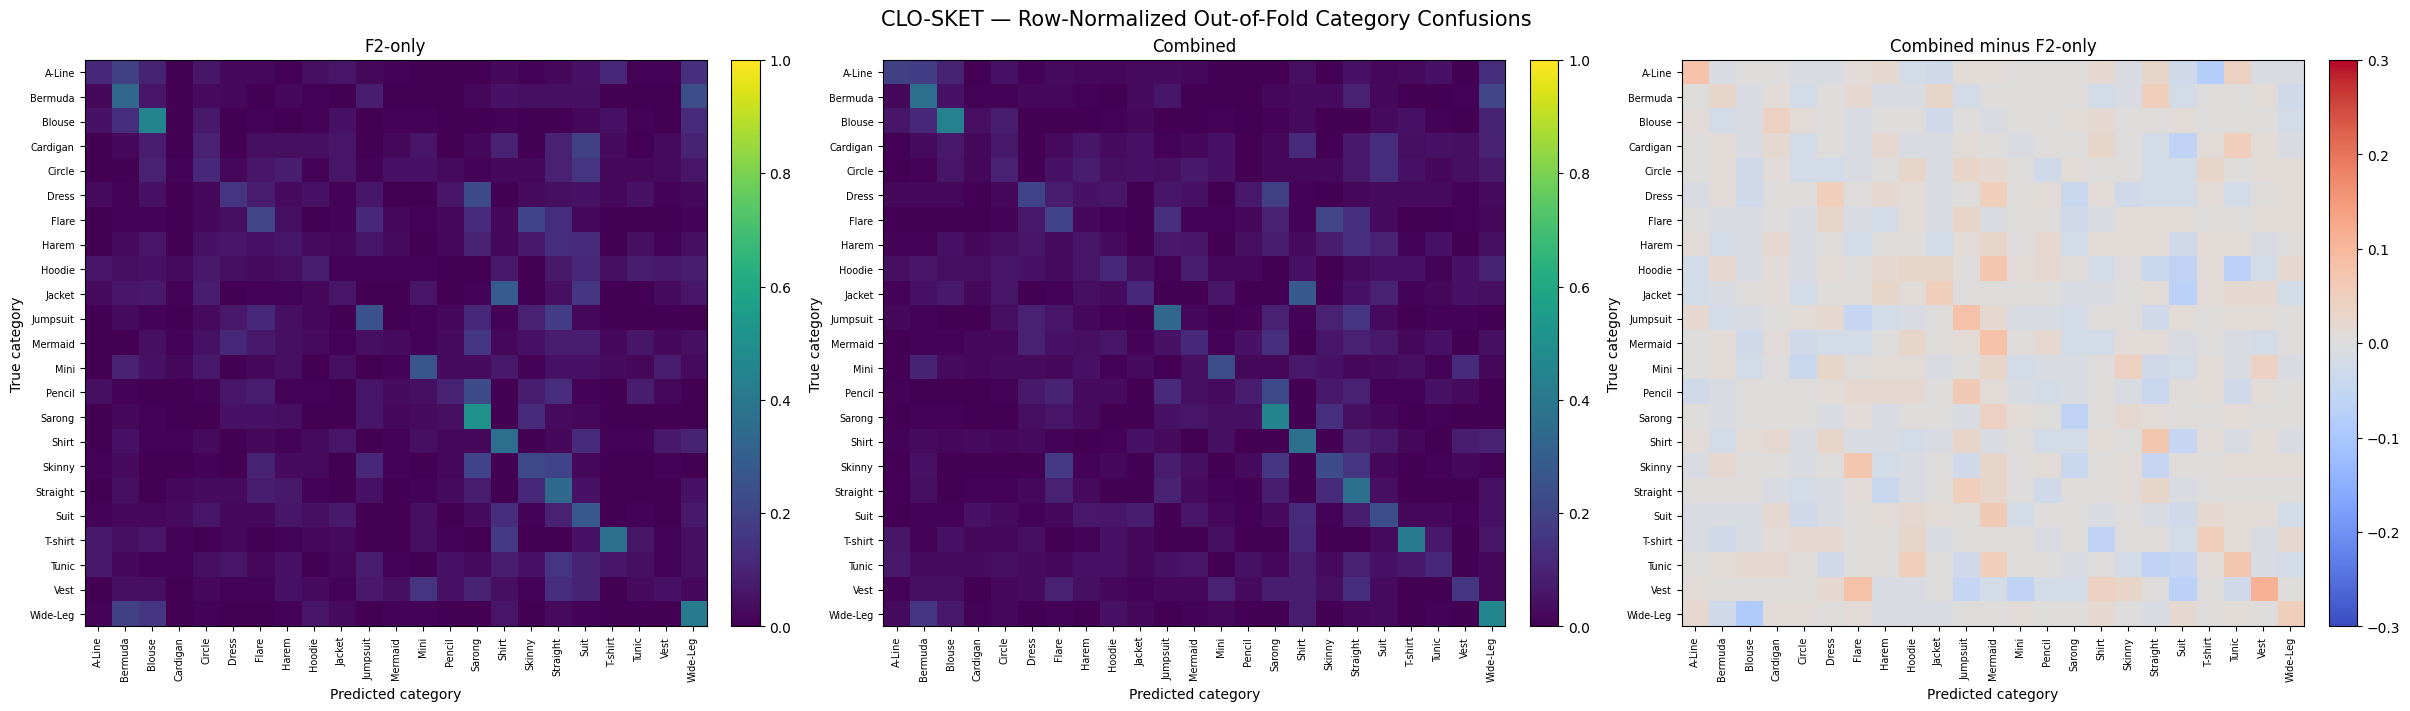


CELL 26 — CATEGORY-WISE DIAGNOSTICS COMPLETE

SCIENTIFIC STATUS
-----------------
1. No model was fitted or tuned in Cell 26.
2. Every diagnostic uses the frozen Cell 24 prediction made while that sketch
   was held out from training.
3. Category metrics, rankings, transitions, and confusion pairs are descriptive.
4. No category-wise significance tests were performed; inspecting 23 categories
   creates multiplicity and selection concerns.
5. A positive category delta does not prove that alpha2 caused the improvement.
   It describes the behavior of the fixed combined representation relative to
   the fixed F2-only representation.
6. Category labels denote the supplied dataset taxonomy; the results do not
   establish semantic understanding or external generalization.
7. The independence/grouping caveat from Cells 24-25 remains in force.

PRIMARY INFERENCE
-----------------
The predeclared population-level incremental inference remains Cell 25's paired
permutation test. Cell 26 locali

In [ ]:
# ================================================================================
# CLO-SKET — CELL 26
# CATEGORY-WISE DIAGNOSTICS FROM FROZEN OUT-OF-FOLD PREDICTIONS
# ================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)


print("=" * 80)
print("CLO-SKET — CELL 26")
print("CATEGORY-WISE DIAGNOSTICS FROM FROZEN OUT-OF-FOLD PREDICTIONS")
print("=" * 80)


# ================================================================================
# 1. INPUT VERIFICATION — NO REFITTING IN THIS CELL
# ================================================================================

required = [
    "cell24_oof_predictions",
    "cell24_fold_scores",
    "cell24_results",
    "cell24_outer_splits",
    "cell24_protocol",
    "category_labels",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the corrected Cell 24 before Cell 26. Missing: "
        + ", ".join(missing)
    )

y = np.asarray(category_labels).reshape(-1)
if y.shape != (2300,):
    raise ValueError(f"Expected 2300 labels, found {y.shape}.")
if pd.isna(y).any():
    raise ValueError("Category labels contain missing values.")

representations = ("F2-only", "alpha2-only", "combined")
available = tuple(cell24_oof_predictions.keys())
for name in representations:
    if name not in cell24_oof_predictions:
        raise RuntimeError(
            f"Cell 24 OOF predictions do not contain '{name}'. Available: {available}."
        )

oof_predictions = {}
for name in representations:
    pred = np.asarray(cell24_oof_predictions[name]).reshape(-1)
    if pred.shape != y.shape:
        raise ValueError(f"{name}: expected OOF shape {y.shape}, found {pred.shape}.")
    if pd.isna(pred).any():
        raise ValueError(f"{name}: OOF predictions contain missing values.")
    unknown = np.setdiff1d(np.unique(pred), np.unique(y))
    if unknown.size:
        raise ValueError(f"{name}: predictions contain unknown labels: {unknown}.")
    oof_predictions[name] = pred

categories, counts = np.unique(y, return_counts=True)
if len(categories) != 23 or not np.all(counts == 100):
    raise ValueError("Expected 23 categories with 100 sketches each.")

# Confirm that Cell 24's five held-out sets partition the population exactly once.
seen = np.zeros(len(y), dtype=int)
for train_idx, test_idx in cell24_outer_splits:
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)
    if np.intersect1d(train_idx, test_idx).size:
        raise ValueError("A Cell 24 fold contains train/test overlap.")
    seen[test_idx] += 1
if not np.all(seen == 1):
    raise ValueError("Cell 24 held-out folds do not predict every sketch exactly once.")

print("\nINPUT VERIFICATION")
print("-" * 80)
print(f"Population          : {len(y)}")
print(f"Categories          : {len(categories)}")
print(f"Representations     : {representations}")
print("OOF coverage        : each sketch predicted exactly once")
print("Model fitting       : NONE")
print("GREEN: FROZEN CELL 24 OOF PREDICTIONS VERIFIED")


# ================================================================================
# 2. GLOBAL POOLED-OOF METRICS
# ================================================================================
#
# These are computed by pooling all 2,300 held-out predictions. They need not be
# numerically identical to the mean of five fold-level nonlinear metrics such as
# macro-F1. Fold means remain authoritative in Cell 24; pooled values describe
# the single complete OOF prediction vector used for category diagnostics.
# ================================================================================

global_rows = []
for name in representations:
    pred = oof_predictions[name]
    global_rows.append({
        "representation": name,
        "accuracy_pooled_OOF": accuracy_score(y, pred),
        "balanced_accuracy_pooled_OOF": balanced_accuracy_score(y, pred),
        "macro_F1_pooled_OOF": f1_score(y, pred, average="macro", zero_division=0),
    })

cell26_global_metrics = pd.DataFrame(global_rows)

print("\nGLOBAL POOLED-OOF PERFORMANCE")
print("-" * 80)
print(cell26_global_metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# BA must reproduce Cell 24 because folds have equal size and 20/class/fold.
cell24_lookup = cell24_results.set_index("representation")
for _, row in cell26_global_metrics.iterrows():
    name = row["representation"]
    expected = float(cell24_lookup.loc[name, "balanced_accuracy_mean"])
    observed = float(row["balanced_accuracy_pooled_OOF"])
    if not np.isclose(observed, expected, atol=1e-12):
        raise RuntimeError(f"{name}: pooled OOF BA does not reproduce Cell 24.")

print("GREEN: POOLED OOF BALANCED ACCURACY REPRODUCES CELL 24")


# ================================================================================
# 3. CATEGORY-WISE METRICS FOR ALL THREE FROZEN REPRESENTATIONS
# ================================================================================

metric_frames = []
for name in representations:
    precision, recall, f1, support = precision_recall_fscore_support(
        y,
        oof_predictions[name],
        labels=categories,
        zero_division=0,
    )
    metric_frames.append(pd.DataFrame({
        "category": categories,
        "representation": name,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "support": support.astype(int),
    }))

cell26_category_metrics_long = pd.concat(metric_frames, ignore_index=True)

wide_parts = []
for metric in ("precision", "recall", "F1"):
    part = cell26_category_metrics_long.pivot(
        index="category", columns="representation", values=metric
    )
    part.columns = [f"{name}_{metric}" for name in part.columns]
    wide_parts.append(part)

cell26_category_metrics = pd.concat(wide_parts, axis=1).reset_index()
cell26_category_metrics["support"] = 100
cell26_category_metrics["delta_recall_combined_vs_F2"] = (
    cell26_category_metrics["combined_recall"]
    - cell26_category_metrics["F2-only_recall"]
)
cell26_category_metrics["delta_F1_combined_vs_F2"] = (
    cell26_category_metrics["combined_F1"]
    - cell26_category_metrics["F2-only_F1"]
)

display_columns = [
    "category",
    "F2-only_precision", "F2-only_recall", "F2-only_F1",
    "alpha2-only_precision", "alpha2-only_recall", "alpha2-only_F1",
    "combined_precision", "combined_recall", "combined_F1",
    "delta_recall_combined_vs_F2", "delta_F1_combined_vs_F2",
    "support",
]

print("\nCATEGORY-WISE POOLED-OOF DIAGNOSTICS")
print("-" * 80)
print(
    cell26_category_metrics[display_columns].to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)


# ================================================================================
# 4. SAMPLE-LEVEL PAIRED TRANSITIONS: F2-ONLY -> COMBINED
# ================================================================================

f2_correct = oof_predictions["F2-only"] == y
combined_correct = oof_predictions["combined"] == y

transition_records = []
for category in categories:
    mask = y == category
    transition_records.append({
        "category": category,
        "support": int(mask.sum()),
        "both_correct": int(np.sum(mask & f2_correct & combined_correct)),
        "rescued_by_combined": int(np.sum(mask & ~f2_correct & combined_correct)),
        "harmed_by_combined": int(np.sum(mask & f2_correct & ~combined_correct)),
        "both_wrong": int(np.sum(mask & ~f2_correct & ~combined_correct)),
    })

cell26_paired_transitions = pd.DataFrame(transition_records)
cell26_paired_transitions["net_correct_gain"] = (
    cell26_paired_transitions["rescued_by_combined"]
    - cell26_paired_transitions["harmed_by_combined"]
)

transition_totals = {
    col: int(cell26_paired_transitions[col].sum())
    for col in ("both_correct", "rescued_by_combined", "harmed_by_combined", "both_wrong")
}

if sum(transition_totals.values()) != len(y):
    raise RuntimeError("Paired transition accounting does not sum to 2,300.")

print("\nPAIRED CORRECTNESS TRANSITIONS: F2-ONLY -> COMBINED")
print("-" * 80)
print(cell26_paired_transitions.to_string(index=False))
print("\nPopulation totals")
for key, value in transition_totals.items():
    print(f"    {key:22s}: {value}")
print(
    "    net correct gain      : "
    f"{transition_totals['rescued_by_combined'] - transition_totals['harmed_by_combined']}"
)


# ================================================================================
# 5. CONFUSION MATRICES
# ================================================================================

cell26_confusion_matrices = {
    name: confusion_matrix(y, oof_predictions[name], labels=categories)
    for name in representations
}

cm_f2 = cell26_confusion_matrices["F2-only"]
cm_alpha2 = cell26_confusion_matrices["alpha2-only"]
cm_combined = cell26_confusion_matrices["combined"]

# Row-normalized matrices are recall distributions. Support is exactly 100/class.
cell26_confusion_normalized = {
    name: cm.astype(float) / cm.sum(axis=1, keepdims=True)
    for name, cm in cell26_confusion_matrices.items()
}


# ================================================================================
# 6. DIRECTIONAL AND SYMMETRIC CONFUSION TABLES
# ================================================================================

directional_rows = []
for i, true_category in enumerate(categories):
    for j, predicted_category in enumerate(categories):
        if i == j:
            continue
        count = int(cm_combined[i, j])
        if count > 0:
            directional_rows.append({
                "true_category": true_category,
                "predicted_category": predicted_category,
                "combined_count": count,
                "F2_count": int(cm_f2[i, j]),
                "count_change_combined_minus_F2": count - int(cm_f2[i, j]),
            })

cell26_directional_confusions = (
    pd.DataFrame(directional_rows)
    .sort_values(["combined_count", "true_category", "predicted_category"],
                 ascending=[False, True, True])
    .reset_index(drop=True)
)

pair_rows = []
for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        f2_pair = int(cm_f2[i, j] + cm_f2[j, i])
        combined_pair = int(cm_combined[i, j] + cm_combined[j, i])
        if f2_pair or combined_pair:
            pair_rows.append({
                "category_A": categories[i],
                "category_B": categories[j],
                "F2_symmetric_confusion": f2_pair,
                "combined_symmetric_confusion": combined_pair,
                "reduction_F2_minus_combined": f2_pair - combined_pair,
            })

cell26_symmetric_confusions = pd.DataFrame(pair_rows)
cell26_strongest_combined_pairs = (
    cell26_symmetric_confusions
    .sort_values(
        ["combined_symmetric_confusion", "category_A", "category_B"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)
cell26_largest_confusion_reductions = (
    cell26_symmetric_confusions
    .sort_values(
        ["reduction_F2_minus_combined", "category_A", "category_B"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)

print("\nSTRONGEST DIRECTIONAL ERRORS — COMBINED")
print("-" * 80)
print(cell26_directional_confusions.head(20).to_string(index=False))

print("\nSTRONGEST SYMMETRIC CONFUSIONS — COMBINED")
print("-" * 80)
print(cell26_strongest_combined_pairs.head(15).to_string(index=False))

print("\nLARGEST SYMMETRIC CONFUSION REDUCTIONS — COMBINED VS F2")
print("-" * 80)
print(cell26_largest_confusion_reductions.head(15).to_string(index=False))


# ================================================================================
# 7. DESCRIPTIVE CATEGORY DISTRIBUTION — NOT FEATURE SELECTION
# ================================================================================

delta = cell26_category_metrics["delta_F1_combined_vs_F2"].to_numpy()
improved = delta > 0
unchanged = np.isclose(delta, 0.0, atol=1e-12)
declined = delta < 0

cell26_category_change_summary = pd.DataFrame([{
    "n_categories": len(categories),
    "improved_F1": int(improved.sum()),
    "unchanged_F1": int(unchanged.sum()),
    "declined_F1": int(declined.sum()),
    "mean_delta_F1": float(delta.mean()),
    "median_delta_F1": float(np.median(delta)),
}])

print("\nCATEGORY-WISE F1 CHANGE: COMBINED VS F2-ONLY")
print("-" * 80)
print(cell26_category_change_summary.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


# ================================================================================
# 8. VISUALIZATION — ROW-NORMALIZED OOF CONFUSIONS
# ================================================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

plots = [
    (cell26_confusion_normalized["F2-only"], "F2-only", "viridis", 0.0, 1.0),
    (cell26_confusion_normalized["combined"], "Combined", "viridis", 0.0, 1.0),
    (
        cell26_confusion_normalized["combined"]
        - cell26_confusion_normalized["F2-only"],
        "Combined minus F2-only",
        "coolwarm",
        -0.30,
        0.30,
    ),
]

for ax, (matrix, title, cmap, vmin, vmax) in zip(axes, plots):
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted category")
    ax.set_ylabel("True category")
    ax.set_xticks(np.arange(len(categories)))
    ax.set_yticks(np.arange(len(categories)))
    ax.set_xticklabels(categories, rotation=90, fontsize=7)
    ax.set_yticklabels(categories, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "CLO-SKET — Row-Normalized Out-of-Fold Category Confusions",
    fontsize=15,
)
cell26_confusion_figure = fig
plt.show()


# ================================================================================
# 9. SCIENTIFIC STATUS
# ================================================================================

print("\n" + "=" * 80)
print("CELL 26 — CATEGORY-WISE DIAGNOSTICS COMPLETE")
print("=" * 80)
print("""
SCIENTIFIC STATUS
-----------------
1. No model was fitted or tuned in Cell 26.
2. Every diagnostic uses the frozen Cell 24 prediction made while that sketch
   was held out from training.
3. Category metrics, rankings, transitions, and confusion pairs are descriptive.
4. No category-wise significance tests were performed; inspecting 23 categories
   creates multiplicity and selection concerns.
5. A positive category delta does not prove that alpha2 caused the improvement.
   It describes the behavior of the fixed combined representation relative to
   the fixed F2-only representation.
6. Category labels denote the supplied dataset taxonomy; the results do not
   establish semantic understanding or external generalization.
7. The independence/grouping caveat from Cells 24-25 remains in force.

PRIMARY INFERENCE
-----------------
The predeclared population-level incremental inference remains Cell 25's paired
permutation test. Cell 26 localizes that aggregate behavior without creating a
new feature-selection or hypothesis-testing stage.
""")
print("GREEN: READY FOR FINAL SYNTHESIS")


## 9. Population recovery and reliability diagnostics

These diagnostics evaluate the observed and learned moments at each sketch's deterministic dominant-F₂ shell in the fixed radial domain. They do **not** evaluate the entire angular distribution, and the error–R₂ relation is partly expected because orientation becomes unstable as axial concentration approaches zero.


🧪 CLO-SKET — CELL 30D
POPULATION-LEVEL RADIAL–ANGULAR RECOVERY

INPUT VERIFICATION
--------------------------------------------------------------------------------
🟢 image_paths                  shape = (2300,)
🟢 F2_mag                       shape = (2300, 72)
🟢 radial_centers               shape = (72,)
🟢 R2_obs                       shape = (2300, 25)
🟢 mu2_obs_deg                  shape = (2300, 25)
🟢 R2_hat_field                 shape = (2300, 25)
🟢 mu2_hat_field_deg            shape = (2300, 25)

POPULATION
--------------------------------------------------------------------------------
Population : 2300
Radial bins : 72
Circular shells : 25

LOCKED RADIAL DOMAIN
--------------------------------------------------------------------------------
F₂ / circular shared domain : 3.50 → 27.50
F₂ bins inside domain       : 25

DOMAIN-CONSISTENT F₂ PEAK
--------------------------------------------------------------------------------
Minimum peak radius : 3.5
Maximum peak radius : 27.5
Valid

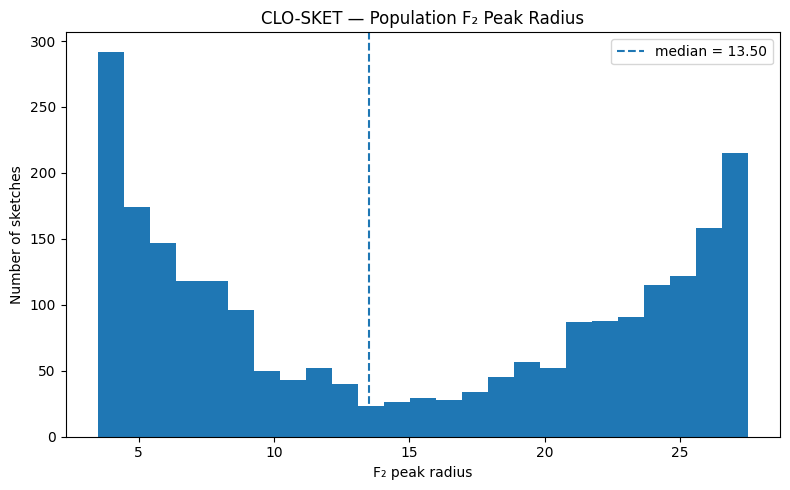

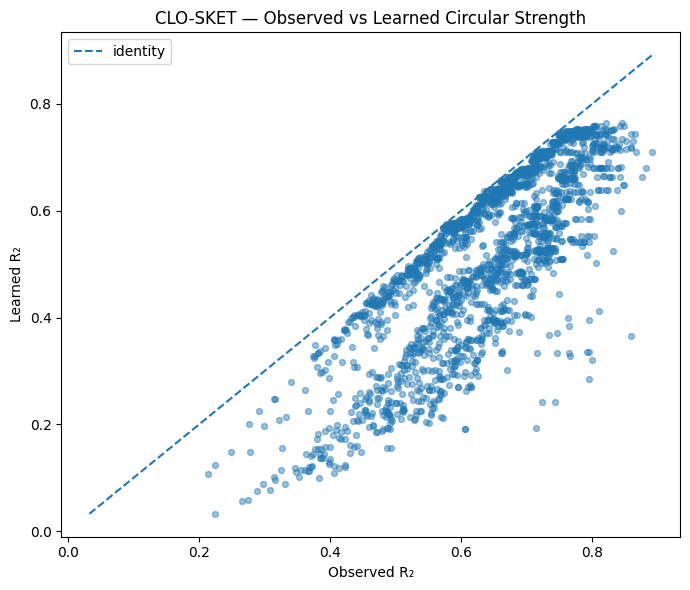

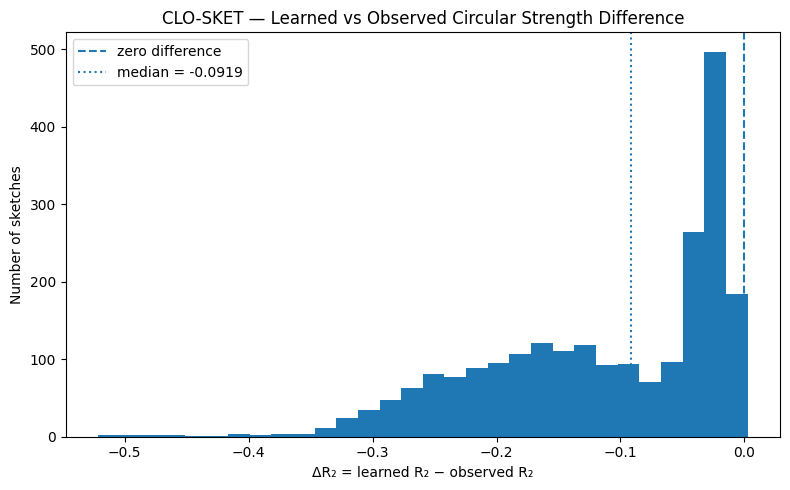

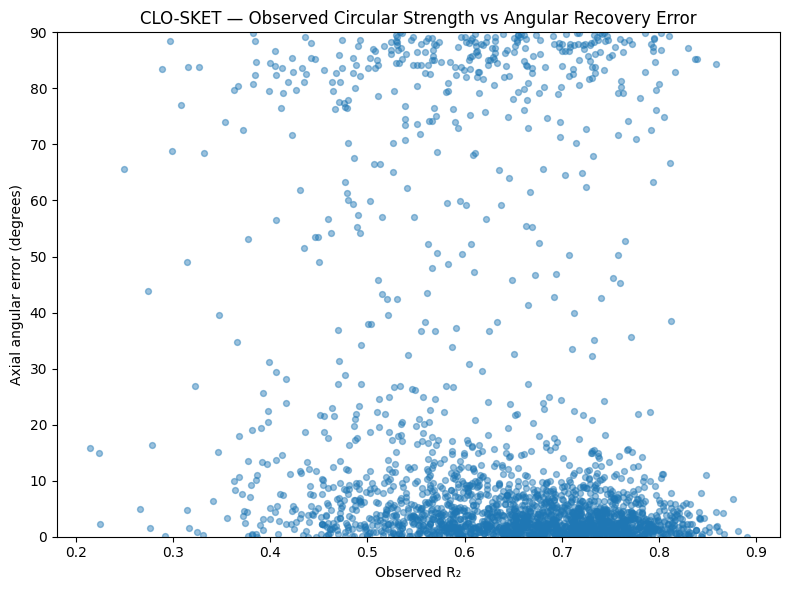


CELL 30D — POPULATION-LEVEL RECOVERY SUMMARY

Population analyzed                 : 2300 / 2300

Shared radial domain                : 3.50 → 27.50

Median F₂ peak radius               : 13.500

Median observed R₂                  : 0.6604

Median learned R₂                   : 0.5574

Median ΔR₂                           : -0.0919

Median axial angular error          : 4.16°

Axial error ≤15°                    : 78.04%

Axial error 15–45°                  : 6.26%

Axial error >45°                    : 15.70%

Observed vs learned R₂
    Pearson r                        : 0.8080
    Spearman ρ                       : 0.7995

Observed R₂ vs axial error
    Pearson r                        : -0.1929
    Spearman ρ                       : -0.2496


SCIENTIFIC INTERPRETATION
-------------------------

This analysis evaluates population-level recovery
of radial–angular organization.

ΔR₂ retains its sign:

    ΔR₂ > 0
        learned circular organization is stronger
        than observed.

In [ ]:
# ================================================================================
# 🧪 CLO-SKET — CELL 30D
# POPULATION-LEVEL RADIAL–ANGULAR RECOVERY
# ================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

print("=" * 80)
print("🧪 CLO-SKET — CELL 30D")
print("POPULATION-LEVEL RADIAL–ANGULAR RECOVERY")
print("=" * 80)


# ================================================================================
# 1. INPUT VERIFICATION
# ================================================================================

required_objects = [
    "image_paths",
    "F2_mag",
    "radial_centers",
    "R2_obs",
    "mu2_obs_deg",
    "R2_hat_field",
    "mu2_hat_field_deg",
]

print("\nINPUT VERIFICATION")
print("-" * 80)

missing = []

for name in required_objects:

    if name not in globals():

        missing.append(name)

        print(f"🔴 {name:28s} MISSING")

    else:

        arr = np.asarray(globals()[name])

        print(
            f"🟢 {name:28s} shape = {arr.shape}"
        )

if missing:

    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
    )


# ================================================================================
# 2. BASIC DIMENSION CHECK
# ================================================================================

N = len(image_paths)

F2_mag_arr = np.asarray(F2_mag, dtype=float)
radial_centers_arr = np.asarray(radial_centers, dtype=float)

R2_obs_arr = np.asarray(R2_obs, dtype=float)
R2_hat_arr = np.asarray(R2_hat_field, dtype=float)

mu_obs_arr = np.asarray(mu2_obs_deg, dtype=float)
mu_hat_arr = np.asarray(mu2_hat_field_deg, dtype=float)


print("\nPOPULATION")
print("-" * 80)

print("Population :", N)
print("Radial bins :", len(radial_centers_arr))
print("Circular shells :", R2_obs_arr.shape[1])


if F2_mag_arr.shape[0] != N:
    raise ValueError("F2_mag population dimension mismatch.")

if R2_obs_arr.shape[0] != N:
    raise ValueError("R2_obs population dimension mismatch.")

if R2_hat_arr.shape[0] != N:
    raise ValueError("R2_hat_field population dimension mismatch.")

if mu_obs_arr.shape[0] != N:
    raise ValueError("mu2_obs_deg population dimension mismatch.")

if mu_hat_arr.shape[0] != N:
    raise ValueError("mu2_hat_field_deg population dimension mismatch.")


# ================================================================================
# 3. LOCKED SHARED RADIAL DOMAIN
# ================================================================================

DOMAIN_MIN = 3.5
DOMAIN_MAX = 27.5

domain_mask = (
    (radial_centers_arr >= DOMAIN_MIN)
    &
    (radial_centers_arr <= DOMAIN_MAX)
)

domain_indices = np.where(domain_mask)[0]

if len(domain_indices) == 0:

    raise RuntimeError(
        "No F₂ radial bins found inside the locked circular domain."
    )


print("\nLOCKED RADIAL DOMAIN")
print("-" * 80)

print(
    f"F₂ / circular shared domain : "
    f"{DOMAIN_MIN:.2f} → {DOMAIN_MAX:.2f}"
)

print(
    "F₂ bins inside domain       :",
    len(domain_indices)
)


# ================================================================================
# 4. FIND F₂ PEAK WITHIN THE SHARED DOMAIN
# ================================================================================

F2_domain = F2_mag_arr[:, domain_indices]

valid_f2 = np.isfinite(F2_domain)

F2_for_peak = np.where(
    valid_f2,
    F2_domain,
    -np.inf
)

peak_local_idx = np.argmax(
    F2_for_peak,
    axis=1
)

peak_global_idx = domain_indices[
    peak_local_idx
]

peak_radius = radial_centers_arr[
    peak_global_idx
]

peak_magnitude = F2_mag_arr[
    np.arange(N),
    peak_global_idx
]


valid_peak = np.isfinite(
    peak_magnitude
)


print("\nDOMAIN-CONSISTENT F₂ PEAK")
print("-" * 80)

print(
    "Minimum peak radius :",
    np.nanmin(peak_radius)
)

print(
    "Maximum peak radius :",
    np.nanmax(peak_radius)
)

print(
    "Valid F₂ peaks      :",
    np.sum(valid_peak),
    "/",
    N
)


# ================================================================================
# 5. MATCH F₂ PEAK TO CIRCULAR SHELL
# ================================================================================

circular_shell_count = R2_obs_arr.shape[1]

# The circular analysis has 25 shells spanning the same
# established radial domain.

circular_radii = np.linspace(
    DOMAIN_MIN,
    DOMAIN_MAX,
    circular_shell_count
)

matched_shell_idx = np.argmin(
    np.abs(
        peak_radius[:, None]
        -
        circular_radii[None, :]
    ),
    axis=1
)

matched_radius = circular_radii[
    matched_shell_idx
]


print("\nRADIAL SHELL MATCHING")
print("-" * 80)

print(
    "Circular shell radius range :",
    f"{circular_radii[0]:.2f} → {circular_radii[-1]:.2f}"
)

print(
    "Maximum F₂-to-circular radius mismatch :",
    f"{np.max(np.abs(peak_radius - matched_radius)):.4f}"
)


# ================================================================================
# 6. EXTRACT OBSERVED / LEARNED R₂ AT MATCHED RADIUS
# ================================================================================

rows = np.arange(N)

R2_obs_peak = R2_obs_arr[
    rows,
    matched_shell_idx
]

R2_hat_peak = R2_hat_arr[
    rows,
    matched_shell_idx
]

mu_obs_peak = mu_obs_arr[
    rows,
    matched_shell_idx
]

mu_hat_peak = mu_hat_arr[
    rows,
    matched_shell_idx
]


# ================================================================================
# 7. AXIAL ANGULAR ERROR
# ================================================================================

# α ≡ α + 180°
#
# Therefore compare doubled angles:
#
#     θ = 2α
#
# and wrap the difference to [-180°, 180°].
#
# Final axial error is the absolute half-angle difference,
# restricted to [0°, 90°].

double_obs = np.deg2rad(
    2.0 * mu_obs_peak
)

double_hat = np.deg2rad(
    2.0 * mu_hat_peak
)

double_difference = np.angle(
    np.exp(
        1j * (double_hat - double_obs)
    )
)

axial_error_deg = (
    np.abs(
        np.rad2deg(
            double_difference
        )
    )
    / 2.0
)


# ================================================================================
# 8. CIRCULAR ORIENTATION AGREEMENT
# ================================================================================

orientation_agreement = np.cos(
    2.0 * (
        np.deg2rad(mu_hat_peak)
        -
        np.deg2rad(mu_obs_peak)
    )
)


# ================================================================================
# 9. R₂ DIFFERENCE
# ================================================================================

delta_R2 = (
    R2_hat_peak
    -
    R2_obs_peak
)


# ================================================================================
# 10. VALID POPULATION
# ================================================================================

valid = (
    np.isfinite(peak_radius)
    &
    np.isfinite(R2_obs_peak)
    &
    np.isfinite(R2_hat_peak)
    &
    np.isfinite(mu_obs_peak)
    &
    np.isfinite(mu_hat_peak)
    &
    np.isfinite(axial_error_deg)
)

n_valid = int(
    np.sum(valid)
)


print("\nPOPULATION VALIDITY")
print("-" * 80)

print(
    "Valid sketches   :",
    n_valid,
    "/",
    N
)

print(
    "Invalid sketches :",
    N - n_valid
)


if n_valid == 0:

    raise RuntimeError(
        "No valid sketches remain for population analysis."
    )


# ================================================================================
# 11. SUMMARY STATISTICS
# ================================================================================

def summary_stats(x):

    x = np.asarray(x, dtype=float)

    x = x[np.isfinite(x)]

    return {
        "N": len(x),
        "mean": np.mean(x),
        "median": np.median(x),
        "sd": np.std(x, ddof=1),
        "q25": np.percentile(x, 25),
        "q75": np.percentile(x, 75),
        "min": np.min(x),
        "max": np.max(x),
    }


peak_stats = summary_stats(
    peak_radius[valid]
)

obs_R2_stats = summary_stats(
    R2_obs_peak[valid]
)

learned_R2_stats = summary_stats(
    R2_hat_peak[valid]
)

delta_R2_stats = summary_stats(
    delta_R2[valid]
)

axial_error_stats = summary_stats(
    axial_error_deg[valid]
)

agreement_stats = summary_stats(
    orientation_agreement[valid]
)


print("\nPOPULATION SUMMARY")
print("-" * 80)

print(
    f"F₂ peak radius       : "
    f"median={peak_stats['median']:.3f}, "
    f"IQR=[{peak_stats['q25']:.3f}, "
    f"{peak_stats['q75']:.3f}]"
)

print(
    f"Observed R₂          : "
    f"median={obs_R2_stats['median']:.4f}, "
    f"IQR=[{obs_R2_stats['q25']:.4f}, "
    f"{obs_R2_stats['q75']:.4f}]"
)

print(
    f"Learned R₂           : "
    f"median={learned_R2_stats['median']:.4f}, "
    f"IQR=[{learned_R2_stats['q25']:.4f}, "
    f"{learned_R2_stats['q75']:.4f}]"
)

print(
    f"ΔR₂ (learned-observed): "
    f"median={delta_R2_stats['median']:+.4f}, "
    f"IQR=[{delta_R2_stats['q25']:+.4f}, "
    f"{delta_R2_stats['q75']:+.4f}]"
)

print(
    f"Axial error          : "
    f"median={axial_error_stats['median']:.2f}°, "
    f"IQR=[{axial_error_stats['q25']:.2f}°, "
    f"{axial_error_stats['q75']:.2f}°]"
)

print(
    f"Axial agreement cos(2Δα): "
    f"median={agreement_stats['median']:.4f}"
)


# ================================================================================
# 12. POSITIVE / NEGATIVE ΔR₂
# ================================================================================

positive_delta = np.sum(
    delta_R2[valid] > 0
)

negative_delta = np.sum(
    delta_R2[valid] < 0
)

zero_delta = np.sum(
    np.isclose(
        delta_R2[valid],
        0.0,
        atol=1e-12
    )
)


print("\nR₂ STRENGTH DIRECTION")
print("-" * 80)

print(
    "Learned R₂ > observed R₂ :",
    positive_delta,
    f"({100 * positive_delta / n_valid:.2f}%)"
)

print(
    "Learned R₂ < observed R₂ :",
    negative_delta,
    f"({100 * negative_delta / n_valid:.2f}%)"
)

print(
    "Approximately equal       :",
    zero_delta,
    f"({100 * zero_delta / n_valid:.2f}%)"
)


# ================================================================================
# 13. AXIAL ERROR BANDS
# ================================================================================

low_error = np.sum(
    axial_error_deg[valid] <= 15.0
)

moderate_error = np.sum(
    (axial_error_deg[valid] > 15.0)
    &
    (axial_error_deg[valid] <= 45.0)
)

high_error = np.sum(
    axial_error_deg[valid] > 45.0
)


print("\nAXIAL RECOVERY BANDS")
print("-" * 80)

print(
    f"Low error      ≤15°  : "
    f"{low_error} "
    f"({100 * low_error / n_valid:.2f}%)"
)

print(
    f"Moderate 15–45°      : "
    f"{moderate_error} "
    f"({100 * moderate_error / n_valid:.2f}%)"
)

print(
    f"High error      >45° : "
    f"{high_error} "
    f"({100 * high_error / n_valid:.2f}%)"
)


# ================================================================================
# 14. R₂ STRENGTH AGREEMENT
# ================================================================================

obs_valid = R2_obs_peak[valid]
learned_valid = R2_hat_peak[valid]

pearson_r, pearson_p = pearsonr(
    obs_valid,
    learned_valid
)

spearman_rho, spearman_p = spearmanr(
    obs_valid,
    learned_valid
)


print("\nOBSERVED VS LEARNED R₂")
print("-" * 80)

print(
    f"Pearson r   : {pearson_r:.4f}"
)

print(
    f"Pearson p   : {pearson_p:.6g}"
)

print(
    f"Spearman ρ  : {spearman_rho:.4f}"
)

print(
    f"Spearman p  : {spearman_p:.6g}"
)


# ================================================================================
# 15. OBSERVED R₂ VS AXIAL ERROR
# ================================================================================

error_valid = axial_error_deg[valid]

pearson_r_error, pearson_p_error = pearsonr(
    obs_valid,
    error_valid
)

spearman_rho_error, spearman_p_error = spearmanr(
    obs_valid,
    error_valid
)


print("\nOBSERVED R₂ VS AXIAL ERROR")
print("-" * 80)

print(
    f"Pearson r   : {pearson_r_error:.4f}"
)

print(
    f"Pearson p   : {pearson_p_error:.6g}"
)

print(
    f"Spearman ρ  : {spearman_rho_error:.4f}"
)

print(
    f"Spearman p  : {spearman_p_error:.6g}"
)


# ================================================================================
# 16. BUILD POPULATION DATAFRAME
# ================================================================================

cell30d_population = pd.DataFrame({

    "sample_index":
        np.arange(N),

    "F2_peak_radius":
        peak_radius,

    "F2_peak_magnitude":
        peak_magnitude,

    "matched_circular_radius":
        matched_radius,

    "R2_observed":
        R2_obs_peak,

    "R2_learned":
        R2_hat_peak,

    "delta_R2":
        delta_R2,

    "mu2_observed_deg":
        mu_obs_peak,

    "mu2_learned_deg":
        mu_hat_peak,

    "axial_error_deg":
        axial_error_deg,

    "axial_orientation_agreement":
        orientation_agreement,

    "valid":
        valid,
})


# ================================================================================
# 17. VISUALIZATION 1 — F₂ PEAK RADIUS
# ================================================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    peak_radius[valid],
    bins=25
)

plt.axvline(
    np.median(peak_radius[valid]),
    linestyle="--",
    label=(
        f"median = "
        f"{np.median(peak_radius[valid]):.2f}"
    )
)

plt.xlabel(
    "F₂ peak radius"
)

plt.ylabel(
    "Number of sketches"
)

plt.title(
    "CLO-SKET — Population F₂ Peak Radius"
)

plt.legend()

plt.tight_layout()

plt.show()


# ================================================================================
# 18. VISUALIZATION 2 — OBSERVED VS LEARNED R₂
# ================================================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(
    obs_valid,
    learned_valid,
    alpha=0.45,
    s=18
)

xy_min = min(
    np.min(obs_valid),
    np.min(learned_valid)
)

xy_max = max(
    np.max(obs_valid),
    np.max(learned_valid)
)

plt.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    label="identity"
)

plt.xlabel(
    "Observed R₂"
)

plt.ylabel(
    "Learned R₂"
)

plt.title(
    "CLO-SKET — Observed vs Learned Circular Strength"
)

plt.legend()

plt.tight_layout()

plt.show()


# ================================================================================
# 19. VISUALIZATION 3 — ΔR₂ DISTRIBUTION
# ================================================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    delta_R2[valid],
    bins=30
)

plt.axvline(
    0.0,
    linestyle="--",
    label="zero difference"
)

plt.axvline(
    np.median(delta_R2[valid]),
    linestyle=":",
    label=(
        f"median = "
        f"{np.median(delta_R2[valid]):+.4f}"
    )
)

plt.xlabel(
    "ΔR₂ = learned R₂ − observed R₂"
)

plt.ylabel(
    "Number of sketches"
)

plt.title(
    "CLO-SKET — Learned vs Observed Circular Strength Difference"
)

plt.legend()

plt.tight_layout()

plt.show()


# ================================================================================
# 20. VISUALIZATION 4 — OBSERVED R₂ VS AXIAL ERROR
# ================================================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    obs_valid,
    error_valid,
    alpha=0.45,
    s=18
)

plt.xlabel(
    "Observed R₂"
)

plt.ylabel(
    "Axial angular error (degrees)"
)

plt.title(
    "CLO-SKET — Observed Circular Strength vs Angular Recovery Error"
)

plt.ylim(
    0,
    90
)

plt.tight_layout()

plt.show()


# ================================================================================
# 21. SAVE COMPACT SUMMARY OBJECT
# ================================================================================

cell30d_summary = {

    "population": N,

    "valid_population": n_valid,

    "shared_radial_domain": (
        DOMAIN_MIN,
        DOMAIN_MAX
    ),

    "F2_peak_radius": peak_stats,

    "observed_R2": obs_R2_stats,

    "learned_R2": learned_R2_stats,

    "delta_R2": delta_R2_stats,

    "axial_error_deg": axial_error_stats,

    "orientation_agreement": agreement_stats,

    "R2_positive_delta_count":
        int(positive_delta),

    "R2_negative_delta_count":
        int(negative_delta),

    "R2_zero_delta_count":
        int(zero_delta),

    "axial_error_low_count":
        int(low_error),

    "axial_error_moderate_count":
        int(moderate_error),

    "axial_error_high_count":
        int(high_error),

    "pearson_observed_vs_learned_R2":
        float(pearson_r),

    "spearman_observed_vs_learned_R2":
        float(spearman_rho),

    "pearson_observed_R2_vs_axial_error":
        float(pearson_r_error),

    "spearman_observed_R2_vs_axial_error":
        float(spearman_rho_error),
}


# ================================================================================
# 22. FINAL SCIENTIFIC INTERPRETATION
# ================================================================================

print("\n" + "=" * 80)
print("CELL 30D — POPULATION-LEVEL RECOVERY SUMMARY")
print("=" * 80)

print(
    f"""
Population analyzed                 : {n_valid} / {N}

Shared radial domain                : {DOMAIN_MIN:.2f} → {DOMAIN_MAX:.2f}

Median F₂ peak radius               : {peak_stats['median']:.3f}

Median observed R₂                  : {obs_R2_stats['median']:.4f}

Median learned R₂                   : {learned_R2_stats['median']:.4f}

Median ΔR₂                           : {delta_R2_stats['median']:+.4f}

Median axial angular error          : {axial_error_stats['median']:.2f}°

Axial error ≤15°                    : {100 * low_error / n_valid:.2f}%

Axial error 15–45°                  : {100 * moderate_error / n_valid:.2f}%

Axial error >45°                    : {100 * high_error / n_valid:.2f}%

Observed vs learned R₂
    Pearson r                        : {pearson_r:.4f}
    Spearman ρ                       : {spearman_rho:.4f}

Observed R₂ vs axial error
    Pearson r                        : {pearson_r_error:.4f}
    Spearman ρ                       : {spearman_rho_error:.4f}
"""
)

print(
    """
SCIENTIFIC INTERPRETATION
-------------------------

This analysis evaluates population-level recovery
of radial–angular organization.

ΔR₂ retains its sign:

    ΔR₂ > 0
        learned circular organization is stronger
        than observed.

    ΔR₂ < 0
        learned circular organization is weaker
        than observed.

Angular disagreement is evaluated separately using
the doubled-angle axial representation:

    α ≡ α + 180°

Therefore axial angular error is reported as an
unsigned quantity in:

    0° → 90°

The two quantities should NOT be conflated.

This analysis does not establish:

    semantic garment-part recognition
    causal garment structure
    physical interpretation of angular modes

It evaluates empirical recovery of the measured
radial–angular representation.

No classifier was retrained.

No features were modified.

No category-based feature selection was performed.

No new representation was introduced.
"""
)

print("=" * 80)
print("🟢 CELL 30D — POPULATION RADIAL–ANGULAR RECOVERY COMPLETE")
print("=" * 80)


CLO-SKET — CELL 30E
STRATIFIED PEAK-SHELL RECONSTRUCTION BY OBSERVED R2

LOCKED ESTIMAND
----------------------------------------------------------------------------------------
Population retained                    : 2300 / 2300
Radial domain                         : 3.50–27.50
Evaluation shell                      : observed |F2| peak per sketch
Peak-radius range                     : 3.50–27.50
max |observed R2 - |F2|| at peak      : 6.661e-16

OBSERVED PEAK-SHELL R2 QUARTILES
----------------------------------------------------------------------------------------
Q25 = 0.5691   Q50 = 0.6604   Q75 = 0.7314

STRATIFIED PEAK-SHELL SUMMARY
------------------------------------------------------------------------------------------------------------
Stratum                 N     Obs R2    Recon R2    delta R2    Med err   <=15 deg   15–45 deg   >45 deg
------------------------------------------------------------------------------------------------------------
Q1 — weakest          575  

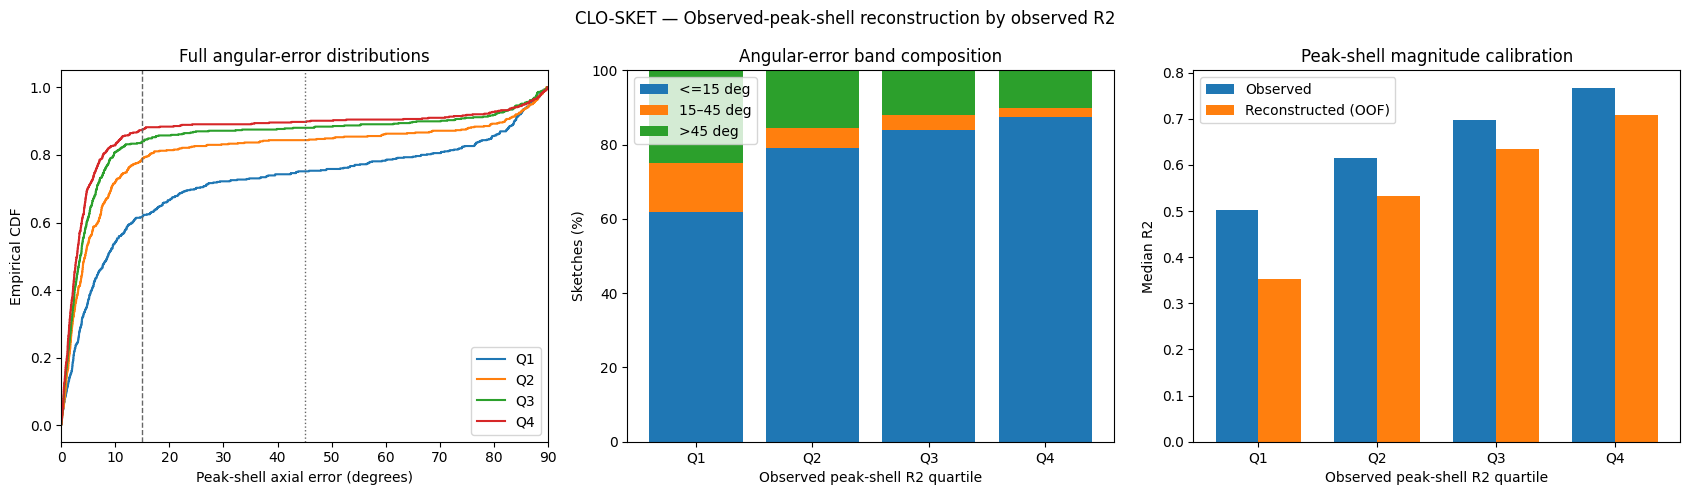


SCIENTIFIC INTERPRETATION
----------------------------------------------------------------------------------------

The quartiles are defined from observed R2 at each sketch's observed,
domain-constrained |F2| peak shell. Reconstructed R2 and axial error are then
evaluated at that same shell. These are peak-shell diagnostics, not radial
averages and not independent features.

An ordered decrease in angular error across the observed-R2 quartiles is a
descriptive association. It does not establish causality or a calibrated
reliability rule. Angular orientation is intrinsically less stable when the
resultant magnitude is weak, and the reconstruction inputs (r, |F2|) contain no
explicit phase. Near-zero within-quartile correlations are range-restricted and
do not contradict the population-level ordering.

Negative reconstructed-minus-observed R2 indicates peak-shell magnitude
attenuation/calibration compression. Because strata are selected on observed R2,
between-stratum delta-R2 patterns

In [ ]:
# ============================================================================
# CLO-SKET — CELL 30E
# STRATIFIED PEAK-SHELL RECONSTRUCTION BY OBSERVED R2
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import spearmanr
except ImportError:
    spearmanr = None

print("=" * 88)
print("CLO-SKET — CELL 30E")
print("STRATIFIED PEAK-SHELL RECONSTRUCTION BY OBSERVED R2")
print("=" * 88)

# ----------------------------------------------------------------------------
# 1. Inputs and locked estimand
# ----------------------------------------------------------------------------

required = (
    "F2_mag", "radial_centers", "R2_obs", "mu2_obs_deg",
    "R2_hat_field", "mu2_hat_field_deg",
)
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Missing required objects: " + ", ".join(missing))

F2_mag_arr = np.asarray(F2_mag, dtype=float)
radial = np.asarray(radial_centers, dtype=float)
R2_obs_arr = np.asarray(R2_obs, dtype=float)
mu_obs_arr = np.asarray(mu2_obs_deg, dtype=float)
R2_hat_arr = np.asarray(R2_hat_field, dtype=float)
mu_hat_arr = np.asarray(mu2_hat_field_deg, dtype=float)

if F2_mag_arr.ndim != 2 or radial.ndim != 1:
    raise ValueError("F2_mag must be 2-D and radial_centers must be 1-D.")
if F2_mag_arr.shape[1] != radial.size:
    raise ValueError("F2_mag columns must match radial_centers.")

N = F2_mag_arr.shape[0]
domain_min, domain_max = 3.5, 27.5
domain_indices = np.flatnonzero((radial >= domain_min) & (radial <= domain_max))
if domain_indices.size != 25:
    raise RuntimeError(
        "Expected 25 shells in the locked 3.50–27.50 domain; "
        f"found {domain_indices.size}."
    )

expected_field_shape = (N, domain_indices.size)
for name, arr in (
    ("R2_obs", R2_obs_arr), ("mu2_obs_deg", mu_obs_arr),
    ("R2_hat_field", R2_hat_arr), ("mu2_hat_field_deg", mu_hat_arr),
):
    if arr.shape != expected_field_shape:
        raise ValueError(f"{name} has shape {arr.shape}; expected {expected_field_shape}.")

# Per sketch, select the observed domain-constrained |F2| peak shell. All values
# below are evaluated at this observed shell; this is not an average over shells.
F2_domain = F2_mag_arr[:, domain_indices]
local_peak_idx = np.argmax(F2_domain, axis=1)
global_peak_idx = domain_indices[local_peak_idx]
row_idx = np.arange(N)

peak_radius = radial[global_peak_idx]
F2_at_observed_peak = F2_mag_arr[row_idx, global_peak_idx]
R2_obs_at_observed_peak = R2_obs_arr[row_idx, local_peak_idx]
R2_recon_at_observed_peak = R2_hat_arr[row_idx, local_peak_idx]
mu2_obs_at_observed_peak_deg = mu_obs_arr[row_idx, local_peak_idx]
mu2_recon_at_observed_peak_deg = mu_hat_arr[row_idx, local_peak_idx]

axial_error_at_observed_peak_deg = np.abs(
    ((mu2_obs_at_observed_peak_deg - mu2_recon_at_observed_peak_deg + 90.0)
     % 180.0) - 90.0
)
delta_R2_at_observed_peak = (
    R2_recon_at_observed_peak - R2_obs_at_observed_peak
)

valid = np.logical_and.reduce((
    np.isfinite(peak_radius),
    np.isfinite(F2_at_observed_peak),
    np.isfinite(R2_obs_at_observed_peak),
    np.isfinite(R2_recon_at_observed_peak),
    np.isfinite(mu2_obs_at_observed_peak_deg),
    np.isfinite(mu2_recon_at_observed_peak_deg),
    np.isfinite(axial_error_at_observed_peak_deg),
    np.isfinite(delta_R2_at_observed_peak),
))

valid_original_indices = np.flatnonzero(valid)
if not np.all(valid):
    print(f"WARNING: excluding {np.sum(~valid)} sketches with non-finite peak-shell values.")

peak_radius = peak_radius[valid]
F2_at_observed_peak = F2_at_observed_peak[valid]
R2_obs_at_observed_peak = R2_obs_at_observed_peak[valid]
R2_recon_at_observed_peak = R2_recon_at_observed_peak[valid]
mu2_obs_at_observed_peak_deg = mu2_obs_at_observed_peak_deg[valid]
mu2_recon_at_observed_peak_deg = mu2_recon_at_observed_peak_deg[valid]
axial_error_at_observed_peak_deg = axial_error_at_observed_peak_deg[valid]
delta_R2_at_observed_peak = delta_R2_at_observed_peak[valid]

# R2 = |F2| for the observed field. Keep the check, but do not report F2 peak
# magnitude as a second empirical variable.
identity_max_abs_error = float(np.max(np.abs(
    F2_at_observed_peak - R2_obs_at_observed_peak
)))

print("\nLOCKED ESTIMAND")
print("-" * 88)
print(f"Population retained                    : {len(peak_radius)} / {N}")
print(f"Radial domain                         : {domain_min:.2f}–{domain_max:.2f}")
print(f"Evaluation shell                      : observed |F2| peak per sketch")
print(f"Peak-radius range                     : {peak_radius.min():.2f}–{peak_radius.max():.2f}")
print(f"max |observed R2 - |F2|| at peak      : {identity_max_abs_error:.3e}")

# ----------------------------------------------------------------------------
# 2. Quartile strata defined only from observed peak-shell R2
# ----------------------------------------------------------------------------

q25, q50, q75 = np.quantile(R2_obs_at_observed_peak, [0.25, 0.50, 0.75])
strata = (
    ("Q1 — weakest", R2_obs_at_observed_peak <= q25),
    ("Q2", (R2_obs_at_observed_peak > q25) & (R2_obs_at_observed_peak <= q50)),
    ("Q3", (R2_obs_at_observed_peak > q50) & (R2_obs_at_observed_peak <= q75)),
    ("Q4 — strongest", R2_obs_at_observed_peak > q75),
)

print("\nOBSERVED PEAK-SHELL R2 QUARTILES")
print("-" * 88)
print(f"Q25 = {q25:.4f}   Q50 = {q50:.4f}   Q75 = {q75:.4f}")

print("\nSTRATIFIED PEAK-SHELL SUMMARY")
print("-" * 108)
print(
    f"{'Stratum':18s}{'N':>7s}{'Obs R2':>11s}{'Recon R2':>12s}{'delta R2':>12s}"
    f"{'Med err':>11s}{'<=15 deg':>11s}{'15–45 deg':>12s}{'>45 deg':>10s}"
)
print("-" * 108)

cell30e_results = []
for label, mask in strata:
    obs = R2_obs_at_observed_peak[mask]
    recon = R2_recon_at_observed_peak[mask]
    delta = delta_R2_at_observed_peak[mask]
    err = axial_error_at_observed_peak_deg[mask]
    n = int(mask.sum())

    pearson_r = float(np.corrcoef(obs, err)[0, 1]) if n > 2 else np.nan
    spearman_rho = (
        float(spearmanr(obs, err).statistic)
        if spearmanr is not None and n > 2 else np.nan
    )
    row = {
        "stratum": label,
        "n": n,
        "median_observed_R2_at_observed_peak": float(np.median(obs)),
        "median_reconstructed_R2_at_observed_peak": float(np.median(recon)),
        "median_delta_R2_at_observed_peak": float(np.median(delta)),
        "median_axial_error_at_observed_peak_deg": float(np.median(err)),
        "pct_error_le_15deg": float(100 * np.mean(err <= 15.0)),
        "pct_error_15_45deg": float(100 * np.mean((err > 15.0) & (err <= 45.0))),
        "pct_error_gt_45deg": float(100 * np.mean(err > 45.0)),
        "pearson_r_observed_R2_vs_axial_error": pearson_r,
        "spearman_rho_observed_R2_vs_axial_error": spearman_rho,
        # Compatibility aliases for downstream cells written against old 30E.
        "median_observed_R2": float(np.median(obs)),
        "median_learned_R2": float(np.median(recon)),
        "median_delta_R2": float(np.median(delta)),
        "median_axial_error_deg": float(np.median(err)),
    }
    cell30e_results.append(row)
    print(
        f"{label:18s}{n:7d}{np.median(obs):11.4f}{np.median(recon):12.4f}"
        f"{np.median(delta):12.4f}{np.median(err):11.2f}"
        f"{100*np.mean(err <= 15):11.2f}"
        f"{100*np.mean((err > 15) & (err <= 45)):12.2f}"
        f"{100*np.mean(err > 45):10.2f}"
    )

print("\nWITHIN-STRATUM ASSOCIATION (DESCRIPTIVE; RANGE RESTRICTED)")
print("-" * 88)
for row in cell30e_results:
    rho_text = (
        f"{row['spearman_rho_observed_R2_vs_axial_error']:+.4f}"
        if np.isfinite(row["spearman_rho_observed_R2_vs_axial_error"]) else "NA"
    )
    print(
        f"{row['stratum']:18s}  Pearson r = "
        f"{row['pearson_r_observed_R2_vs_axial_error']:+.4f}   "
        f"Spearman rho = {rho_text}"
    )

median_errors = np.array([
    row["median_axial_error_at_observed_peak_deg"] for row in cell30e_results
])
monotone_nonincreasing = bool(np.all(np.diff(median_errors) <= 0))
print("\nORDERED QUARTILE PATTERN")
print("-" * 88)
print("Median axial error by Q1–Q4 : " + " -> ".join(f"{x:.2f}" for x in median_errors))
print(f"Monotone non-increasing      : {monotone_nonincreasing}")
print("No correlation is computed from the four stratum medians.")

# ----------------------------------------------------------------------------
# 3. Plots that retain the near-orthogonal failure mode
# ----------------------------------------------------------------------------

plot_labels = ["Q1", "Q2", "Q3", "Q4"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ECDFs show the complete angular-error distribution without hiding outliers.
for (label, mask), short in zip(strata, plot_labels):
    x = np.sort(axial_error_at_observed_peak_deg[mask])
    y = np.arange(1, x.size + 1) / x.size
    axes[0].step(x, y, where="post", label=short)
axes[0].axvline(15, color="0.4", linestyle="--", linewidth=1)
axes[0].axvline(45, color="0.4", linestyle=":", linewidth=1)
axes[0].set(xlabel="Peak-shell axial error (degrees)", ylabel="Empirical CDF",
            title="Full angular-error distributions")
axes[0].set_xlim(0, 90)
axes[0].legend()

# Explicit error-band composition.
low = np.array([r["pct_error_le_15deg"] for r in cell30e_results])
mid = np.array([r["pct_error_15_45deg"] for r in cell30e_results])
high = np.array([r["pct_error_gt_45deg"] for r in cell30e_results])
xpos = np.arange(4)
axes[1].bar(xpos, low, label="<=15 deg")
axes[1].bar(xpos, mid, bottom=low, label="15–45 deg")
axes[1].bar(xpos, high, bottom=low + mid, label=">45 deg")
axes[1].set_xticks(xpos, plot_labels)
axes[1].set(xlabel="Observed peak-shell R2 quartile", ylabel="Sketches (%)",
            title="Angular-error band composition", ylim=(0, 100))
axes[1].legend()

# Calibration/compression at the same selected shell.
obs_med = np.array([r["median_observed_R2_at_observed_peak"] for r in cell30e_results])
rec_med = np.array([r["median_reconstructed_R2_at_observed_peak"] for r in cell30e_results])
width = 0.36
axes[2].bar(xpos - width/2, obs_med, width, label="Observed")
axes[2].bar(xpos + width/2, rec_med, width, label="Reconstructed (OOF)")
axes[2].set_xticks(xpos, plot_labels)
axes[2].set(xlabel="Observed peak-shell R2 quartile", ylabel="Median R2",
            title="Peak-shell magnitude calibration")
axes[2].legend()

fig.suptitle("CLO-SKET — Observed-peak-shell reconstruction by observed R2")
fig.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 4. Saved objects
# ----------------------------------------------------------------------------

cell30e_quantiles = {"Q25": float(q25), "Q50": float(q50), "Q75": float(q75)}
cell30e_population = {
    "N": int(len(R2_obs_at_observed_peak)),
    "domain_min": float(domain_min),
    "domain_max": float(domain_max),
    "evaluation_shell": "observed domain-constrained |F2| peak per sketch",
    "median_observed_R2_at_observed_peak": float(np.median(R2_obs_at_observed_peak)),
    "median_reconstructed_R2_at_observed_peak": float(np.median(R2_recon_at_observed_peak)),
    "median_delta_R2_at_observed_peak": float(np.median(delta_R2_at_observed_peak)),
    "median_axial_error_at_observed_peak_deg": float(np.median(axial_error_at_observed_peak_deg)),
    "peak_radius_at_domain_min_percent": float(100*np.mean(peak_radius == domain_min)),
    "peak_radius_at_domain_max_percent": float(100*np.mean(peak_radius == domain_max)),
    "F2_R2_identity_max_abs_error": identity_max_abs_error,
    "ordered_median_error_nonincreasing": monotone_nonincreasing,
    # Compatibility aliases.
    "median_observed_R2": float(np.median(R2_obs_at_observed_peak)),
    "median_learned_R2": float(np.median(R2_recon_at_observed_peak)),
    "median_delta_R2": float(np.median(delta_R2_at_observed_peak)),
    "median_axial_error_deg": float(np.median(axial_error_at_observed_peak_deg)),
}

cell30e_arrays = {
    "valid_original_indices": valid_original_indices.copy(),
    "peak_radius": peak_radius.copy(),
    "observed_R2_at_observed_peak": R2_obs_at_observed_peak.copy(),
    "reconstructed_R2_at_observed_peak": R2_recon_at_observed_peak.copy(),
    "delta_R2_at_observed_peak": delta_R2_at_observed_peak.copy(),
    "axial_error_at_observed_peak_deg": axial_error_at_observed_peak_deg.copy(),
}

print("\nSCIENTIFIC INTERPRETATION")
print("-" * 88)
print("""
The quartiles are defined from observed R2 at each sketch's observed,
domain-constrained |F2| peak shell. Reconstructed R2 and axial error are then
evaluated at that same shell. These are peak-shell diagnostics, not radial
averages and not independent features.

An ordered decrease in angular error across the observed-R2 quartiles is a
descriptive association. It does not establish causality or a calibrated
reliability rule. Angular orientation is intrinsically less stable when the
resultant magnitude is weak, and the reconstruction inputs (r, |F2|) contain no
explicit phase. Near-zero within-quartile correlations are range-restricted and
do not contradict the population-level ordering.

Negative reconstructed-minus-observed R2 indicates peak-shell magnitude
attenuation/calibration compression. Because strata are selected on observed R2,
between-stratum delta-R2 patterns are also affected by mathematical coupling and
regression to the mean. No correlation from the four stratum medians is treated
as inferential evidence.
""")

print("=" * 88)
print("CELL 30E COMPLETE")
print("Saved: cell30e_results, cell30e_quantiles, cell30e_population, cell30e_arrays")
print("=" * 88)


CLO-SKET — CELL 30F
PEAK-SHELL ANGULAR-ERROR REGIME DIAGNOSTICS

LOCKED ESTIMAND
----------------------------------------------------------------------------------------
Population retained                    : 2300 / 2300
Radial domain                         : 3.50–27.50
Evaluation shell                      : observed |F2| peak per sketch
max |observed R2 - |F2|| at peak      : 6.661e-16

ANGULAR-ERROR BAND SUMMARY
----------------------------------------------------------------------------------------------------
Band                           N        %      Obs R2    Recon R2    delta R2    Med error
----------------------------------------------------------------------------------------------------
Low error <=15 deg          1795    78.04      0.6751      0.5844     -0.0521         2.88
Intermediate 15–45 deg       144     6.26      0.5620      0.4248     -0.1720        21.75
High error >45 deg           361    15.70      0.6096      0.3953     -0.1962        83.71

LOWEST OBSE

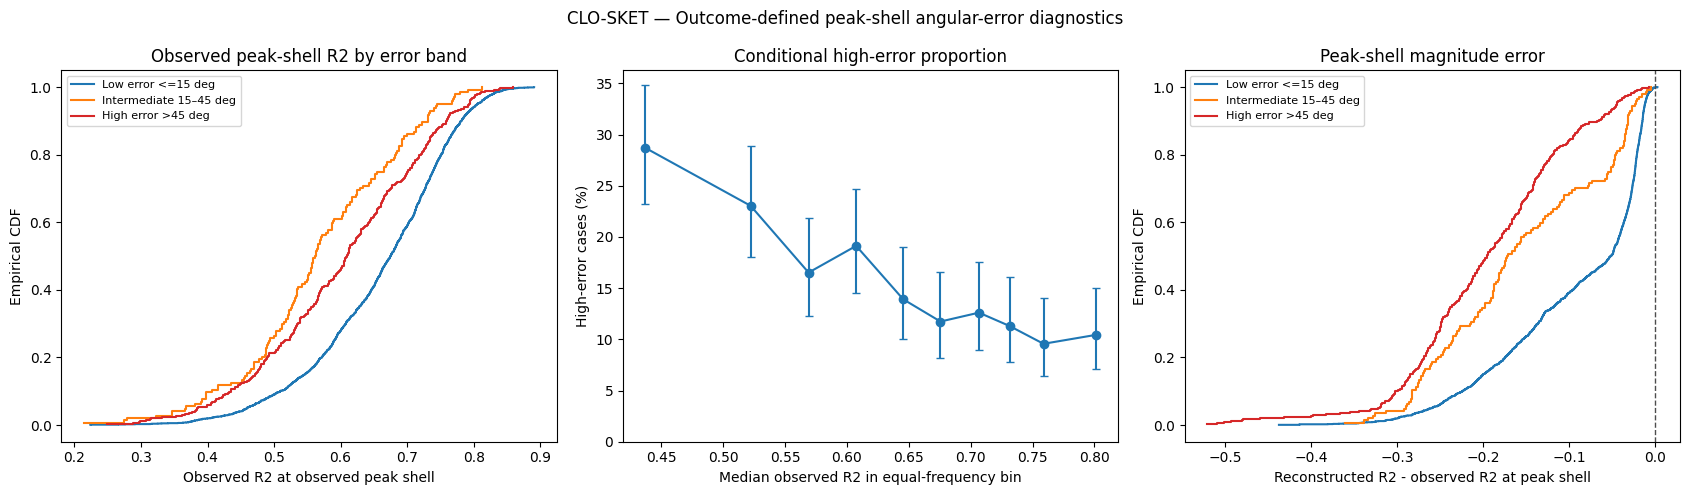

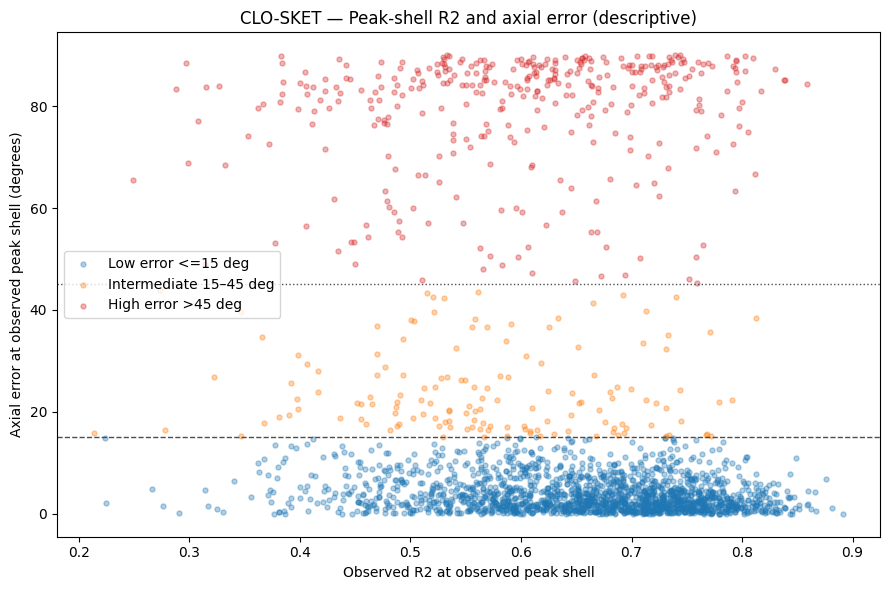


SCIENTIFIC INTERPRETATION
----------------------------------------------------------------------------------------

The three groups are defined after observing axial error at the observed,
domain-constrained |F2| peak shell. They are outcome-defined descriptive bands,
not externally validated reliability classes and not prospective predictions.
Comparisons between bands therefore diagnose joint reconstruction behavior; they
do not estimate a causal effect of R2 on angular error.

The Q1 risk ratio compares conditional high-error proportions. The accompanying
composition percentage answers a different question: where the high-error cases
occur. A Q1 enrichment can coexist with most high-error cases occurring outside
Q1.

Observed R2, reconstructed R2, and reconstructed angle arise from the same
peak-shell vector geometry. Low resultant magnitude and angular instability are
therefore intrinsically coupled. Moreover, the reconstruction predictors
(r, |F2|) contain no explicit phase. Neg

In [ ]:
# ============================================================================
# CLO-SKET — CELL 30F
# PEAK-SHELL ANGULAR-ERROR REGIME DIAGNOSTICS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 88)
print("CLO-SKET — CELL 30F")
print("PEAK-SHELL ANGULAR-ERROR REGIME DIAGNOSTICS")
print("=" * 88)

# ----------------------------------------------------------------------------
# 1. Standalone extraction of the locked peak-shell estimand
# ----------------------------------------------------------------------------

required = (
    "F2_mag", "radial_centers", "R2_obs", "mu2_obs_deg",
    "R2_hat_field", "mu2_hat_field_deg",
)
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Missing required objects: " + ", ".join(missing))

F2_mag_arr = np.asarray(F2_mag, dtype=float)
radial = np.asarray(radial_centers, dtype=float)
R2_obs_arr = np.asarray(R2_obs, dtype=float)
mu_obs_arr = np.asarray(mu2_obs_deg, dtype=float)
R2_hat_arr = np.asarray(R2_hat_field, dtype=float)
mu_hat_arr = np.asarray(mu2_hat_field_deg, dtype=float)

N = F2_mag_arr.shape[0]
domain_min, domain_max = 3.5, 27.5
domain_indices = np.flatnonzero((radial >= domain_min) & (radial <= domain_max))
if domain_indices.size != 25:
    raise RuntimeError(
        "Expected 25 shells in the locked 3.50–27.50 domain; "
        f"found {domain_indices.size}."
    )
expected_field_shape = (N, domain_indices.size)
for name, arr in (
    ("R2_obs", R2_obs_arr), ("mu2_obs_deg", mu_obs_arr),
    ("R2_hat_field", R2_hat_arr), ("mu2_hat_field_deg", mu_hat_arr),
):
    if arr.shape != expected_field_shape:
        raise ValueError(f"{name} has shape {arr.shape}; expected {expected_field_shape}.")

F2_domain = F2_mag_arr[:, domain_indices]
local_peak_idx = np.argmax(F2_domain, axis=1)
global_peak_idx = domain_indices[local_peak_idx]
row_idx = np.arange(N)

peak_radius = radial[global_peak_idx]
F2_at_observed_peak = F2_mag_arr[row_idx, global_peak_idx]
R2_obs_at_observed_peak = R2_obs_arr[row_idx, local_peak_idx]
R2_recon_at_observed_peak = R2_hat_arr[row_idx, local_peak_idx]
mu2_obs_at_observed_peak_deg = mu_obs_arr[row_idx, local_peak_idx]
mu2_recon_at_observed_peak_deg = mu_hat_arr[row_idx, local_peak_idx]
axial_error_at_observed_peak_deg = np.abs(
    ((mu2_obs_at_observed_peak_deg - mu2_recon_at_observed_peak_deg + 90.0)
     % 180.0) - 90.0
)
delta_R2_at_observed_peak = R2_recon_at_observed_peak - R2_obs_at_observed_peak

valid = np.logical_and.reduce((
    np.isfinite(peak_radius), np.isfinite(F2_at_observed_peak),
    np.isfinite(R2_obs_at_observed_peak), np.isfinite(R2_recon_at_observed_peak),
    np.isfinite(mu2_obs_at_observed_peak_deg),
    np.isfinite(mu2_recon_at_observed_peak_deg),
    np.isfinite(axial_error_at_observed_peak_deg),
    np.isfinite(delta_R2_at_observed_peak),
))
valid_original_indices = np.flatnonzero(valid)
if not np.all(valid):
    print(f"WARNING: excluding {np.sum(~valid)} sketches with non-finite peak-shell values.")

peak_radius = peak_radius[valid]
F2_at_observed_peak = F2_at_observed_peak[valid]
R2_obs_at_observed_peak = R2_obs_at_observed_peak[valid]
R2_recon_at_observed_peak = R2_recon_at_observed_peak[valid]
mu2_obs_at_observed_peak_deg = mu2_obs_at_observed_peak_deg[valid]
mu2_recon_at_observed_peak_deg = mu2_recon_at_observed_peak_deg[valid]
axial_error_at_observed_peak_deg = axial_error_at_observed_peak_deg[valid]
delta_R2_at_observed_peak = delta_R2_at_observed_peak[valid]

identity_max_abs_error = float(np.max(np.abs(
    F2_at_observed_peak - R2_obs_at_observed_peak
)))

print("\nLOCKED ESTIMAND")
print("-" * 88)
print(f"Population retained                    : {len(peak_radius)} / {N}")
print(f"Radial domain                         : {domain_min:.2f}–{domain_max:.2f}")
print("Evaluation shell                      : observed |F2| peak per sketch")
print(f"max |observed R2 - |F2|| at peak      : {identity_max_abs_error:.3e}")

# ----------------------------------------------------------------------------
# 2. Outcome-defined descriptive partitions
# ----------------------------------------------------------------------------

# Thresholds are retained for continuity with Cell 30D. Unless externally
# validated, these are angular-error bands, not calibrated reliability classes.
low_error_mask = axial_error_at_observed_peak_deg <= 15.0
intermediate_error_mask = (
    (axial_error_at_observed_peak_deg > 15.0)
    & (axial_error_at_observed_peak_deg <= 45.0)
)
high_error_mask = axial_error_at_observed_peak_deg > 45.0

regimes = (
    ("Low error <=15 deg", low_error_mask),
    ("Intermediate 15–45 deg", intermediate_error_mask),
    ("High error >45 deg", high_error_mask),
)

print("\nANGULAR-ERROR BAND SUMMARY")
print("-" * 100)
print(
    f"{'Band':25s}{'N':>7s}{'%':>9s}{'Obs R2':>12s}{'Recon R2':>12s}"
    f"{'delta R2':>12s}{'Med error':>13s}"
)
print("-" * 100)

cell30f_regime_results = []
for label, mask in regimes:
    n = int(mask.sum())
    if n == 0:
        continue
    obs = R2_obs_at_observed_peak[mask]
    recon = R2_recon_at_observed_peak[mask]
    delta = delta_R2_at_observed_peak[mask]
    err = axial_error_at_observed_peak_deg[mask]
    row = {
        "regime": label,
        "n": n,
        "percent": float(100*n/len(axial_error_at_observed_peak_deg)),
        "median_observed_R2_at_observed_peak": float(np.median(obs)),
        "median_reconstructed_R2_at_observed_peak": float(np.median(recon)),
        "median_delta_R2_at_observed_peak": float(np.median(delta)),
        "median_axial_error_at_observed_peak_deg": float(np.median(err)),
        "mean_axial_error_at_observed_peak_deg": float(np.mean(err)),
        # Compatibility aliases for old downstream code.
        "median_observed_R2": float(np.median(obs)),
        "median_learned_R2": float(np.median(recon)),
        "median_delta_R2": float(np.median(delta)),
        "median_axial_error_deg": float(np.median(err)),
        "mean_axial_error_deg": float(np.mean(err)),
    }
    cell30f_regime_results.append(row)
    print(
        f"{label:25s}{n:7d}{row['percent']:9.2f}{np.median(obs):12.4f}"
        f"{np.median(recon):12.4f}{np.median(delta):12.4f}{np.median(err):13.2f}"
    )

# ----------------------------------------------------------------------------
# 3. Lowest observed-R2 quartile: conditional risk and composition
# ----------------------------------------------------------------------------

q25 = float(np.quantile(R2_obs_at_observed_peak, 0.25))
low_R2_mask = R2_obs_at_observed_peak <= q25
outside_low_R2_mask = ~low_R2_mask

n_high_Q1 = int(np.sum(high_error_mask & low_R2_mask))
n_Q1 = int(np.sum(low_R2_mask))
n_high_other = int(np.sum(high_error_mask & outside_low_R2_mask))
n_other = int(np.sum(outside_low_R2_mask))
n_high = int(np.sum(high_error_mask))

high_error_rate_Q1 = n_high_Q1 / n_Q1
high_error_rate_other = n_high_other / n_other
relative_risk_Q1_vs_other = high_error_rate_Q1 / high_error_rate_other
high_error_composition_Q1 = n_high_Q1 / n_high if n_high else np.nan

print("\nLOWEST OBSERVED-R2 QUARTILE")
print("-" * 88)
print(f"Q25 threshold                              : {q25:.4f}")
print(f"High-error rate within Q1                  : {n_high_Q1}/{n_Q1} "
      f"({100*high_error_rate_Q1:.2f}%)")
print(f"High-error rate outside Q1                 : {n_high_other}/{n_other} "
      f"({100*high_error_rate_other:.2f}%)")
print(f"Risk ratio, Q1 / outside Q1                : {relative_risk_Q1_vs_other:.2f}")
print(f"Share of all high-error cases located Q1   : {100*high_error_composition_Q1:.2f}%")
print(f"Share of all high-error cases outside Q1   : {100*(1-high_error_composition_Q1):.2f}%")

# ----------------------------------------------------------------------------
# 4. Conditional high-error rates across equal-frequency observed-R2 bins
# ----------------------------------------------------------------------------

def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z*z/n
    centre = (p + z*z/(2*n)) / den
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return centre-half, centre+half

# Rank-based bins avoid empty bins when quantile cut points are tied.
order = np.argsort(R2_obs_at_observed_peak, kind="mergesort")
bin_indices = np.array_split(order, 10)
rate_rows = []
for i, idx in enumerate(bin_indices, start=1):
    k = int(np.sum(high_error_mask[idx]))
    n = int(idx.size)
    lo, hi = wilson_interval(k, n)
    rate_rows.append({
        "bin": i,
        "n": n,
        "median_observed_R2_at_observed_peak": float(np.median(R2_obs_at_observed_peak[idx])),
        "high_error_count": k,
        "high_error_rate": float(k/n),
        "wilson_95_low": float(lo),
        "wilson_95_high": float(hi),
    })
cell30f_binned_high_error_rates = rate_rows

# ----------------------------------------------------------------------------
# 5. Magnitude attenuation direction by outcome-defined band
# ----------------------------------------------------------------------------

print("\nPEAK-SHELL R2 RECONSTRUCTION DIRECTION")
print("-" * 88)
for label, mask in regimes:
    d = delta_R2_at_observed_peak[mask]
    n = d.size
    under = int(np.sum(d < -1e-12))
    approx = int(np.sum(np.abs(d) <= 1e-12))
    over = int(np.sum(d > 1e-12))
    print(
        f"{label:25s} reconstructed < observed: {under:4d} ({100*under/n:6.2f}%)  "
        f"~= : {approx:3d}  > : {over:3d}"
    )

# ----------------------------------------------------------------------------
# 6. Plots: normalized distributions and conditional risk
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = ("tab:blue", "tab:orange", "tab:red")

# ECDF normalizes unequal regime sizes.
for (label, mask), color in zip(regimes, colors):
    x = np.sort(R2_obs_at_observed_peak[mask])
    y = np.arange(1, x.size + 1) / x.size
    axes[0].step(x, y, where="post", label=label, color=color)
axes[0].set(xlabel="Observed R2 at observed peak shell", ylabel="Empirical CDF",
            title="Observed peak-shell R2 by error band")
axes[0].legend(fontsize=8)

# Conditional high-error proportion with Wilson intervals.
x = np.array([r["median_observed_R2_at_observed_peak"] for r in rate_rows])
y = np.array([r["high_error_rate"] for r in rate_rows])
lo = np.array([r["wilson_95_low"] for r in rate_rows])
hi = np.array([r["wilson_95_high"] for r in rate_rows])
axes[1].errorbar(x, 100*y, yerr=np.vstack((100*(y-lo), 100*(hi-y))),
                 fmt="o-", capsize=3)
axes[1].set(xlabel="Median observed R2 in equal-frequency bin",
            ylabel="High-error cases (%)",
            title="Conditional high-error proportion")
axes[1].set_ylim(bottom=0)

# Delta-R2 ECDF retains the full tails and avoids hidden fliers.
for (label, mask), color in zip(regimes, colors):
    x_delta = np.sort(delta_R2_at_observed_peak[mask])
    y_delta = np.arange(1, x_delta.size + 1) / x_delta.size
    axes[2].step(x_delta, y_delta, where="post", label=label, color=color)
axes[2].axvline(0, color="0.3", linestyle="--", linewidth=1)
axes[2].set(xlabel="Reconstructed R2 - observed R2 at peak shell",
            ylabel="Empirical CDF", title="Peak-shell magnitude error")
axes[2].legend(fontsize=8)

fig.suptitle("CLO-SKET — Outcome-defined peak-shell angular-error diagnostics")
fig.tight_layout()
plt.show()

# Retain the joint point cloud, but label it as descriptive and avoid calling it
# a reliability function.
plt.figure(figsize=(9, 6))
for (label, mask), color in zip(regimes, colors):
    plt.scatter(R2_obs_at_observed_peak[mask],
                axial_error_at_observed_peak_deg[mask],
                s=13, alpha=0.35, label=label, color=color)
plt.axhline(15, color="0.3", linestyle="--", linewidth=1)
plt.axhline(45, color="0.3", linestyle=":", linewidth=1)
plt.xlabel("Observed R2 at observed peak shell")
plt.ylabel("Axial error at observed peak shell (degrees)")
plt.title("CLO-SKET — Peak-shell R2 and axial error (descriptive)")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. Saved objects
# ----------------------------------------------------------------------------

cell30f_population = {
    "N": int(len(axial_error_at_observed_peak_deg)),
    "domain_min": float(domain_min),
    "domain_max": float(domain_max),
    "evaluation_shell": "observed domain-constrained |F2| peak per sketch",
    "observed_R2_Q25": q25,
    "high_error_gt_45deg_count": n_high,
    "high_error_gt_45deg_percent": float(100*np.mean(high_error_mask)),
    "high_error_Q1_count": n_high_Q1,
    "Q1_count": n_Q1,
    "high_error_rate_Q1_percent": float(100*high_error_rate_Q1),
    "high_error_rate_outside_Q1_percent": float(100*high_error_rate_other),
    "high_error_risk_ratio_Q1_vs_outside": float(relative_risk_Q1_vs_other),
    "high_error_composition_Q1_percent": float(100*high_error_composition_Q1),
    "F2_R2_identity_max_abs_error": identity_max_abs_error,
    # Compatibility aliases.
    "R2_Q25": q25,
    "failure_count": n_high,
    "failure_percent": float(100*np.mean(high_error_mask)),
    "failure_in_low_R2_Q1": n_high_Q1,
    "failure_low_R2_fraction_percent": float(100*high_error_composition_Q1),
}

cell30f_masks = {
    "low_error_le_15deg": low_error_mask.copy(),
    "intermediate_error_15_45deg": intermediate_error_mask.copy(),
    "high_error_gt_45deg": high_error_mask.copy(),
    # Compatibility aliases.
    "reliable_le_15deg": low_error_mask.copy(),
    "moderate_15_45deg": intermediate_error_mask.copy(),
    "failure_gt_45deg": high_error_mask.copy(),
}

cell30f_arrays = {
    "valid_original_indices": valid_original_indices.copy(),
    "peak_radius": peak_radius.copy(),
    "observed_R2_at_observed_peak": R2_obs_at_observed_peak.copy(),
    "reconstructed_R2_at_observed_peak": R2_recon_at_observed_peak.copy(),
    "delta_R2_at_observed_peak": delta_R2_at_observed_peak.copy(),
    "axial_error_at_observed_peak_deg": axial_error_at_observed_peak_deg.copy(),
    # Compatibility aliases; 'learned_R2' is historical terminology only.
    "matched_radii": peak_radius.copy(),
    "observed_R2": R2_obs_at_observed_peak.copy(),
    "learned_R2": R2_recon_at_observed_peak.copy(),
    "delta_R2": delta_R2_at_observed_peak.copy(),
    "axial_error_deg": axial_error_at_observed_peak_deg.copy(),
    "matched_F2": F2_at_observed_peak.copy(),
}

print("\nSCIENTIFIC INTERPRETATION")
print("-" * 88)
print("""
The three groups are defined after observing axial error at the observed,
domain-constrained |F2| peak shell. They are outcome-defined descriptive bands,
not externally validated reliability classes and not prospective predictions.
Comparisons between bands therefore diagnose joint reconstruction behavior; they
do not estimate a causal effect of R2 on angular error.

The Q1 risk ratio compares conditional high-error proportions. The accompanying
composition percentage answers a different question: where the high-error cases
occur. A Q1 enrichment can coexist with most high-error cases occurring outside
Q1.

Observed R2, reconstructed R2, and reconstructed angle arise from the same
peak-shell vector geometry. Low resultant magnitude and angular instability are
therefore intrinsically coupled. Moreover, the reconstruction predictors
(r, |F2|) contain no explicit phase. Negative delta R2 describes peak-shell
magnitude attenuation/calibration compression, not semantic or physical failure.

No category labels are used, no classifier is fitted, and no feature or
representation is changed. The diagnostics do not establish garment-part
recognition, human-like interpretation, causality, or physical meaning of an
individual angular mode.
""")

print("=" * 88)
print("CELL 30F COMPLETE")
print("Saved: cell30f_regime_results, cell30f_population, cell30f_masks,")
print("       cell30f_arrays, cell30f_binned_high_error_rates")
print("=" * 88)


In [ ]:
# ============================================================================
# CLO-SKET — CELL 30I
# PEAK-SHELL ASSOCIATION ROBUSTNESS
# Domain-locked, duplicate-aware version
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats

print("=" * 88)
print("CLO-SKET — CELL 30I")
print("PEAK-SHELL ASSOCIATION ROBUSTNESS")
print("=" * 88)

# ----------------------------------------------------------------------------
# 1. Inputs and locked estimand
# ----------------------------------------------------------------------------

required = (
    "F2_mag", "radial_centers", "R2_obs", "R2_hat_field",
    "mu2_obs_deg", "mu2_hat_field_deg",
)
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("Missing required objects: " + ", ".join(missing))

F2_mag = np.asarray(F2_mag, dtype=float)
radial_centers = np.asarray(radial_centers, dtype=float)
R2_obs = np.asarray(R2_obs, dtype=float)
R2_hat_field = np.asarray(R2_hat_field, dtype=float)
mu2_obs_deg = np.asarray(mu2_obs_deg, dtype=float)
mu2_hat_field_deg = np.asarray(mu2_hat_field_deg, dtype=float)

N = F2_mag.shape[0]
if F2_mag.ndim != 2 or radial_centers.ndim != 1:
    raise RuntimeError("F2_mag must be 2-D and radial_centers must be 1-D.")
if F2_mag.shape[1] != radial_centers.size:
    raise RuntimeError("F2_mag and radial_centers have incompatible radial axes.")
for name, arr in (
    ("R2_obs", R2_obs), ("R2_hat_field", R2_hat_field),
    ("mu2_obs_deg", mu2_obs_deg), ("mu2_hat_field_deg", mu2_hat_field_deg),
):
    if arr.ndim != 2 or arr.shape[0] != N:
        raise RuntimeError(f"{name} has an incompatible population axis.")

LOCKED_DOMAIN_MIN = 3.50
LOCKED_DOMAIN_MAX = 27.50
EXPECTED_SHELLS = 25
domain_mask = (
    (radial_centers >= LOCKED_DOMAIN_MIN)
    & (radial_centers <= LOCKED_DOMAIN_MAX)
)
domain_indices = np.flatnonzero(domain_mask)
circular_radii = radial_centers[domain_indices]

if domain_indices.size != EXPECTED_SHELLS:
    raise RuntimeError(
        f"Expected {EXPECTED_SHELLS} shells in the locked domain; "
        f"found {domain_indices.size}."
    )
if not (
    np.isclose(circular_radii[0], LOCKED_DOMAIN_MIN)
    and np.isclose(circular_radii[-1], LOCKED_DOMAIN_MAX)
):
    raise RuntimeError("Locked-domain endpoints do not match radial_centers.")
for name, arr in (
    ("R2_obs", R2_obs), ("R2_hat_field", R2_hat_field),
    ("mu2_obs_deg", mu2_obs_deg), ("mu2_hat_field_deg", mu2_hat_field_deg),
):
    if arr.shape[1] != EXPECTED_SHELLS:
        raise RuntimeError(
            f"{name} must contain exactly {EXPECTED_SHELLS} locked-domain shells."
        )

# Per sketch, select the observed |F2| maximum within the locked domain.
F2_domain = F2_mag[:, domain_indices]
peak_shell = np.argmax(F2_domain, axis=1)
peak_global_index = domain_indices[peak_shell]
row = np.arange(N)

peak_radius = circular_radii[peak_shell]
peak_F2_magnitude = F2_domain[row, peak_shell]
R2_observed_peak = R2_obs[row, peak_shell]
R2_reconstructed_peak = R2_hat_field[row, peak_shell]
mu_observed_peak = mu2_obs_deg[row, peak_shell]
mu_reconstructed_peak = mu2_hat_field_deg[row, peak_shell]

identity_abs_error = np.abs(R2_observed_peak - peak_F2_magnitude)
identity_max_error = float(np.nanmax(identity_abs_error))
if not np.allclose(
    R2_observed_peak, peak_F2_magnitude,
    rtol=1e-10, atol=1e-12, equal_nan=True,
):
    raise RuntimeError("Observed peak-shell R2 != observed |F2| at the selected shell.")

raw_angle_difference = np.abs(mu_observed_peak - mu_reconstructed_peak)
axial_error = np.mod(raw_angle_difference, 180.0)
axial_error = np.minimum(axial_error, 180.0 - axial_error)
delta_R2 = R2_reconstructed_peak - R2_observed_peak

valid = (
    np.isfinite(peak_radius)
    & np.isfinite(R2_observed_peak)
    & np.isfinite(R2_reconstructed_peak)
    & np.isfinite(axial_error)
    & np.isfinite(delta_R2)
)
if not np.any(valid):
    raise RuntimeError("No finite peak-shell observations remain.")

radius_step = float(np.median(np.diff(circular_radii)))
endpoint_mask = valid & (
    np.isclose(peak_radius, LOCKED_DOMAIN_MIN)
    | np.isclose(peak_radius, LOCKED_DOMAIN_MAX)
)
boundary_adjacent_mask = valid & (
    (peak_radius <= LOCKED_DOMAIN_MIN + radius_step)
    | (peak_radius >= LOCKED_DOMAIN_MAX - radius_step)
)

print("\nLOCKED PEAK-SHELL ESTIMAND")
print("-" * 88)
print(f"Population retained                 : {valid.sum()} / {N}")
print(f"Radial domain                      : {LOCKED_DOMAIN_MIN:.2f}–{LOCKED_DOMAIN_MAX:.2f}")
print(f"Circular shells                    : {EXPECTED_SHELLS}")
print("Evaluation shell                   : observed |F2| maximum per sketch")
print(f"max |observed R2 - |F2|| at peak   : {identity_max_error:.3e}")
print(f"Exact-endpoint peaks               : {endpoint_mask.sum()} / {valid.sum()} "
      f"({100 * endpoint_mask.sum() / valid.sum():.2f}%)")
print(f"Endpoint-adjacent peaks (1 shell)  : {boundary_adjacent_mask.sum()} / {valid.sum()} "
      f"({100 * boundary_adjacent_mask.sum() / valid.sum():.2f}%)")

# ----------------------------------------------------------------------------
# 2. Statistical utilities
# ----------------------------------------------------------------------------

BOOTSTRAP_SEED = 20260820
N_BOOT = 5000
rng = np.random.default_rng(BOOTSTRAP_SEED)

def paired_finite(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    return x[keep], y[keep]

def spearman_test(x, y):
    x, y = paired_finite(x, y)
    result = stats.spearmanr(x, y)
    return {"n": int(x.size), "rho": float(result.statistic), "p_raw": float(result.pvalue)}

def percentile_bootstrap_spearman(x, y, n_boot=N_BOOT, rng=None):
    x, y = paired_finite(x, y)
    if rng is None:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
    n = x.size
    estimates = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        estimates[b] = stats.spearmanr(x[idx], y[idx]).statistic
    estimates = estimates[np.isfinite(estimates)]
    lo, hi = np.quantile(estimates, [0.025, 0.975])
    return float(lo), float(hi), estimates

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        (p_values.size - np.arange(p_values.size)) * p_values[order]
    )
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = adjusted_sorted
    return adjusted

def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ranks = stats.rankdata(np.concatenate([x, y]), method="average")
    nx, ny = x.size, y.size
    ux = ranks[:nx].sum() - nx * (nx + 1) / 2
    return float(2 * ux / (nx * ny) - 1)

def bootstrap_cliffs_delta(x, y, n_boot=N_BOOT, rng=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if rng is None:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
    estimates = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        xb = x[rng.integers(0, x.size, x.size)]
        yb = y[rng.integers(0, y.size, y.size)]
        estimates[b] = cliffs_delta(xb, yb)
    lo, hi = np.quantile(estimates, [0.025, 0.975])
    return float(lo), float(hi), estimates

# ----------------------------------------------------------------------------
# 3. Unique primary monotonic associations
# ----------------------------------------------------------------------------

# R2_observed_peak and peak_F2_magnitude are the same variable by construction;
# only one inferential test is performed. Peak radius is a selected, discrete,
# boundary-censored shell coordinate, so its rank association is interpreted as
# a sensitivity diagnostic rather than a physical radial law.

primary_specs = (
    ("Observed peak-shell R2", R2_observed_peak[valid], axial_error[valid]),
    ("Selected observed peak radius", peak_radius[valid], axial_error[valid]),
)
primary_rows = []
primary_boot = {}
for label, x, y in primary_specs:
    result = spearman_test(x, y)
    lo, hi, estimates = percentile_bootstrap_spearman(x, y, rng=rng)
    result.update({"predictor": label, "outcome": "peak-shell axial error",
                   "ci_low": lo, "ci_high": hi})
    primary_rows.append(result)
    primary_boot[label] = estimates

p_adjusted = holm_adjust([row_["p_raw"] for row_ in primary_rows])
for row_, p_adj in zip(primary_rows, p_adjusted):
    row_["p_holm"] = float(p_adj)

cell30i_primary_associations = pd.DataFrame(primary_rows)[
    ["predictor", "outcome", "n", "rho", "ci_low", "ci_high", "p_raw", "p_holm"]
]

print("\nUNIQUE PRIMARY MONOTONIC ASSOCIATIONS")
print("-" * 88)
for row_ in primary_rows:
    print(
        f"{row_['predictor']:<32s} "
        f"rho={row_['rho']:+.4f}  "
        f"95% bootstrap CI [{row_['ci_low']:+.4f}, {row_['ci_high']:+.4f}]  "
        f"Holm p={row_['p_holm']:.3e}"
    )

# ----------------------------------------------------------------------------
# 4. Coupled magnitude-error diagnostic — descriptive only
# ----------------------------------------------------------------------------

# delta_R2 contains -R2_observed_peak algebraically. A correlation between the
# two therefore cannot be treated as an independent association test.
coupled = spearman_test(R2_observed_peak[valid], delta_R2[valid])
coupled.pop("p_raw")
coupled.update({
    "predictor": "Observed peak-shell R2",
    "outcome": "delta R2 = reconstructed - observed",
    "status": "descriptive; mathematically coupled",
})
cell30i_coupled_diagnostic = pd.DataFrame([coupled])[
    ["predictor", "outcome", "n", "rho", "status"]
]

print("\nMATHEMATICALLY COUPLED DIAGNOSTIC — NO p-VALUE")
print("-" * 88)
print(f"Observed peak-shell R2 vs delta R2 : rho={coupled['rho']:+.4f}")
print("delta R2 contains -observed R2 algebraically; this is not an independent test.")

# ----------------------------------------------------------------------------
# 5. Outcome-defined low/high-error contrast — descriptive sensitivity analysis
# ----------------------------------------------------------------------------

low_error = valid & (axial_error <= 15.0)
intermediate_error = valid & (axial_error > 15.0) & (axial_error <= 45.0)
high_error = valid & (axial_error > 45.0)

contrast_rows = []
contrast_boot = {}
for label, values in (
    ("Observed peak-shell R2", R2_observed_peak),
    ("Selected observed peak radius", peak_radius),
):
    x = values[low_error]
    y = values[high_error]
    mw = stats.mannwhitneyu(x, y, alternative="two-sided")
    delta = cliffs_delta(x, y)
    lo, hi, estimates = bootstrap_cliffs_delta(x, y, rng=rng)
    contrast_rows.append({
        "quantity": label,
        "low_error_n": int(x.size), "high_error_n": int(y.size),
        "low_error_median": float(np.median(x)),
        "high_error_median": float(np.median(y)),
        "mann_whitney_U": float(mw.statistic),
        "mann_whitney_p_unadjusted": float(mw.pvalue),
        "cliffs_delta_low_minus_high": delta,
        "delta_ci_low": lo, "delta_ci_high": hi,
    })
    contrast_boot[label] = estimates

cell30i_band_contrasts = pd.DataFrame(contrast_rows)

print("\nOUTCOME-DEFINED LOW/HIGH-ERROR CONTRASTS — DESCRIPTIVE")
print("-" * 88)
print(f"Low <=15 deg: {low_error.sum()}   Intermediate 15–45 deg: "
      f"{intermediate_error.sum()}   High >45 deg: {high_error.sum()}")
for row_ in contrast_rows:
    print(
        f"{row_['quantity']:<32s} "
        f"median {row_['low_error_median']:.4f} vs {row_['high_error_median']:.4f}; "
        f"Cliff delta={row_['cliffs_delta_low_minus_high']:+.4f} "
        f"[{row_['delta_ci_low']:+.4f}, {row_['delta_ci_high']:+.4f}]"
    )
print("Mann–Whitney tests equality/stochastic ordering of distributions, not medians alone.")

# ----------------------------------------------------------------------------
# 6. Saved audit and result objects
# ----------------------------------------------------------------------------

cell30i_domain_audit = {
    "locked_domain_min": LOCKED_DOMAIN_MIN,
    "locked_domain_max": LOCKED_DOMAIN_MAX,
    "number_of_circular_shells": EXPECTED_SHELLS,
    "circular_radii": circular_radii.copy(),
    "evaluation_shell": "observed domain-constrained |F2| maximum per sketch",
    "peak_radius_min": float(np.min(peak_radius[valid])),
    "peak_radius_max": float(np.max(peak_radius[valid])),
    "R2_F2_identity_max_abs_error": identity_max_error,
    "exact_endpoint_count": int(endpoint_mask.sum()),
    "exact_endpoint_fraction": float(endpoint_mask.sum() / valid.sum()),
    "boundary_adjacent_count": int(boundary_adjacent_mask.sum()),
    "boundary_adjacent_fraction": float(boundary_adjacent_mask.sum() / valid.sum()),
}

cell30i_arrays = {
    "valid": valid.copy(),
    "peak_shell_local_index": peak_shell.copy(),
    "peak_global_index": peak_global_index.copy(),
    "peak_radius": peak_radius.copy(),
    "observed_peak_R2": R2_observed_peak.copy(),
    "reconstructed_peak_R2": R2_reconstructed_peak.copy(),
    "delta_R2": delta_R2.copy(),
    "axial_error_deg": axial_error.copy(),
    "low_error_mask": low_error.copy(),
    "intermediate_error_mask": intermediate_error.copy(),
    "high_error_mask": high_error.copy(),
}

# Compatibility alias for downstream cells; unlike the original, it contains
# only unique inferential tests.
statistical_summary = cell30i_primary_associations.copy()

cell30i_results = {
    "population": N,
    "valid_population": int(valid.sum()),
    "domain_audit": cell30i_domain_audit,
    "primary_associations": cell30i_primary_associations,
    "coupled_delta_R2_diagnostic": cell30i_coupled_diagnostic,
    "outcome_defined_band_contrasts": cell30i_band_contrasts,
    "bootstrap": {
        "seed": BOOTSTRAP_SEED,
        "n_boot": N_BOOT,
        "spearman_samples": primary_boot,
        "cliffs_delta_samples": contrast_boot,
        "unit": "sketch",
    },
    "arrays": cell30i_arrays,
}

print("\nSCIENTIFIC INTERPRETATION")
print("-" * 88)
print("""
The estimand is a per-sketch reconstruction diagnostic evaluated at the
observed, domain-constrained |F2| maximum. Observed peak-shell R2 and peak |F2|
are identical by construction, so they are tested once rather than counted as
independent evidence.

Spearman rho summarizes monotonic association. The two unique primary p-values
are Holm-adjusted; percentile bootstrap intervals resample sketches. Those
intervals and p-values support superpopulation language only if sketches are
independent sampling units. If source/template lineage creates clusters, the
analysis must be rerun with cluster-level resampling or permutation.

Peak radius is a selected coordinate on 25 discrete shells and may be censored
at the locked-domain boundaries. Its association is therefore a descriptive
dataset sensitivity, not evidence for a physical radial law. Endpoint occupancy
is reported to make that limitation visible.

The correlation of observed R2 with delta R2 is reported without a p-value
because delta R2 = reconstructed R2 - observed R2 creates algebraic coupling.
Likewise, low/high-error bands are defined from the outcome itself. Their
Mann–Whitney and Cliff-delta summaries are sensitivity descriptions, not
prospective reliability-class validation. Cliff delta is oriented as
P(low-error value > high-error value) - P(low-error value < high-error value).

The analysis does not establish causality, semantic recognition, physical
garment interpretation, or human-like understanding. No category labels are
used, no classifier is fitted, and no representation is changed.
""")

print("=" * 88)
print("CELL 30I COMPLETE")
print("Saved: cell30i_results, cell30i_domain_audit, cell30i_arrays,")
print("       cell30i_primary_associations, cell30i_coupled_diagnostic,")
print("       cell30i_band_contrasts, statistical_summary")
print("=" * 88)


CLO-SKET — CELL 30I
PEAK-SHELL ASSOCIATION ROBUSTNESS

LOCKED PEAK-SHELL ESTIMAND
----------------------------------------------------------------------------------------
Population retained                 : 2300 / 2300
Radial domain                      : 3.50–27.50
Circular shells                    : 25
Evaluation shell                   : observed |F2| maximum per sketch
max |observed R2 - |F2|| at peak   : 6.661e-16
Exact-endpoint peaks               : 507 / 2300 (22.04%)
Endpoint-adjacent peaks (1 shell)  : 839 / 2300 (36.48%)

UNIQUE PRIMARY MONOTONIC ASSOCIATIONS
----------------------------------------------------------------------------------------
Observed peak-shell R2           rho=-0.2496  95% bootstrap CI [-0.2878, -0.2102]  Holm p=5.385e-34
Selected observed peak radius    rho=-0.2733  95% bootstrap CI [-0.3092, -0.2369]  Holm p=2.244e-40

MATHEMATICALLY COUPLED DIAGNOSTIC — NO p-VALUE
------------------------------------------------------------------------------------

🧪 CLO-SKET — CELL 30K
OUTCOME-DEFINED ERROR-BAND THRESHOLD SENSITIVITY

INPUT VERIFICATION
--------------------------------------------------------------------------------
🟢 axial error        : (2300,)
🟢 observed R₂        : (2300,)

POPULATION
--------------------------------------------------------------------------------
Total sketches : 2300
Valid sketches : 2300
Invalid sketches : 0

LOCKED RADIAL DOMAIN
--------------------------------------------------------------------------------
Domain : 3.50 → 27.50
Circular shells : 25
max |observed R2 - |F2|| at peak : 6.661e-16

THRESHOLD SENSITIVITY

--------------------------------------------------------------------------------
THRESHOLD SET : 10° / 30°
Low error ≤ 10°
High error > 30°
Low error : 1666 ( 72.43%)
Middle    :  240 ( 10.43%)
High error:  394 ( 17.13%)
Median observed R₂ — low error : 0.6791
Median observed R₂ — high error: 0.6065
Median R₂ difference           : +0.0726
Cliff's δ                     : +0.2985
Mann–Whitne

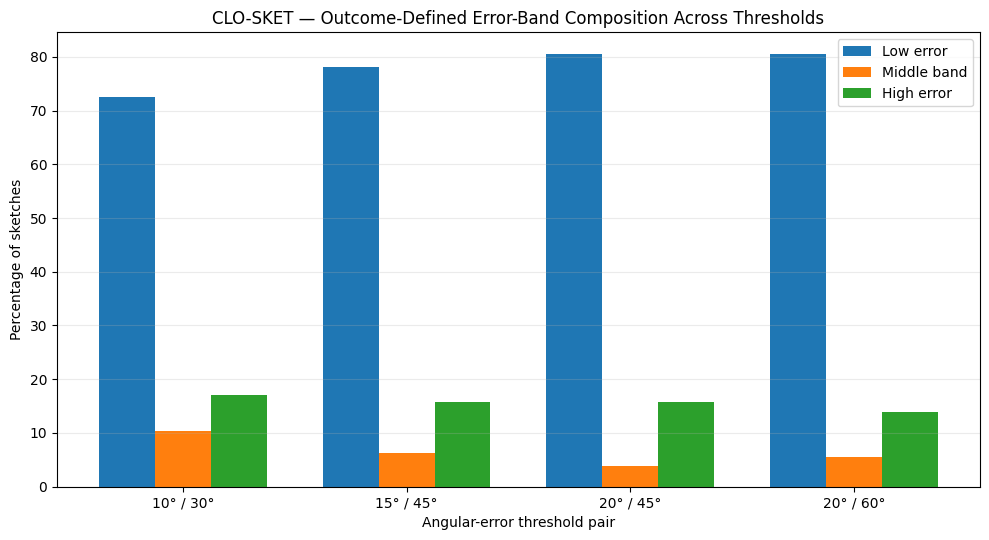

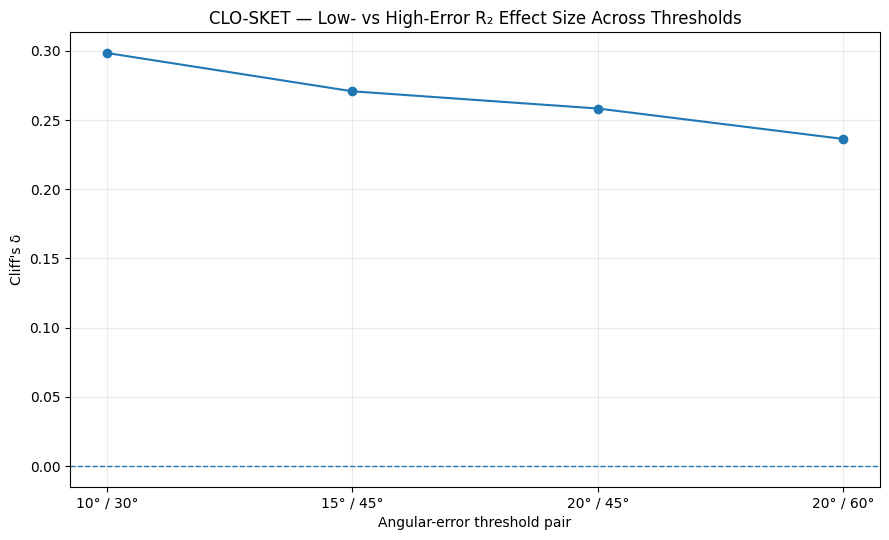

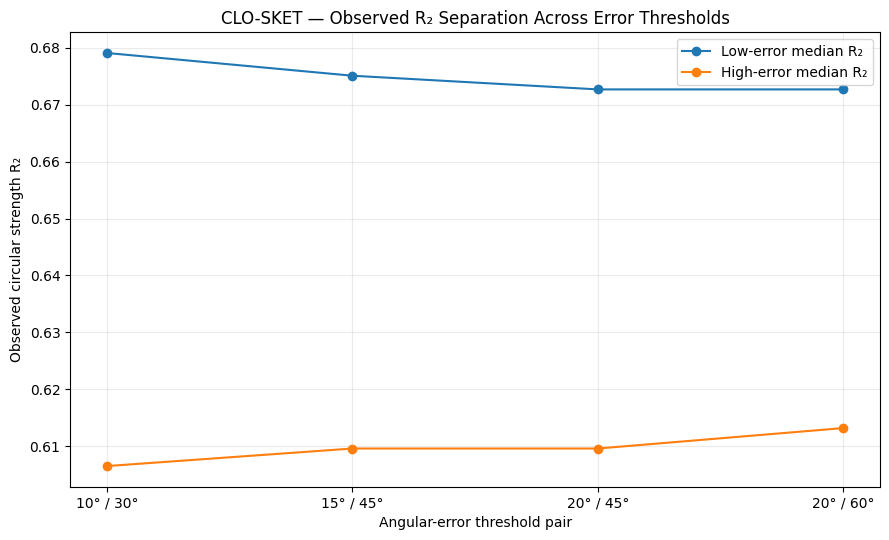


CELL 30K — THRESHOLD SENSITIVITY SUMMARY

This analysis evaluates whether the observed separation
between low- and high-error outcome-defined bands depends
strongly on the particular angular-error thresholds.

Four reasonable threshold configurations were evaluated:

    10° / 30°
    15° / 45°     [primary analysis]
    20° / 45°
    20° / 60°

For each configuration, sketches were divided into:

    Low error
    Middle band
    High error

using only axial angular error.

Observed peak-shell R₂ was then compared between the
low- and high-error groups.

The analysis evaluates:

    group size
    median observed R₂
    Mann–Whitney U
    Cliff's delta

The purpose is robustness assessment.

It does NOT select the "best" threshold.

It does NOT optimize thresholds against the data.

It does NOT retrain the model.

It does NOT modify any feature.

It does NOT introduce category labels.

If the direction of R₂ separation and the effect size
remain stable across reasonable threshold cho

In [ ]:
# ================================================================================
# 🧪 CLO-SKET — CELL 30K
# THRESHOLD SENSITIVITY / RECOVERY-REGIME ROBUSTNESS
# ================================================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, rankdata


print("=" * 80)
print("🧪 CLO-SKET — CELL 30K")
print("OUTCOME-DEFINED ERROR-BAND THRESHOLD SENSITIVITY")
print("=" * 80)


# ================================================================================
# 1. INPUT RECOVERY
# ================================================================================

print("\nINPUT VERIFICATION")
print("-" * 80)


# ----------------------------------------------------------------
# Axial angular error
# ----------------------------------------------------------------

# Prefer the explicit saved arrays from the revised Cell 30I. Fall back to
# revised and then legacy global names for notebook compatibility.
if (
    "cell30i_arrays" in globals()
    and "axial_error_deg" in cell30i_arrays
):

    axial_error_30k = np.asarray(
        cell30i_arrays["axial_error_deg"],
        dtype=float
    )

elif "axial_error" in globals():

    axial_error_30k = np.asarray(
        axial_error,
        dtype=float
    )

elif "axial_error_deg" in globals():

    axial_error_30k = np.asarray(
        axial_error_deg,
        dtype=float
    )

else:

    raise RuntimeError(
        "No axial angular error array found."
    )


# ----------------------------------------------------------------
# Observed R₂ at the domain-consistent F₂ peak
# ----------------------------------------------------------------

if (
    "cell30i_arrays" in globals()
    and "observed_peak_R2" in cell30i_arrays
):

    observed_R2_30k = np.asarray(
        cell30i_arrays["observed_peak_R2"],
        dtype=float
    )

elif "R2_observed_peak" in globals():

    observed_R2_30k = np.asarray(
        R2_observed_peak,
        dtype=float
    )

elif "R2_obs_peak" in globals():

    observed_R2_30k = np.asarray(
        R2_obs_peak,
        dtype=float
    )

elif "R2_obs_at_F2_peak" in globals():

    observed_R2_30k = np.asarray(
        R2_obs_at_F2_peak,
        dtype=float
    )

else:

    raise RuntimeError(
        "No domain-consistent observed R₂-at-peak array found."
    )


print(
    f"🟢 axial error        : {axial_error_30k.shape}"
)

print(
    f"🟢 observed R₂        : {observed_R2_30k.shape}"
)


# ================================================================================
# 2. POPULATION CONSISTENCY
# ================================================================================

if axial_error_30k.ndim != 1:

    raise RuntimeError(
        "Axial error must be a one-dimensional sketch-level array."
    )


if observed_R2_30k.ndim != 1:

    raise RuntimeError(
        "Observed R₂ must be a one-dimensional sketch-level array."
    )


if len(axial_error_30k) != len(observed_R2_30k):

    raise RuntimeError(
        "Axial-error and observed-R₂ populations do not match."
    )


N = len(
    axial_error_30k
)


finite_mask = (
    np.isfinite(axial_error_30k)
    &
    np.isfinite(observed_R2_30k)
)


valid_error = axial_error_30k[
    finite_mask
]

valid_R2 = observed_R2_30k[
    finite_mask
]


print("\nPOPULATION")
print("-" * 80)

print(
    f"Total sketches : {N}"
)

print(
    f"Valid sketches : {len(valid_error)}"
)

print(
    f"Invalid sketches : {N - len(valid_error)}"
)


if len(valid_error) != 2300:

    raise RuntimeError(
        "Expected 2300 valid sketches."
    )


# ================================================================================
# 3. DOMAIN LOCK
# ================================================================================

print("\nLOCKED RADIAL DOMAIN")
print("-" * 80)

if "cell30i_domain_audit" in globals():

    domain_audit = cell30i_domain_audit

    domain_min = float(
        domain_audit["locked_domain_min"]
    )

    domain_max = float(
        domain_audit["locked_domain_max"]
    )

    n_shells = int(
        domain_audit["number_of_circular_shells"]
    )

    # Revised Cell 30I verifies the scientifically relevant identity
    # observed peak-shell R2 == observed |F2|. Older versions instead saved
    # a nearest-shell mismatch. Accept either schema without conflating them.
    if "R2_F2_identity_max_abs_error" in domain_audit:

        audit_metric_name = "max |observed R2 - |F2|| at peak"
        audit_metric_value = float(
            domain_audit["R2_F2_identity_max_abs_error"]
        )
        audit_metric_tolerance = 1e-12
        max_mismatch = None

    elif "maximum_shell_mismatch" in domain_audit:

        audit_metric_name = "Maximum shell mismatch"
        audit_metric_value = float(
            domain_audit["maximum_shell_mismatch"]
        )
        audit_metric_tolerance = 1e-12
        max_mismatch = audit_metric_value

    else:

        raise RuntimeError(
            "Cell 30I domain audit contains neither the revised R2–|F2| "
            "identity check nor the legacy shell-mismatch check."
        )

else:

    domain_audit = {}
    domain_min = 3.50
    domain_max = 27.50
    n_shells = 25
    audit_metric_name = "Domain audit fallback value"
    audit_metric_value = 0.0
    audit_metric_tolerance = 1e-12
    max_mismatch = None


print(
    f"Domain : {domain_min:.2f} → {domain_max:.2f}"
)

print(
    f"Circular shells : {n_shells}"
)

print(
    f"{audit_metric_name} : {audit_metric_value:.3e}"
)


if not np.isclose(
    domain_min,
    3.50
):

    raise RuntimeError(
        "Unexpected radial-domain lower boundary."
    )


if not np.isclose(
    domain_max,
    27.50
):

    raise RuntimeError(
        "Unexpected radial-domain upper boundary."
    )


if n_shells != 25:

    raise RuntimeError(
        "Expected 25 circular shells."
    )


if not np.isclose(
    audit_metric_value,
    0.0,
    atol=audit_metric_tolerance,
    rtol=0.0
):

    raise RuntimeError(
        "Peak-shell domain/identity audit failed."
    )


# ================================================================================
# 4. CLIFF'S DELTA FUNCTION
# ================================================================================

def cliffs_delta(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    x = x[
        np.isfinite(x)
    ]

    y = y[
        np.isfinite(y)
    ]

    if len(x) == 0 or len(y) == 0:

        return np.nan

    # Average ranks are required for a correct tie-aware U statistic.
    combined = np.concatenate(
        [x, y]
    )

    ranks = rankdata(
        combined,
        method="average"
    )

    rx = ranks[
        :len(x)
    ]

    U = (
        np.sum(rx)
        - len(x) * (len(x) + 1) / 2
    )

    return (
        2 * U
        / (len(x) * len(y))
        - 1
    )


# ================================================================================
# 5. THRESHOLD SETS
# ================================================================================

threshold_sets = [

    (
        "10° / 30°",
        10.0,
        30.0
    ),

    (
        "15° / 45°",
        15.0,
        45.0
    ),

    (
        "20° / 45°",
        20.0,
        45.0
    ),

    (
        "20° / 60°",
        20.0,
        60.0
    ),

]


# ================================================================================
# 6. THRESHOLD-SENSITIVITY ANALYSIS
# ================================================================================

results_30k = []


print("\n" + "=" * 80)
print("THRESHOLD SENSITIVITY")
print("=" * 80)


for label, reliable_cut, failure_cut in threshold_sets:

    reliable_mask = (
        valid_error
        <= reliable_cut
    )

    failure_mask = (
        valid_error
        > failure_cut
    )

    moderate_mask = (
        (~reliable_mask)
        &
        (~failure_mask)
    )


    reliable_R2 = valid_R2[
        reliable_mask
    ]

    failure_R2 = valid_R2[
        failure_mask
    ]


    if (
        len(reliable_R2) == 0
        or
        len(failure_R2) == 0
    ):

        raise RuntimeError(
            f"Empty recovery group for threshold {label}."
        )


    # ------------------------------------------------------------
    # Mann–Whitney comparison
    # ------------------------------------------------------------

    U, p = mannwhitneyu(
        reliable_R2,
        failure_R2,
        alternative="two-sided"
    )


    delta = cliffs_delta(
        reliable_R2,
        failure_R2
    )


    result = {

        "threshold_label": label,

        "reliable_threshold": reliable_cut,

        "failure_threshold": failure_cut,

        "N_reliable": len(
            reliable_R2
        ),

        "N_moderate": int(
            np.sum(
                moderate_mask
            )
        ),

        "N_failure": len(
            failure_R2
        ),

        "pct_reliable": (
            100
            * len(reliable_R2)
            / len(valid_error)
        ),

        "pct_moderate": (
            100
            * np.sum(moderate_mask)
            / len(valid_error)
        ),

        "pct_failure": (
            100
            * len(failure_R2)
            / len(valid_error)
        ),

        "median_R2_reliable": np.median(
            reliable_R2
        ),

        "median_R2_failure": np.median(
            failure_R2
        ),

        "median_difference": (
            np.median(reliable_R2)
            -
            np.median(failure_R2)
        ),

        "mannwhitney_U": U,

        "mannwhitney_p": p,

        "cliffs_delta": delta,

    }


    results_30k.append(
        result
    )


    print("\n" + "-" * 80)

    print(
        f"THRESHOLD SET : {label}"
    )

    print(
        f"Low error ≤ {reliable_cut:.0f}°"
    )

    print(
        f"High error > {failure_cut:.0f}°"
    )

    print(
        f"Low error : {len(reliable_R2):4d} "
        f"({100 * len(reliable_R2) / len(valid_error):6.2f}%)"
    )

    print(
        f"Middle    : {np.sum(moderate_mask):4d} "
        f"({100 * np.sum(moderate_mask) / len(valid_error):6.2f}%)"
    )

    print(
        f"High error: {len(failure_R2):4d} "
        f"({100 * len(failure_R2) / len(valid_error):6.2f}%)"
    )

    print(
        f"Median observed R₂ — low error : "
        f"{np.median(reliable_R2):.4f}"
    )

    print(
        f"Median observed R₂ — high error: "
        f"{np.median(failure_R2):.4f}"
    )

    print(
        f"Median R₂ difference           : "
        f"{np.median(reliable_R2) - np.median(failure_R2):+.4f}"
    )

    print(
        f"Cliff's δ                     : "
        f"{delta:+.4f}"
    )

    print(
        f"Mann–Whitney p                : "
        f"{p:.6e}"
    )


# ================================================================================
# 7. CONSISTENCY CHECK
# ================================================================================

print("\n" + "=" * 80)
print("ROBUSTNESS CONSISTENCY CHECK")
print("=" * 80)


all_positive_delta = all(
    r["cliffs_delta"] > 0
    for r in results_30k
)


all_R2_separation = all(
    r["median_R2_reliable"]
    >
    r["median_R2_failure"]
    for r in results_30k
)


all_significant = all(
    r["mannwhitney_p"] < 0.05
    for r in results_30k
)


print(
    f"Low-error median R₂ > high-error median R₂ : "
    f"{all_R2_separation}"
)

print(
    f"Cliff's δ positive across thresholds    : "
    f"{all_positive_delta}"
)

print(
    f"Unadjusted Mann–Whitney p < 0.05 throughout: "
    f"{all_significant}"
)


# ================================================================================
# 8. FIGURE 1 — RECOVERY FRACTIONS
# ================================================================================

labels = [
    r["threshold_label"]
    for r in results_30k
]

reliable_pct = [
    r["pct_reliable"]
    for r in results_30k
]

moderate_pct = [
    r["pct_moderate"]
    for r in results_30k
]

failure_pct = [
    r["pct_failure"]
    for r in results_30k
]


x = np.arange(
    len(labels)
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(10, 5.5)
)


ax.bar(
    x - width,
    reliable_pct,
    width,
    label="Low error"
)

ax.bar(
    x,
    moderate_pct,
    width,
    label="Middle band"
)

ax.bar(
    x + width,
    failure_pct,
    width,
    label="High error"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels
)

ax.set_ylabel(
    "Percentage of sketches"
)

ax.set_xlabel(
    "Angular-error threshold pair"
)

ax.set_title(
    "CLO-SKET — Outcome-Defined Error-Band Composition Across Thresholds"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ================================================================================
# 9. FIGURE 2 — EFFECT SIZE STABILITY
# ================================================================================

cliff_values = np.array([
    r["cliffs_delta"]
    for r in results_30k
])


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


ax.plot(
    x,
    cliff_values,
    marker="o"
)


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels
)

ax.set_ylabel(
    "Cliff's δ"
)

ax.set_xlabel(
    "Angular-error threshold pair"
)

ax.set_title(
    "CLO-SKET — Low- vs High-Error R₂ Effect Size Across Thresholds"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ================================================================================
# 10. FIGURE 3 — R₂ SEPARATION
# ================================================================================

median_reliable = np.array([
    r["median_R2_reliable"]
    for r in results_30k
])


median_failure = np.array([
    r["median_R2_failure"]
    for r in results_30k
])


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)


ax.plot(
    x,
    median_reliable,
    marker="o",
    label="Low-error median R₂"
)


ax.plot(
    x,
    median_failure,
    marker="o",
    label="High-error median R₂"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels
)

ax.set_ylabel(
    "Observed circular strength R₂"
)

ax.set_xlabel(
    "Angular-error threshold pair"
)

ax.set_title(
    "CLO-SKET — Observed R₂ Separation Across Error Thresholds"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ================================================================================
# 11. SAVE AUDIT OBJECTS
# ================================================================================

cell30k_results = results_30k

cell30k_domain_audit = {

    "locked_domain_min": domain_min,

    "locked_domain_max": domain_max,

    "number_of_circular_shells": n_shells,

    "audit_metric_name": audit_metric_name,

    "audit_metric_value": audit_metric_value,

    "R2_F2_identity_max_abs_error": (
        audit_metric_value
        if "R2_F2_identity_max_abs_error" in domain_audit
        else None
    ),

    "maximum_shell_mismatch": max_mismatch,

}


cell30k_thresholds = [
    {
        "label": label,
        "reliable_cutoff": reliable_cut,
        "failure_cutoff": failure_cut,
    }
    for label, reliable_cut, failure_cut
    in threshold_sets
]


# ================================================================================
# 12. FINAL SCIENTIFIC INTERPRETATION
# ================================================================================

print("\n" + "=" * 80)
print("CELL 30K — THRESHOLD SENSITIVITY SUMMARY")
print("=" * 80)

print("""
This analysis evaluates whether the observed separation
between low- and high-error outcome-defined bands depends
strongly on the particular angular-error thresholds.

Four reasonable threshold configurations were evaluated:

    10° / 30°
    15° / 45°     [primary analysis]
    20° / 45°
    20° / 60°

For each configuration, sketches were divided into:

    Low error
    Middle band
    High error

using only axial angular error.

Observed peak-shell R₂ was then compared between the
low- and high-error groups.

The analysis evaluates:

    group size
    median observed R₂
    Mann–Whitney U
    Cliff's delta

The purpose is robustness assessment.

It does NOT select the "best" threshold.

It does NOT optimize thresholds against the data.

It does NOT retrain the model.

It does NOT modify any feature.

It does NOT introduce category labels.

If the direction of R₂ separation and the effect size
remain stable across reasonable threshold choices, the
central recovery-regime observation is less dependent on
the arbitrary choice of a single diagnostic threshold.

The threshold definitions reuse strongly overlapping
sets of sketches. They are not independent replications,
and the sequence of Mann–Whitney p-values is not treated
as repeated confirmatory evidence. Mann–Whitney evaluates
distributional ordering/equality, not medians specifically.

Because the bands are defined after observing axial
error, they are descriptive groups rather than validated
prospective reliability classes.

This remains an observational robustness analysis.

It does NOT establish causality or semantic garment-part
recognition.
""")


# ================================================================================
# 13. FINAL STATUS
# ================================================================================

print("\n" + "=" * 80)
print("🟢 CELL 30K — THRESHOLD SENSITIVITY ANALYSIS COMPLETE")
print("=" * 80)

print("""
RESULT OBJECTS SAVED:

    cell30k_results
    cell30k_domain_audit
    cell30k_thresholds

NEXT:

    CELL 30L — FINAL EVIDENCE AUDIT / CLAIM BOUNDARY
""")

print("=" * 80)


## 10. Final run audit

The notebook is complete only if this cell passes. Copy its printed output when sharing results.


In [ ]:
required_final = {
    "conditional_angular": (2300, 72, 72),
    "F2_mag": (2300, 72),
    "p_theta": (2300, 25, 72),
    "C2_obs": (2300, 25),
    "S2_obs": (2300, 25),
    "R2_obs": (2300, 25),
    "mu2_obs_deg": (2300, 25),
    "C2_hat_field": (2300, 25),
    "S2_hat_field": (2300, 25),
    "R2_hat_field": (2300, 25),
    "mu2_hat_field_deg": (2300, 25),
    "X_F2_primary": (2300, 8),
    "X_alpha2_primary": (2300, 6),
    "X_primary": (2300, 14),
}

print("=" * 88)
print("FINAL AUDITED RUN CHECK — PROVENANCE-RESPECTING 14-D LOCK")
print("=" * 88)

missing = [name for name in required_final if name not in globals()]
if missing:
    print("MISSING OBJECTS")
    print("-" * 88)
    for name in missing:
        print(f"{name:28s} <- not present")
    raise RuntimeError(
        "Final lineage incomplete; rerun from the first upstream failure. "
        "Missing objects: " + ", ".join(missing)
    )

for name, expected in required_final.items():
    value = globals()[name]
    shape = tuple(value.shape)
    print(f"{name:28s} shape={shape!s:18s} expected={expected}")
    if shape != expected:
        raise AssertionError(f"{name}: expected {expected}, got {shape}")

f2 = np.asarray(X_F2_primary, dtype=float)
alpha2 = np.asarray(X_alpha2_primary, dtype=float)
primary = np.asarray(X_primary, dtype=float)
candidate = np.concatenate([f2, alpha2], axis=1)

print("exact 14-D concatenation match:", np.array_equal(candidate, primary))
print("maximum difference:", float(np.max(np.abs(candidate - primary))))

assert np.array_equal(candidate, primary)
assert np.isfinite(primary).all()

if hasattr(X_primary, "columns"):
    observed_columns = tuple(X_primary.columns)
    if "CELL23C_LOCKED_COLUMNS" not in globals():
        raise RuntimeError("Missing Cell 23C column-order lock.")
    assert observed_columns == tuple(CELL23C_LOCKED_COLUMNS)
    print("Cell 23C column-order lock match: True")

print("\nPASS — clean lineage completed with the locked 14-D primary representation.")
print("No historical 28-D family assembly is asserted by this audit.")


FINAL AUDITED RUN CHECK — PROVENANCE-RESPECTING 14-D LOCK
conditional_angular          shape=(2300, 72, 72)     expected=(2300, 72, 72)
F2_mag                       shape=(2300, 72)         expected=(2300, 72)
p_theta                      shape=(2300, 25, 72)     expected=(2300, 25, 72)
C2_obs                       shape=(2300, 25)         expected=(2300, 25)
S2_obs                       shape=(2300, 25)         expected=(2300, 25)
R2_obs                       shape=(2300, 25)         expected=(2300, 25)
mu2_obs_deg                  shape=(2300, 25)         expected=(2300, 25)
C2_hat_field                 shape=(2300, 25)         expected=(2300, 25)
S2_hat_field                 shape=(2300, 25)         expected=(2300, 25)
R2_hat_field                 shape=(2300, 25)         expected=(2300, 25)
mu2_hat_field_deg            shape=(2300, 25)         expected=(2300, 25)
X_F2_primary                 shape=(2300, 8)          expected=(2300, 8)
X_alpha2_primary             shape=(2300, 6)   